# Run this to enable loading from relative paths

In [3]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 1
    import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg


# Force matplotlib inlining 

In [4]:
%matplotlib inline

# Save plots with no embeded fonts

In [5]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']


# Set figures save path

In [6]:
global_save_figs = False

In [7]:
save_prefix = r"../results/behavior/"
if global_save_figs:
    import pathlib
    try:
        pathlib.Path(save_prefix).mkdir(exist_ok=True)
    except:
        print("Failed to create save dir...")

# Common function for mice and human data

In [8]:
COLOR_ACCURACY = "#6e286a"
COLOR_MAX_OUTCOME = "#1ba08e"
COLOR_MICE = "#eb8b2d"

In [9]:
import numpy as np
from typing import Literal

def plotSTVsTime(df, *, dv_col, st_col, is_many_subjects, ax, ls, c="k",
                 use_mean_or_median : Literal["mean", "median"]="mean",
                 center=False):
    assert use_mean_or_median in ["mean", "median"]
    x = []
    y = []
    y_sem = []
    label = st_col
    for dv in ["Hard", "Med", "Easy"]:
        dv_df = df[df[dv_col] == dv]
        if is_many_subjects:
            col = dv_df.groupby("Name")[st_col].mean()
            label = f"{label}\n({dv} n={len(col)} subjects)"
        else:
            col = dv_df[st_col]
        if use_mean_or_median == "mean":
            y.append(col.mean())
            y_sem.append(col.sem())
        else:
            y.append(col.median())
            y_sem.append(0)
        x.append(dv)
    if center:
        y = np.array(y)
        y -= y.mean()
    ax.errorbar(x, y, yerr=y_sem, ls=ls, label=label, c=c)


In [10]:
from .behavior.util.splitdata import splitStimulusTimeByQuantile
import pandas as pd

def assignQuantiles(df):
    df = df.copy()
    # Some files are saved twice due to cloud sync issues
    uniq_cols = ["Name", "Date", "SessionNum", "TrialNumber", "TrialStartSysTime"]

    len_before = len(df)
    df = df[~df[uniq_cols].duplicated(keep="first")]
    assert len(df) == len_before, "Some rows are duplicated"
    null_time = df.calcStimulusTime.isnull()
    df_null_time = df[null_time]
    print(f"Num null stimulus time: {len(df_null_time)}/{len(df)}")
    df = df[~null_time]
    df = splitStimulusTimeByQuantile(df)
    df = pd.concat([q_df for q_idx, q_df in df] + [df_null_time])
    return df

# Load data

## Mice data

In [11]:
_FP = "../data/behavior/df_behavior.pkl"
df_mice = pd.read_pickle(_FP)
# Exclude first 30 trials of each session, optogenetics trials, trials where mice
# stayed more than 5 sec in the center port, i.e. stimulus is no loger presented,
# and exclude early-withdrawal trials, i.e. mice stayed for less than 0.3s
df_mice = df_mice[df_mice["valid"]]

In [12]:
df_chrono = pd.read_pickle(r"../data/behavior/df_chrono.pkl")

In [13]:
lc_hf_combined_df = pd.read_pickle(r"../data/behavior/lc_hf_combined_df.pkl")

## Humans data

In [14]:
df_users = pd.read_pickle(r"../data/behavior/df_human_subjects.pkl")

In [15]:
humans_max_outcome_df = df_users[df_users.session_type == "Competition"]
humans_accuracy_df = df_users[df_users.session_type == "ReactionTime"]

# Plot Stimulus-Time Distribution

## Fig. 1d

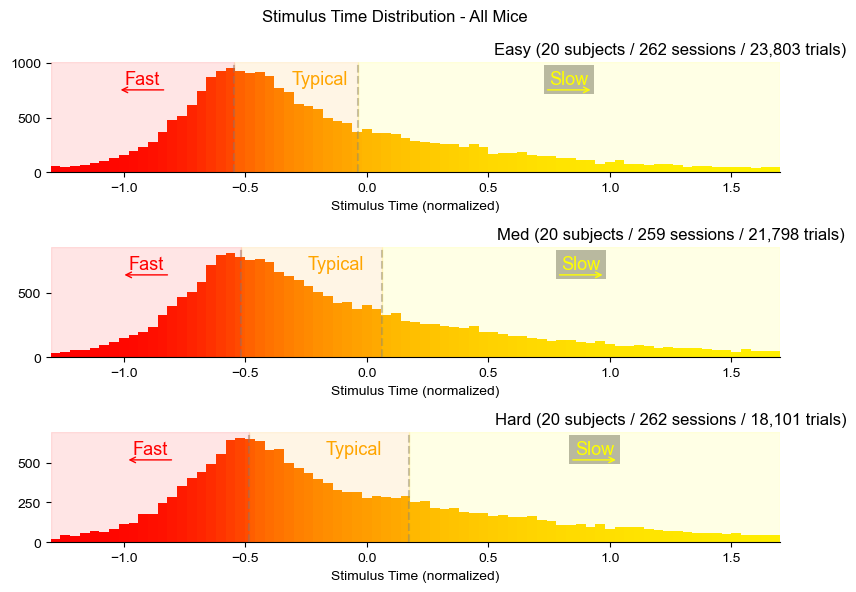

In [14]:
from .figcode.stbydifficulty import stDistOnly

stDistOnly(df_mice, plot_single_subjects=False,
           save_prefix=save_prefix, save_figs=global_save_figs)

## Ext Fig. 2d

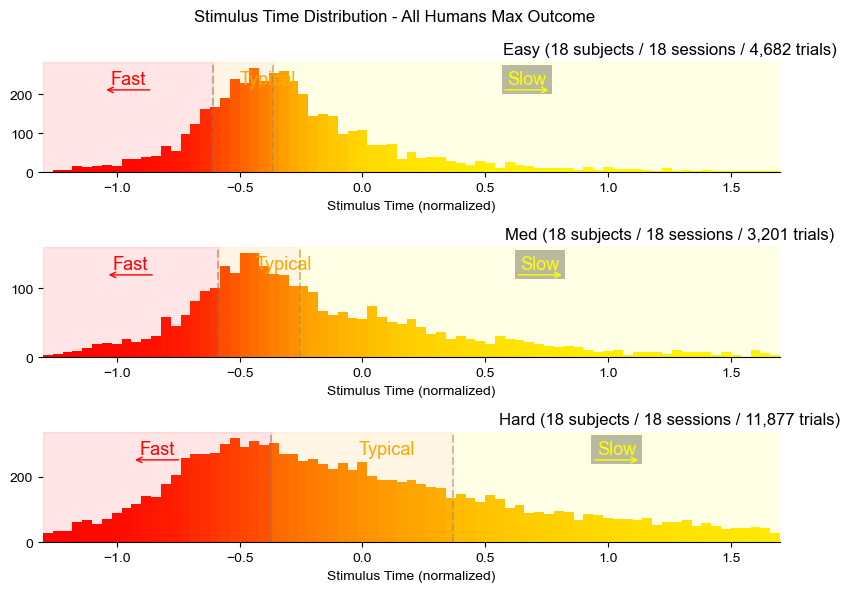

In [15]:
stDistOnly(humans_max_outcome_df, plot_single_subjects=False,
           descrp="Humans Max Outcome",
           save_prefix=save_prefix, save_figs=global_save_figs)

## Ext Fig. 2g

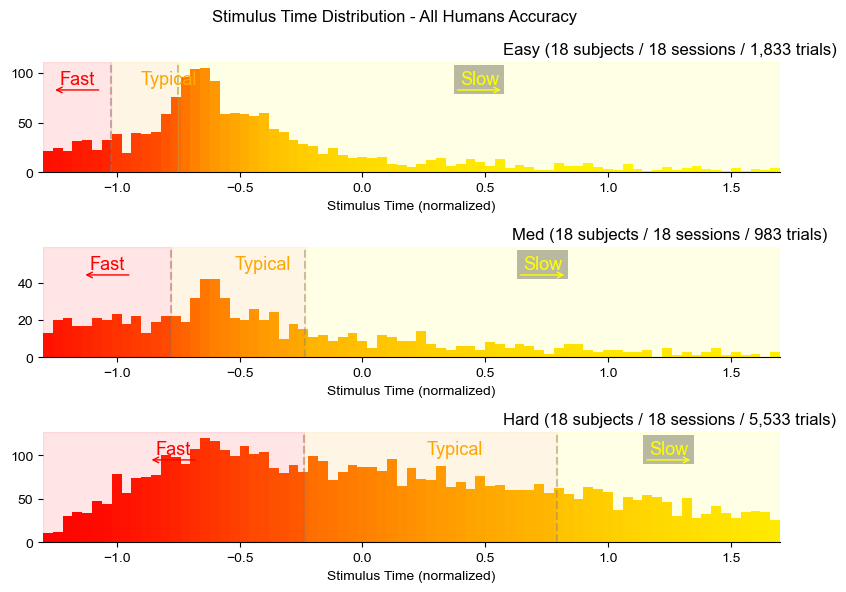

In [16]:
stDistOnly(humans_accuracy_df, plot_single_subjects=False,
           descrp="Humans Accuracy",
           save_prefix=save_prefix, save_figs=global_save_figs)

## Ext Fig. 2j

GP4-85


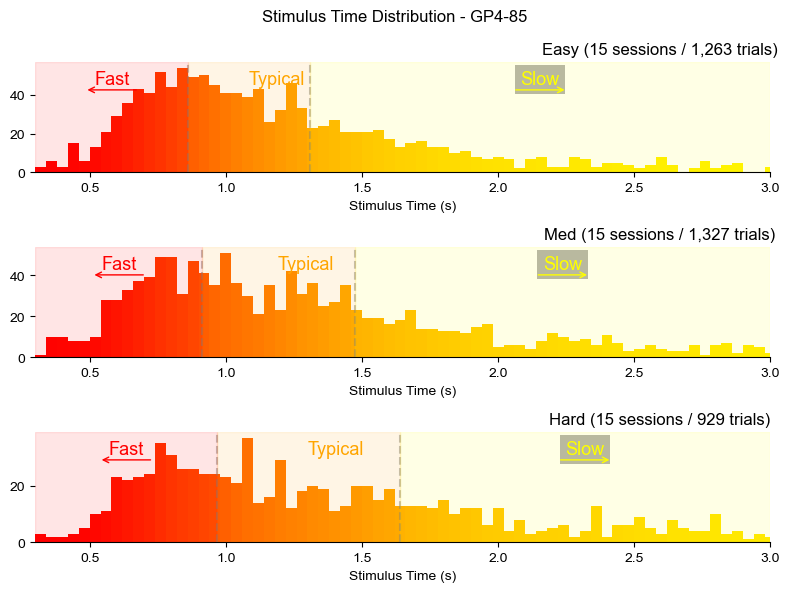

In [17]:
from .figcode.stbydifficulty import stDistOnly

stDistOnly(df_mice[df_mice.Name == "GP4-85"],
           plot_single_subjects=True, plot_combined_subjects=False,
           save_prefix=save_prefix, save_figs=global_save_figs)

## Per subject plots

Avgat1


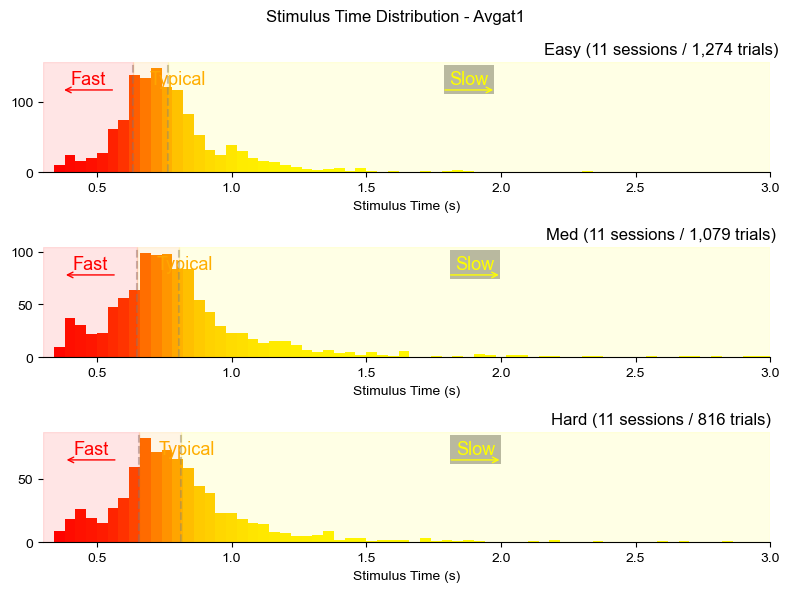

Avgat2


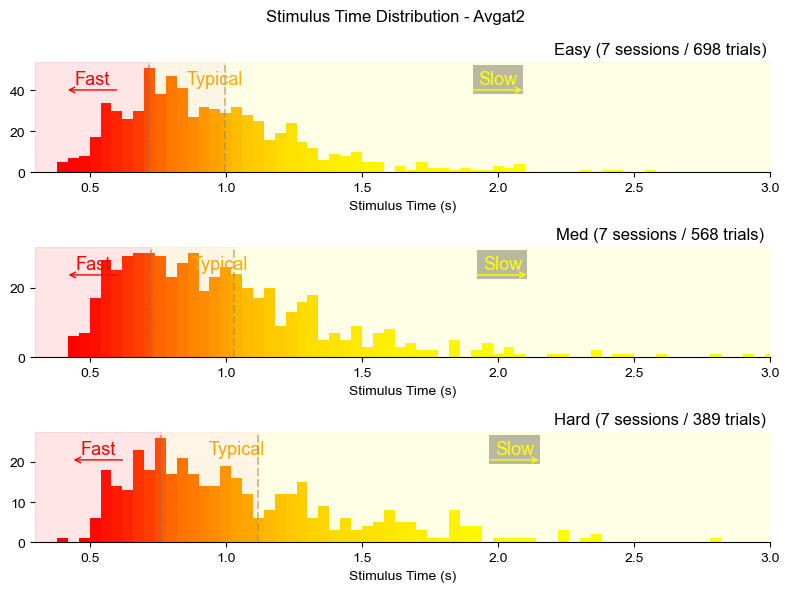

Avgat3


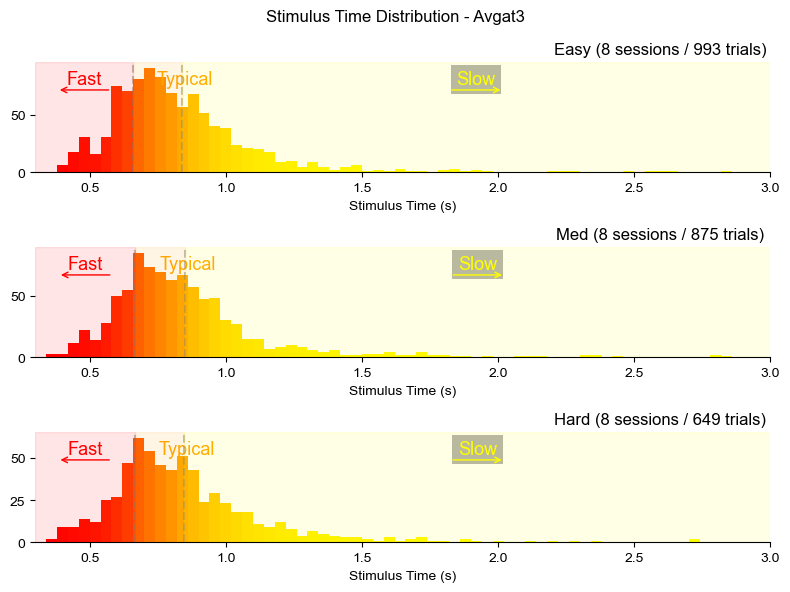

BVGAT1


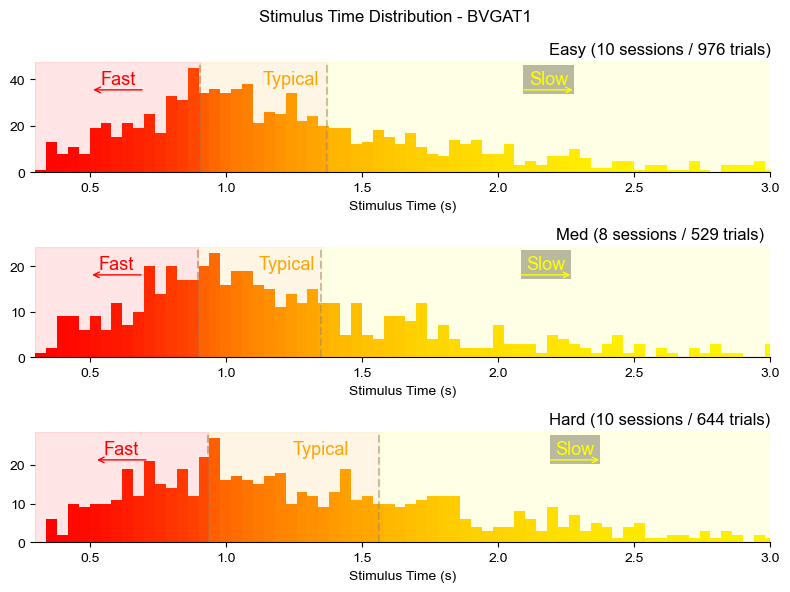

GP4-24


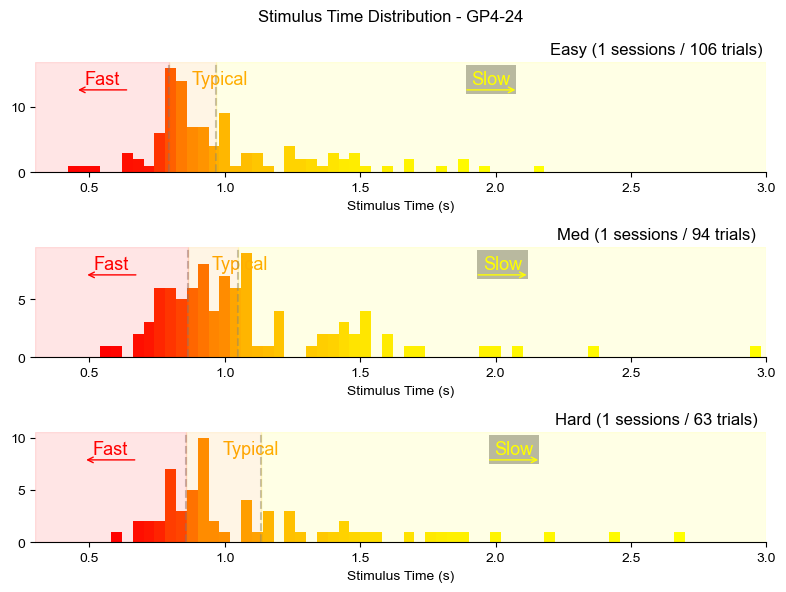

GP4-80


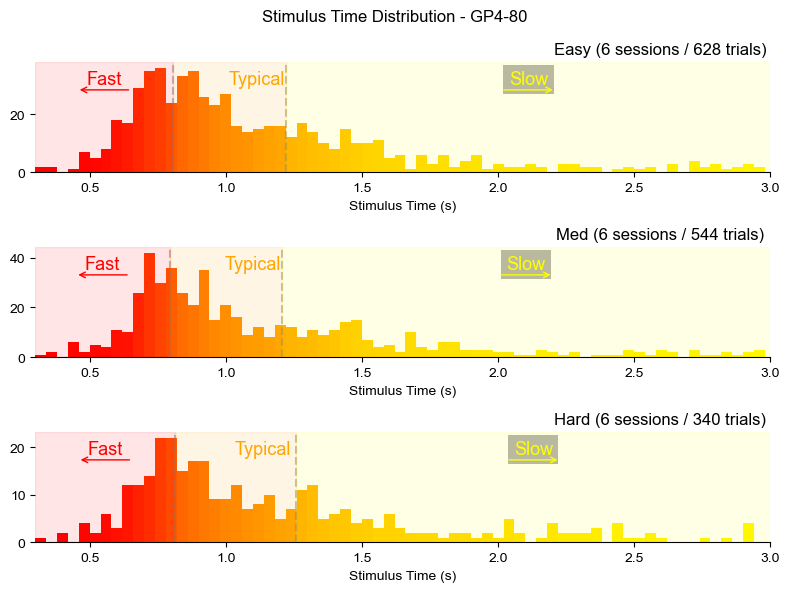

GP4-81


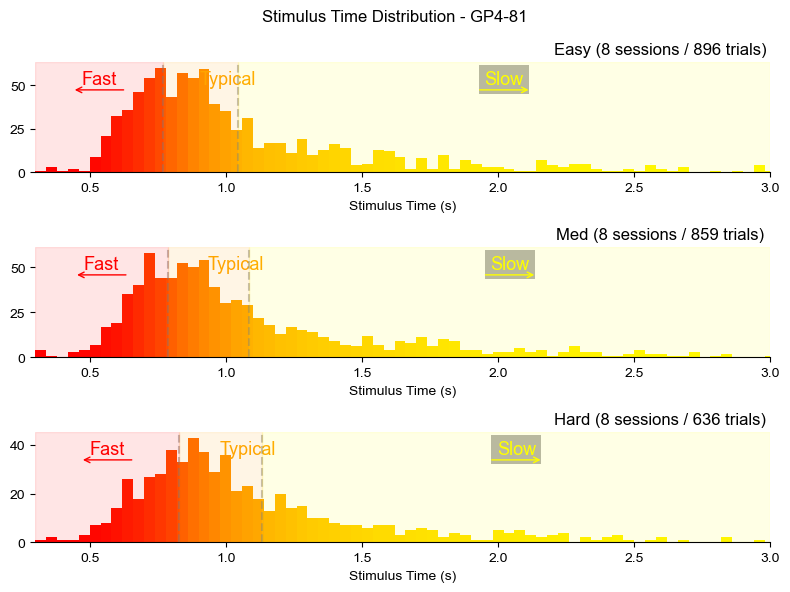

GP4-85


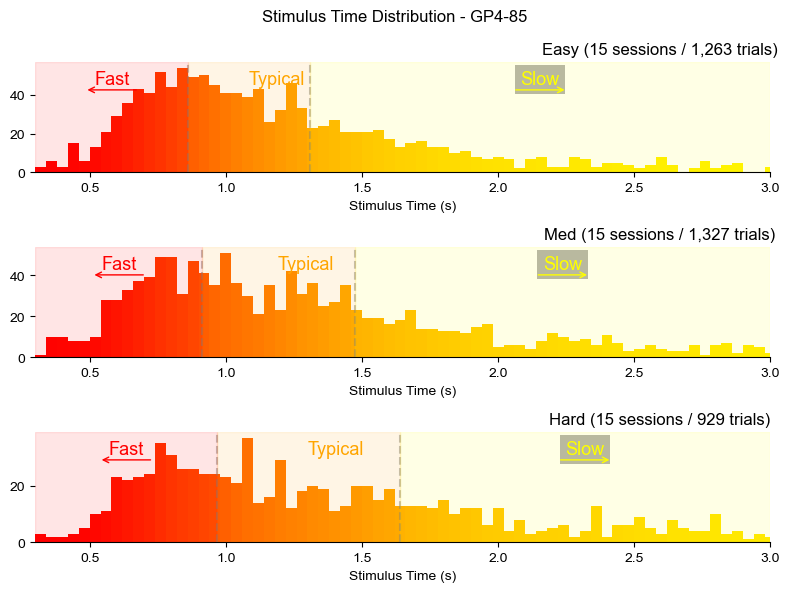

RDK_WT1


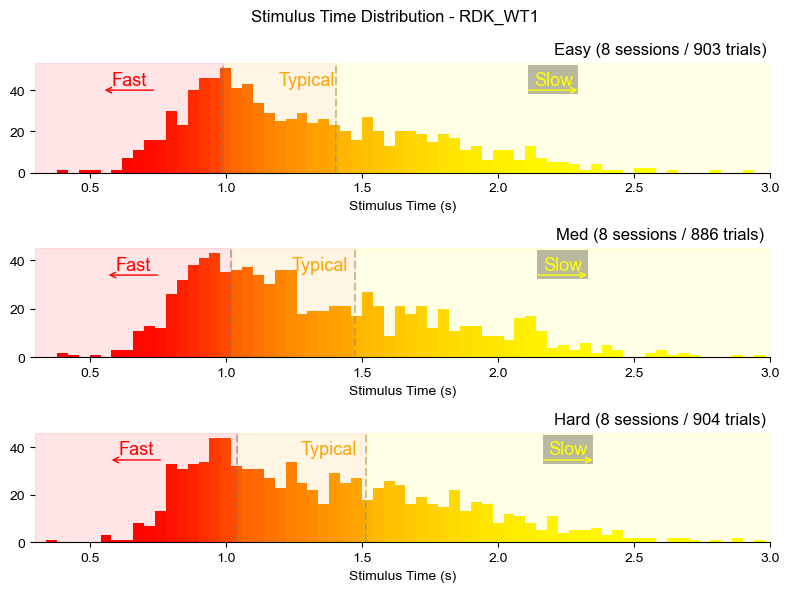

RDK_WT6


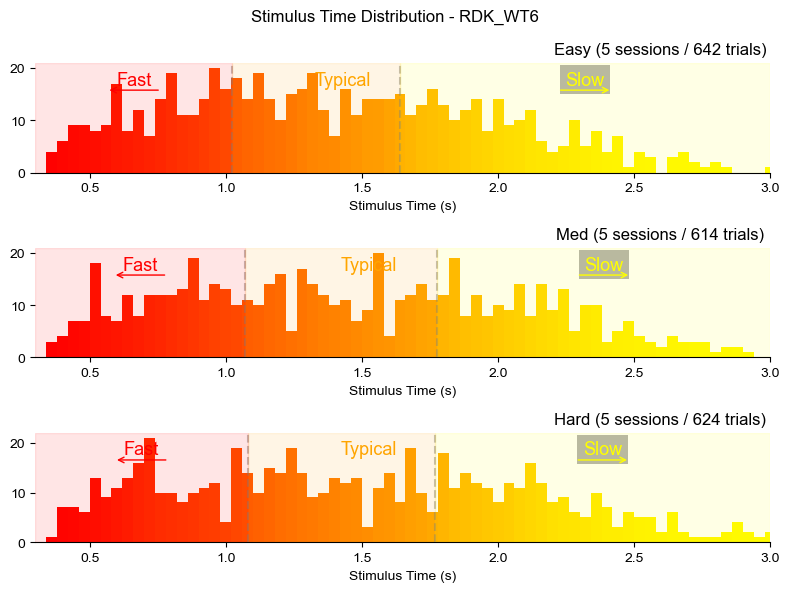

Rbp4_M2_1


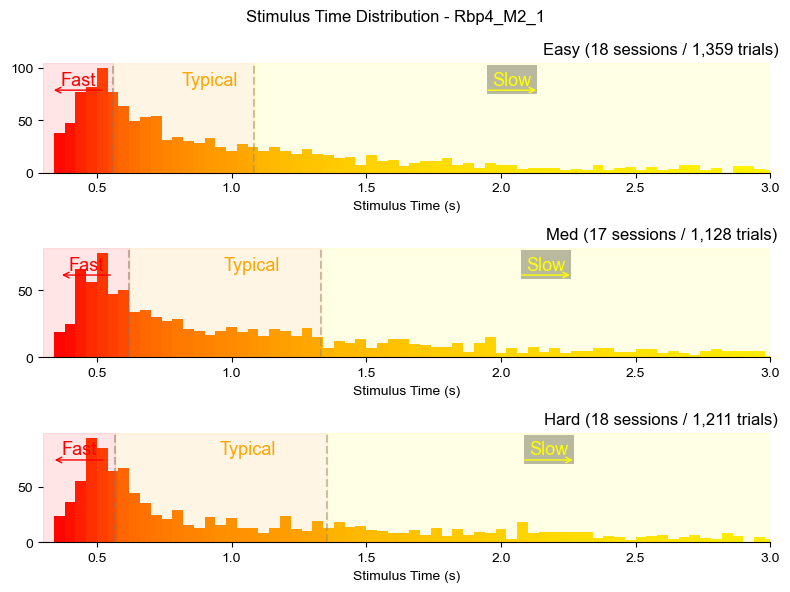

WF10


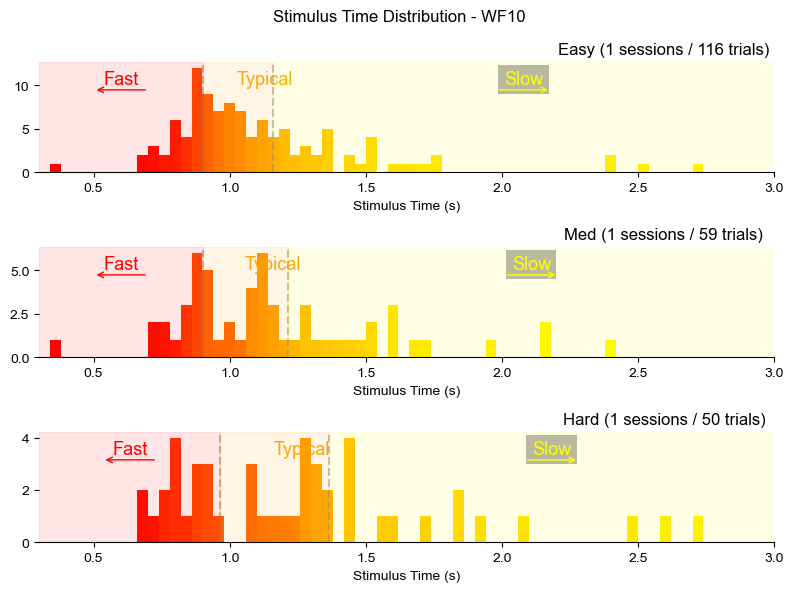

WF11


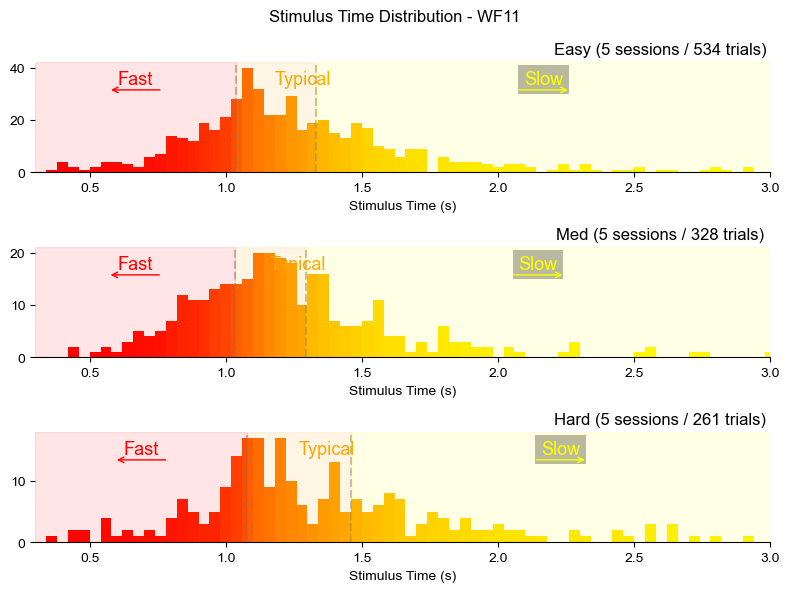

vgat-40


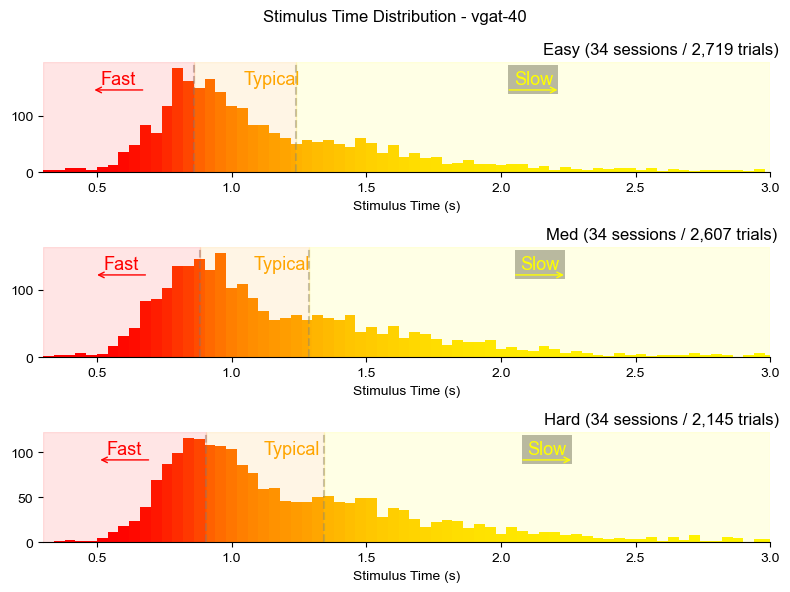

vgat-94


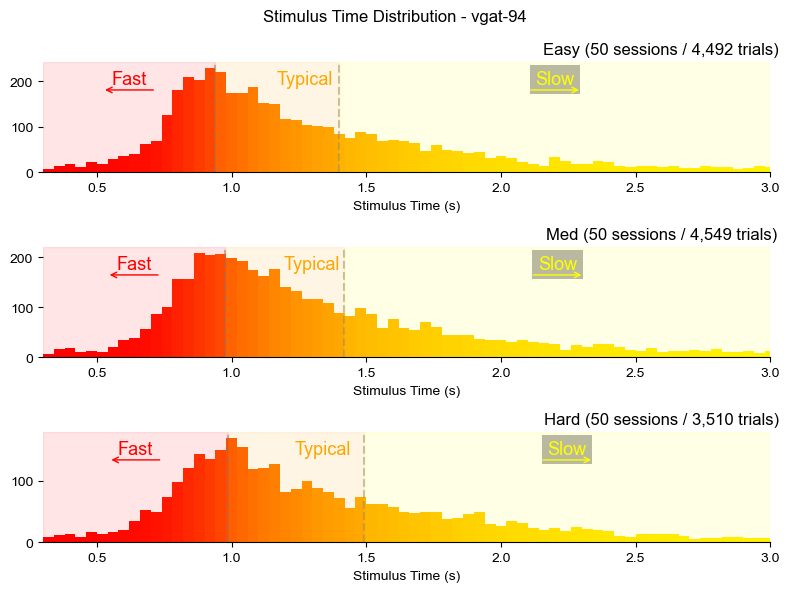

vgat-95


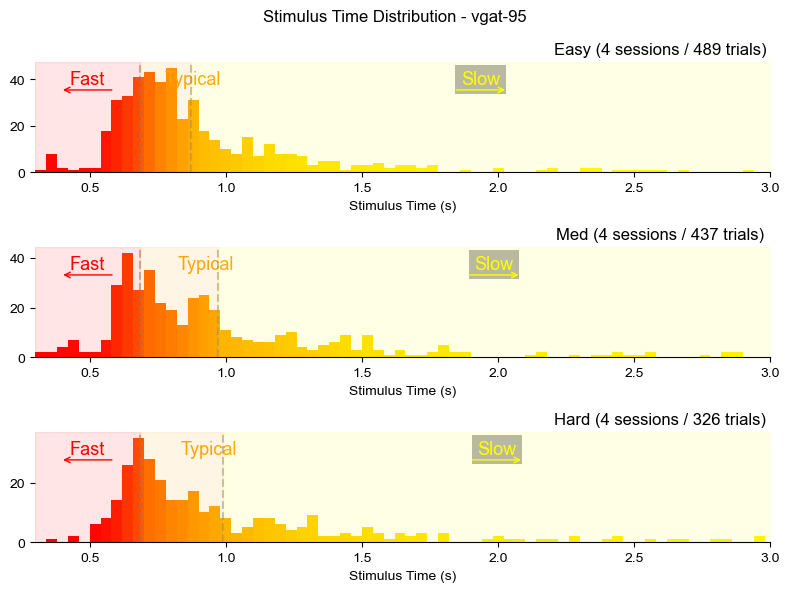

vgat-96


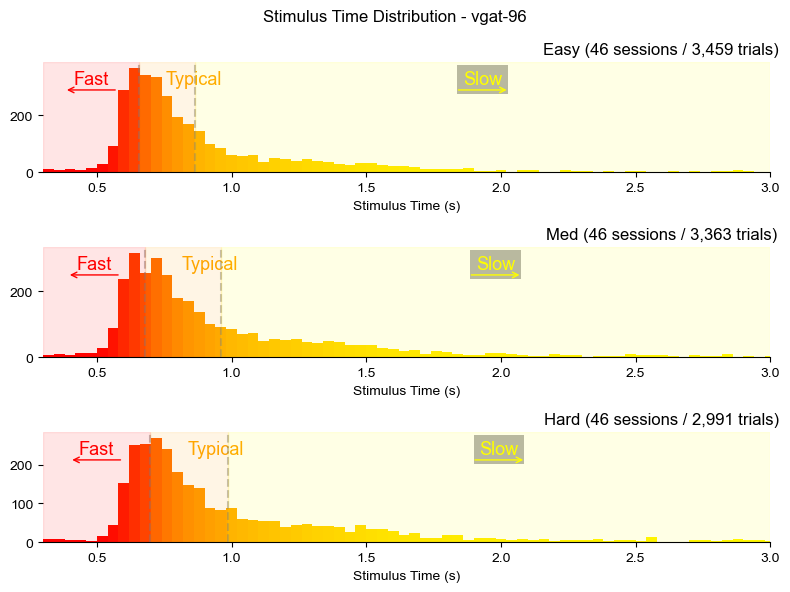

vgat2.5


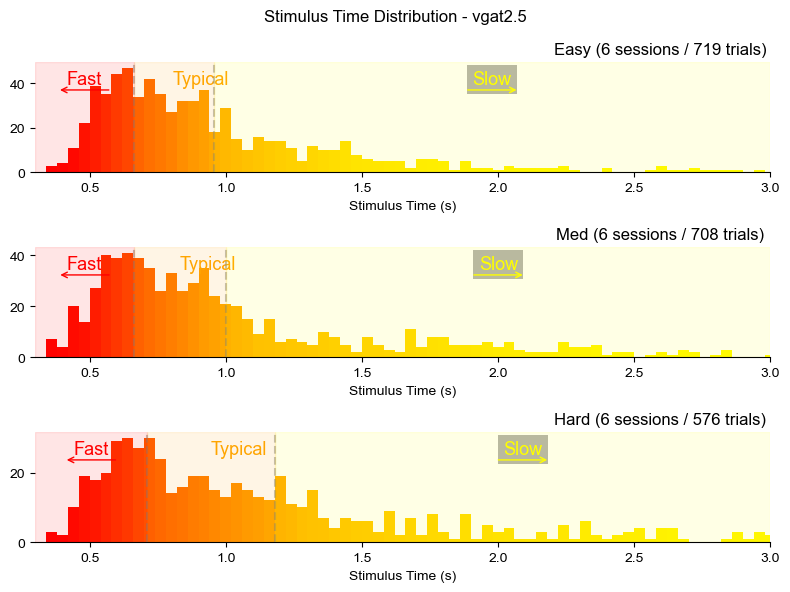

vgatchr2-sk


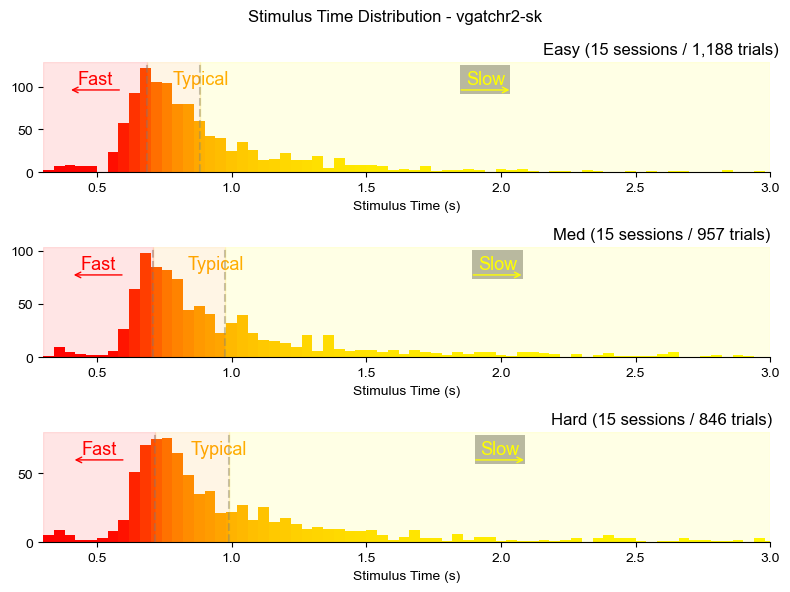

widefield_1


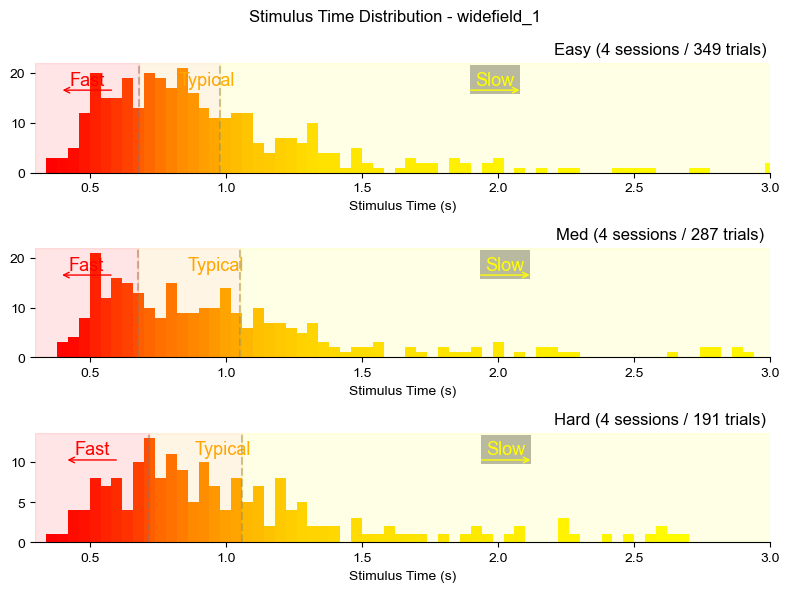

In [18]:
stDistOnly(df_mice, plot_single_subjects=True, plot_combined_subjects=False,
           save_prefix=save_prefix, save_figs=global_save_figs)

# Plot Fast/Slow Reaction-Time vs Difficulty

biggest_rng: 0.4


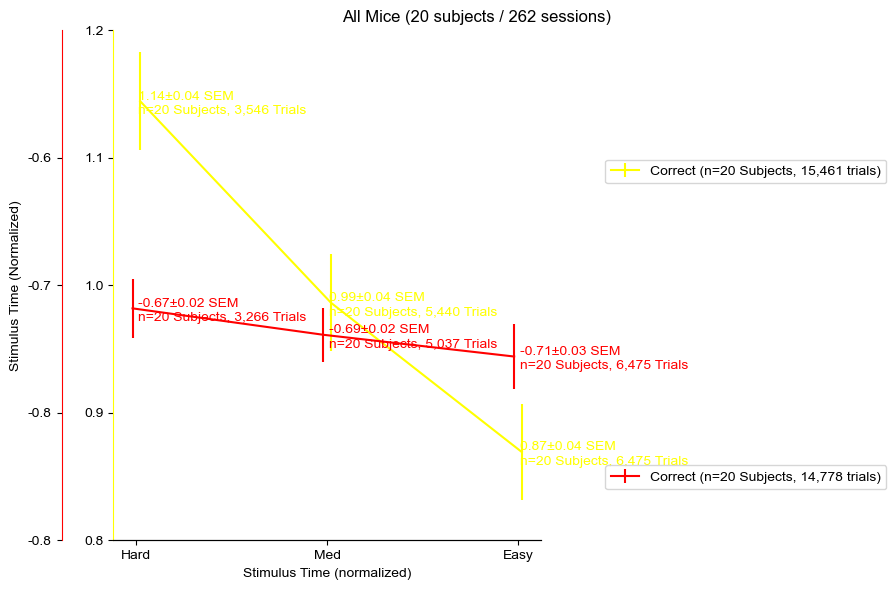

In [19]:
from .figcode.stbydifficulty import stVsDiffOnly

stVsDiffOnly(df_mice,#.groupby("Name").filter(lambda subj_Df: len(subj_Df) > 2_500),
             plot_single_subjects=False,
             y_fast_min=-.85, y_slow_min=0.8,
             save_prefix=save_prefix, save_figs=global_save_figs)

In [20]:
from .figcode.stbydifficulty import stVsDiffOnly
pathlib.Path(f"{save_prefix}/humans_st/").mkdir(exist_ok=True)

## Fig. 1g-right

biggest_rng: 2.0


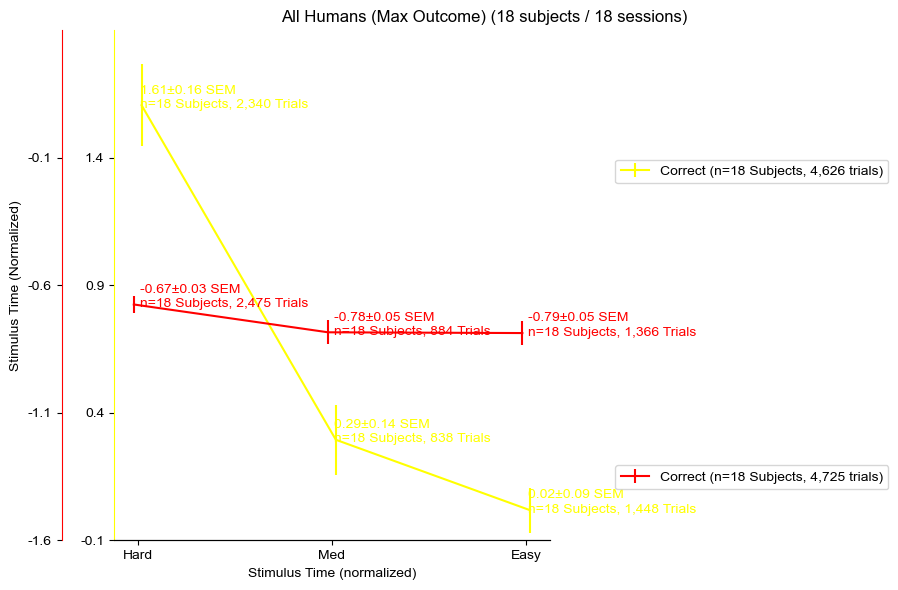

In [21]:
stVsDiffOnly(humans_max_outcome_df, plot_single_subjects=False,
             save_prefix=f"{save_prefix}/humans_st/max_outcome",
             y_fast_min=-1.6, y_slow_min=-.1,
             all_dscrp="All Humans (Max Outcome)",
             save_figs=global_save_figs)

## Ext Fig. 2a

biggest_rng: 2.4


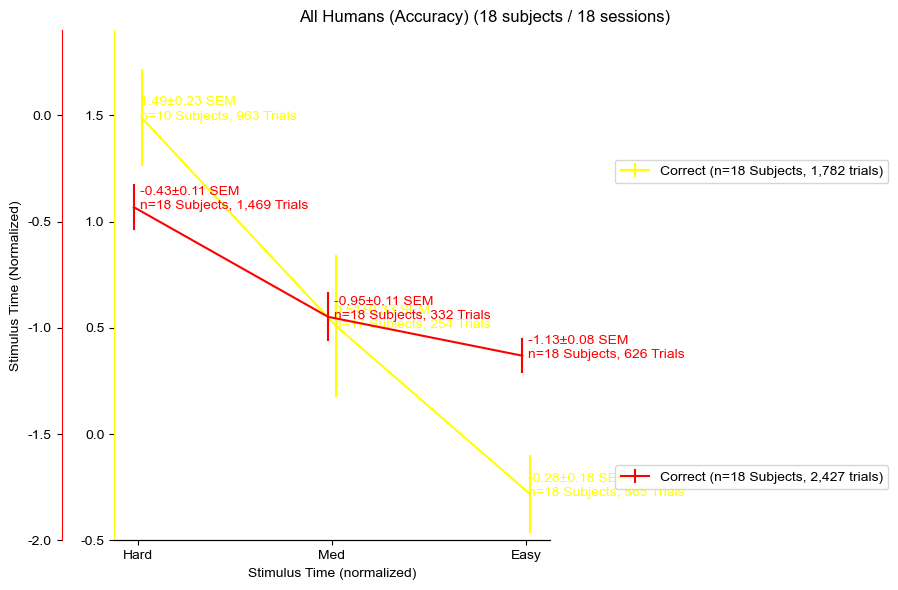

In [22]:
stVsDiffOnly(humans_accuracy_df, plot_single_subjects=False,
             save_prefix=f"{save_prefix}/humans_st/accuracy",
             y_fast_min=-2, y_slow_min=-.5,
             all_dscrp="All Humans (Accuracy)",
             save_figs=global_save_figs)

# More Human data

## Plot user data

Accuracy Competition - Num of points: 18
Maximizing Correct-Outcome Competition - Num of points: 18
Mice - Num of points: 20
Accuracy Competition
  - Normality test: ShapiroResult(statistic=0.9193683862686157, pvalue=0.1259847730398178)
Maximizing Correct-Outcome Competition
  - Normality test: ShapiroResult(statistic=0.9547122716903687, pvalue=0.5036130547523499)
Mice
  - Normality test: ShapiroResult(statistic=0.9483543634414673, pvalue=0.3427996039390564)
Data is normal
f_oneway statistics: 33.08430010554181 p_val: 4.731750500454103e-10
post_hoc_str: Tukey's test with bonferroni correction
i: 0 j: 1 val: 0.001
i: 0 j: 2 val: 0.001
i: 1 j: 2 val: 0.35642272803624675


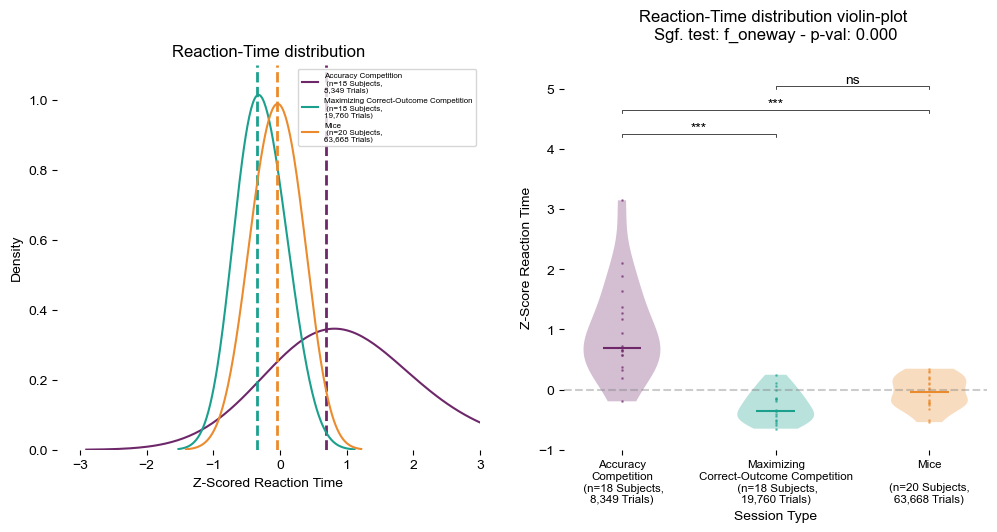

In [ ]:
from scipy import stats
from scipy.stats import zscore
import numpy as np
import seaborn as sns

def assignZScoredST(df, grpby_keys=["Name"]):
    zscored_time = df.groupby(grpby_keys, as_index=False).filter(
                      lambda df:len(df) > 50).calcStimulusTime.transform(zscore)
    df = df.copy()
    df["calcStimulusTime"] = zscored_time
    return df


def errorsDistribution(df_users,
                       animals_df=None, df_query=None, queries_labels={},
                       save_fp="", save_figs=global_save_figs):
    df_users = df_users.copy()
    df_users = assignZScoredST(df_users, grpby_keys=["Name", "session_type"])
    if animals_df is not None:
        animals_df = animals_df[animals_df.calcStimulusTime.notnull()]
        animals_df = animals_df[animals_df.ChoiceCorrect.notnull()]
        animals_df = assignZScoredST(animals_df)
    processSubject(df_users,
                   "All Subjects", is_many_subjects=True,
                   animals_df=animals_df, df_query=df_query,
                   query_labels=queries_labels, save_fp=save_fp,
                   save_figs=save_figs)

def processSubject(df_users,
                   subject_name, is_many_subjects, animals_df=None,
                   df_query=None, query_labels={}, save_fp="", save_figs=global_save_figs):

    humans_accuracy_df = df_users[df_users.session_type == "ReactionTime"]
    humans_max_outcome_df = df_users[df_users.session_type == "Competition"]

    CDF = False
    count_x = 1
    x_ticks_labels = []
    stats_dict = {}
    def plotPoints(df, color, label):
        nonlocal count_x
        if df_query is not None:
            df = df.query(df_query)
        df = df[df.calcStimulusTime.notnull()]
        if is_many_subjects:
            if "folder_name" in df.columns:
                cols = ["folder_name", "session_type"]
            else:
                cols = "Name"
            st = df.groupby(cols).calcStimulusTime.mean()
            n_str = f" (n={len(st):,} Subjects,\n{len(df):,} Trials)"
        else:
            st = df.calcStimulusTime
            n_str = f" (n={len(st):,} Trials)"
        # st = df.calcStimulusTime
        # st = st[st.notnull()]
        print(f"{label} - Num of points: {len(st):,}")
        label = f"{label}\n{n_str}"
        if CDF:
            # Create CDF plot
            x = np.sort(st)
            y = np.linspace(0, 1, len(x), endpoint=False)
            # if label == "All Animals":
            #     display(x[(x > 0.2) & (x < 0.4)])
            ax.plot(x, y, color=color, label=label)
        else:
            # Create kde plot
            sns.kdeplot(st, ax=ax, color=color, label=label, bw_adjust=2)
            # ax.axvline(st.median(), color=color, lw=1, ls="--")
            ax.axvline(st.median(), color=color, lw=2, ls="--")
        stats_dict[label] = st
        _dict = ax_err.violinplot(st, positions=[count_x], widths=0.5,
                                  showextrema=False, showmedians=True,)
        # Color the violin
        for pc in _dict['bodies']:
            pc.set_facecolor(color)
        _dict['cmedians'].set_color(color)
        if is_many_subjects:
            ax_err.scatter([count_x]*len(st), st, s=1, c=color, alpha=0.5)
        x_ticks_labels.append(label.replace(" ", "\n", 1))
        count_x += 1

    fig, (ax , ax_err) = plt.subplots(1, 2, figsize=(6 if CDF else 12, 5))
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax_err.spines[["top", "right", "left", "bottom"]].set_visible(False)
    for sess_type, color, cur_df in [
                ("Accuracy Competition", COLOR_ACCURACY, humans_accuracy_df),
                ("Maximizing Correct-Outcome Competition", COLOR_MAX_OUTCOME, humans_max_outcome_df)]:
        # print("Processingf:", sess_type)
        plotPoints(cur_df, color, sess_type)
    if animals_df is not None:
        plotPoints(animals_df, COLOR_MICE, "Mice")

    # ax.axvline(0, color='gray', alpha=0.4, lw=1, ls="--")
    ax.set_xlim(right=3)
    ax.set_ylabel("Density")

    ax.set_ylim(0, 1.1)
    ax.set_xlabel("Z-Scored Reaction Time")
    extra_label = query_labels.get(df_query, "")
    if len(extra_label):
        extra_label = f" {extra_label}"
    ax.set_title(f"Reaction-Time distribution" + # - {subject_name}" +
                 extra_label)
    ax.legend(loc='lower right' if CDF else 'upper right', fontsize="xx-small")


    # Check for normality
    normality_stats = {label:stats.shapiro(st)
                       for label, st in stats_dict.items()}
    is_normal = True
    for label, test_stat in normality_stats.items():
        print(f"{label.split('(')[0]} - Normality test:", test_stat)
        if test_stat.pvalue < 0.05:
            is_normal = False
    if not is_normal:
        print("Data is not normal")
        STtest = stats.kruskal
    else:
        print("Data is normal")
        STtest = stats.f_oneway
    # print("Normality test:", stats.shapiro(stats_df))
    statistics, p_val = STtest(*stats_dict.values())
    print(STtest.__name__, "statistics:", statistics, "p_val:", p_val)
    import scikit_posthocs as sp
    if STtest.__name__ == "kruskal":
        p_adjust = "holm"
        corr_res = sp.posthoc_dunn([*stats_dict.values()] , p_adjust)
        post_hoc_str = f"Dunn's test with {p_adjust} correction"
    else:
        p_adjust = "bonferroni"
        corr_res = sp.posthoc_tukey([*stats_dict.values()] , p_adjust)
        post_hoc_str = f"Tukey's test with {p_adjust} correction"
    print("post_hoc_str:", post_hoc_str)


    max_y = 4.2
    for i, (_, row) in enumerate(corr_res.iterrows()):
        j_start = i + 1 # skip the mirrored part
        # print("i:", i, j_start)
        for j, val in enumerate(row[j_start:], j_start):
            print("i:", i, "j:", j, "val:", val)
            # if val <= 0.05:
            if True:
                # print(f"({keys[i]}, {keys[j]}) is significant")
                star = "***" if val <= 0.001 else "**" if val <= 0.01 else (
                        "*" if val <= 0.05 else "ns")
                i_ = i + 1
                j_ = j + 1
                ax_err.plot([i_, i_, j_, j_],
                            [max_y, max_y+0.05, max_y+0.05, max_y],
                            lw=.5, c='k')
                ax_err.text((i_+j_)/2, max_y+0.04, star, ha='center',
                            va='bottom', c='k')
                max_y += 0.4

    ax_err.axhline(0, color='gray', alpha=0.4, ls="--")
    ax_err.set_xticks(range(1, count_x))
    ax_err.set_xticklabels(x_ticks_labels, fontsize="small")
    ax_err.set_xlabel("Session Type")
    extr_str = "" if df_query is None else (
               "Incorrect-Choice " if "ChoiceCorrect == False" in df_query else
               "Correct-Choice")
    ax_err.set_ylabel(f"Z-Score {extr_str}Reaction Time")
    MIN_Y = -1
    ax_err.set_ylim(MIN_Y, max_y)
    ax_err.set_title(f"Reaction-Time distribution violin-plot {extra_label}\n"
                     f"Sgf. test: {STtest.__name__} - p-val: {p_val:.3f}\n")
    if save_figs:
        plt.savefig(
                   f"{save_fp}/humans_mice_reaction_time_dist{extra_label}.svg")
    plt.show()


errorsDistribution(df_users,  animals_df=df_mice,
                   save_fp=save_prefix, save_figs=global_save_figs)

### Per-subject z-scored sampling time & subject-sigma dispersion

Accuracy Competition - Num of subjects: 18 - Num of trials: 8,349
Maximizing Correct-Outcome Competition - Num of subjects: 18 - Num of trials: 19,760
Mice - Num of subjects: 20 - Num of trials: 63,668
Accuracy Competition
 (n=18 Subjects,
8,349 Trials) - Normality test: ShapiroResult(statistic=0.9320572018623352, pvalue=0.2110295295715332)
Maximizing Correct-Outcome Competition
 (n=18 Subjects,
19,760 Trials) - Normality test: ShapiroResult(statistic=0.8967061042785645, pvalue=0.050362300127744675)
Mice
 (n=20 Subjects,
63,668 Trials) - Normality test: ShapiroResult(statistic=0.950698733329773, pvalue=0.3778201937675476)
Data is normal
f_oneway statistics: 30.18426997293759 p_val: 1.7752432807026352e-09
post_hoc_str: Tukey's HSD test


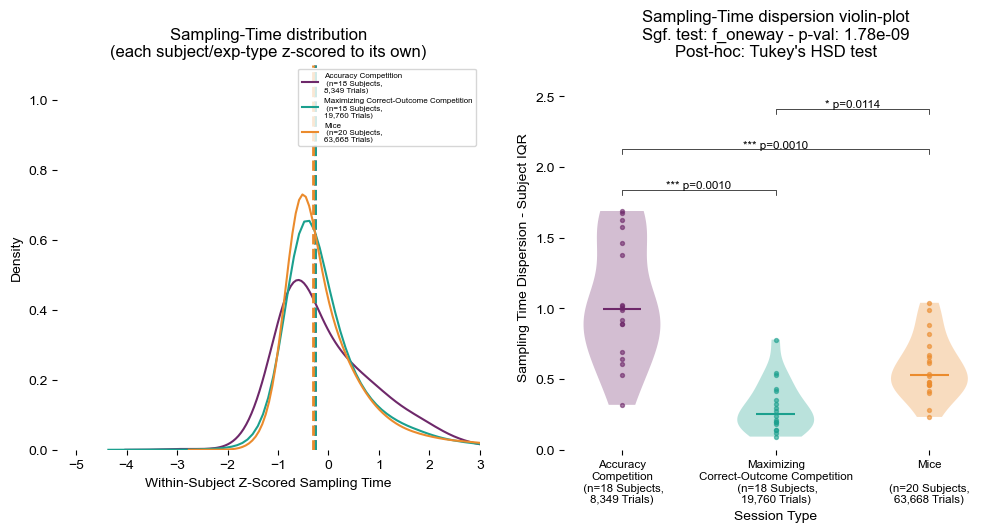

In [ ]:
from .behavior.stdispersion import plotSTDispersion

# Same figure as above but: (1) each human subject x experiment-type is
# z-scored to its own trials (instead of the subject's session types being
# pooled), (2) each mouse is z-scored to its own trials (instead of pooling
# across animals), and (3) the right panel shows the dispersion of the raw
# (seconds) sampling time -- sigma or IQR, see DISPERSION_MEASURE below -- one
# point per subject x experiment-type. The z-scored dispersion is 1.0 for every
# subject by construction, hence the raw column there; likewise every subject's
# z-scored mean is 0, so the left panel shows the trial-level z-scores rather
# than subject means.
SESSION_TYPES = [("Accuracy Competition", "ReactionTime"),
                 ("Maximizing Correct-Outcome Competition", "Competition")]
GROUP_COLORS = {"Accuracy Competition": COLOR_ACCURACY,
                "Maximizing Correct-Outcome Competition": COLOR_MAX_OUTCOME,
                "Mice": COLOR_MICE}

# "std" -> subject sigma, "iqr" -> subject inter-quartile range (robust to the
# long right tail). Each measure saves under its own file name.
DISPERSION_MEASURE = "iqr"

_ = plotSTDispersion(df_users, animals_df=df_mice, colors=GROUP_COLORS,
                     session_types=SESSION_TYPES,
                     measure=DISPERSION_MEASURE,
                     save_fp=save_prefix, save_figs=global_save_figs)

## Humans fast/slow mean performance

## Ext. Fig. 2l

Humans Accuracy pval original: 0.16527501785632176 corrected: 0.16527501785632176
Humans Max Outcome pval original: 0.0028925858031055435 corrected: 0.005785171606211087
Mice pval original: 0.00014015612239376147 corrected: 0.0004204683671812844


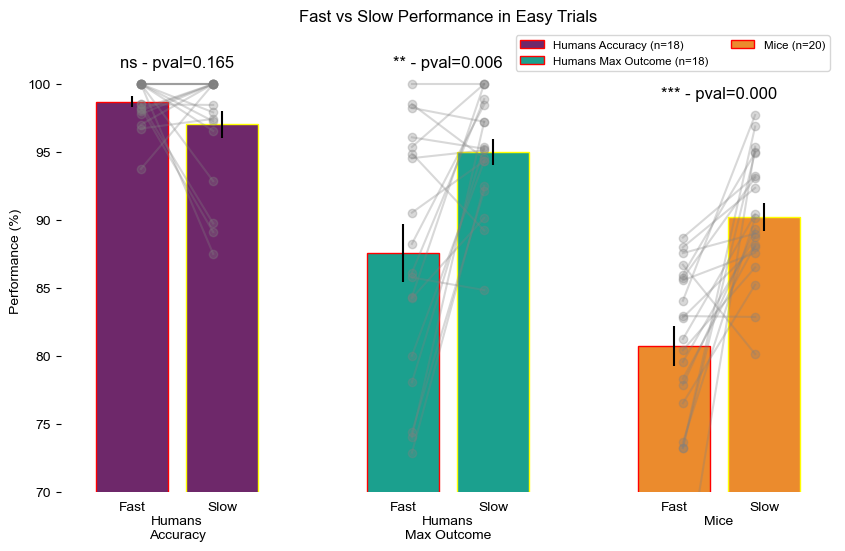

In [24]:
from scipy import stats
from statsmodels.stats.multitest import multipletests


def _plotGroup(fast_perfs, slow_perfs, ax, x, label, color):
    x0, x1 = x, x + 1
    for fast_perf, slow_perf in zip(fast_perfs, slow_perfs):
        ax.plot([x0 + .1, x1 - .1], [fast_perf, slow_perf], color="gray",
                alpha=0.3,
                marker="o")
    n_subjects = len(fast_perfs)
    ax.bar([x0, x1], [np.mean(fast_perfs), np.mean(slow_perfs)],
           yerr=[stats.sem(fast_perfs), stats.sem(slow_perfs)],
           color=color,
           edgecolor=["red", "yellow"],
        #    edgecolor="C0",
           alpha=1, zorder=-10,
           label=f"{label} (n={n_subjects})")

    test_res = stats.ttest_rel(fast_perfs, slow_perfs)
    return test_res.pvalue

def localSlowFasPsych(humans_max_outcome_df, humans_accuracy_df, df_animals,
                      save_fp="", save_figs=global_save_figs,):

    # Assign humans to easy
    humans_max_outcome_df = humans_max_outcome_df[humans_max_outcome_df.DV.abs() >= .15]
    humans_accuracy_df = humans_accuracy_df[humans_accuracy_df.DV.abs() >= .15]
    df_animals = df_animals[df_animals.DVstr.isin(["Easy"])]

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    def getFastSlowPerfs(df):
        df = df[df.ChoiceCorrect.notnull()]
        fast_perfs = df[df.quantile_idx == 1].ChoiceCorrect.mean()*100
        slow_perfs = df[df.quantile_idx == 3].ChoiceCorrect.mean()*100
        return fast_perfs, slow_perfs

    accuracy_fast_perfs, accuracy_slow_perfs = [], []
    count_fast_perfs, count_slow_perfs = [], []
    for subj in humans_max_outcome_df.Name.unique():
        accuracy_exp_df = humans_accuracy_df[humans_accuracy_df.Name == subj]
        count_exp_df = humans_max_outcome_df[humans_max_outcome_df.Name == subj]
        assert len(accuracy_exp_df)
        assert len(count_exp_df)
        accuracy_fast_perf, accuracy_slow_perf = getFastSlowPerfs(accuracy_exp_df)
        count_fast_perf, count_slow_perf = getFastSlowPerfs(count_exp_df)
        accuracy_fast_perfs.append(accuracy_fast_perf)
        accuracy_slow_perfs.append(accuracy_slow_perf)
        count_fast_perfs.append(count_fast_perf)
        count_slow_perfs.append(count_slow_perf)


    pvals = []
    pvals.append(_plotGroup(accuracy_fast_perfs, accuracy_slow_perfs, ax, 0,
                            "Humans Accuracy",
                            color=COLOR_ACCURACY))
    pvals.append(_plotGroup(count_fast_perfs, count_slow_perfs, ax, 3,
                            "Humans Max Outcome",
                            color=COLOR_MAX_OUTCOME))

    if df_animals is not None:
        animals_fast_perfs, animals_slow_perfs = [], []
        for subj in df_animals.Name.unique():
            sub_df = df_animals[df_animals.Name == subj]
            fast_perf, slow_perf = getFastSlowPerfs(sub_df)
            animals_fast_perfs.append(fast_perf)
            animals_slow_perfs.append(slow_perf)
        pvals.append(_plotGroup(animals_fast_perfs, animals_slow_perfs, ax, 6, "Mice",
                                color=COLOR_MICE))

    # Correct for multiple comparisons
    reject, pvals_corrected, _, _ = multipletests(pvals, method='holm')
    labels = ["Humans Accuracy", "Humans Max Outcome", "Mice"]
    y_maxs = [max(max(accuracy_fast_perfs), max(accuracy_slow_perfs)),
              max(max(count_fast_perfs), max(count_slow_perfs)),
              max(max(animals_fast_perfs), max(animals_slow_perfs))]
    for i, (pval, pval_corr, rej) in enumerate(zip(pvals, pvals_corrected, reject)):
        x0 = i*3
        x1 = x0 + 1
        label = labels[i]
        print(label, "pval original:", pval, "corrected:", pval_corr)
        max_height = y_maxs[i]
        sgf_str = "***" if pval_corr <= 0.001 else (
                    "**" if pval_corr <= 0.01 else (
                    "*" if pval_corr <= 0.025 else "ns"))

        ax.annotate(f"{sgf_str} - pval={pval_corr:.3f}",
                    xy=((x0 + x1)/2, max_height + 1),
                    ha='center', va='bottom',
                    fontsize="large", color='k')
        # ax.plot([x0, x0, x1, x1],
        #         [max_height-1, max_height, max_height, max_height-1],
        #         lw=.5, c='k')
        # ax.text((x0+x1)/2, max_height, sgf_str, ha='center',
        #         va='bottom', c='k')
        # print(f"Comparison {i} - original p-val: {pval:.4f}, "
        #       f"corrected p-val: {pval_corr:.4f}, reject H0: {rej}")

    ax.legend(loc='upper right', fontsize="small", ncol=2)

    ax.set_title("Fast vs Slow Performance in Easy Trials")
    ax.set_xticks([0, .5, 1, 3, 3.5, 4, 6, 6.5, 7])
    ax.set_xticklabels(["Fast", "\nHumans\nAccuracy", "Slow",
                        "Fast", "\nHumans\nMax Outcome","Slow",
                        "Fast", "\nMice", "Slow"])
    # Remove x ticks
    ax.tick_params(axis='x', which='both', bottom=False, top=False)
    ax.set_ylabel("Performance (%)")

    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_ylim(70, 104)

    if save_figs:
        plt.savefig(f"{save_fp}/slow_fast_perf.svg", bbox_inches='tight')
    plt.show()

localSlowFasPsych(humans_max_outcome_df, humans_accuracy_df,
                  df_animals=df_mice,
                  save_fp=save_prefix, save_figs=global_save_figs)


# Psychometric (overall) - Humans & Mice

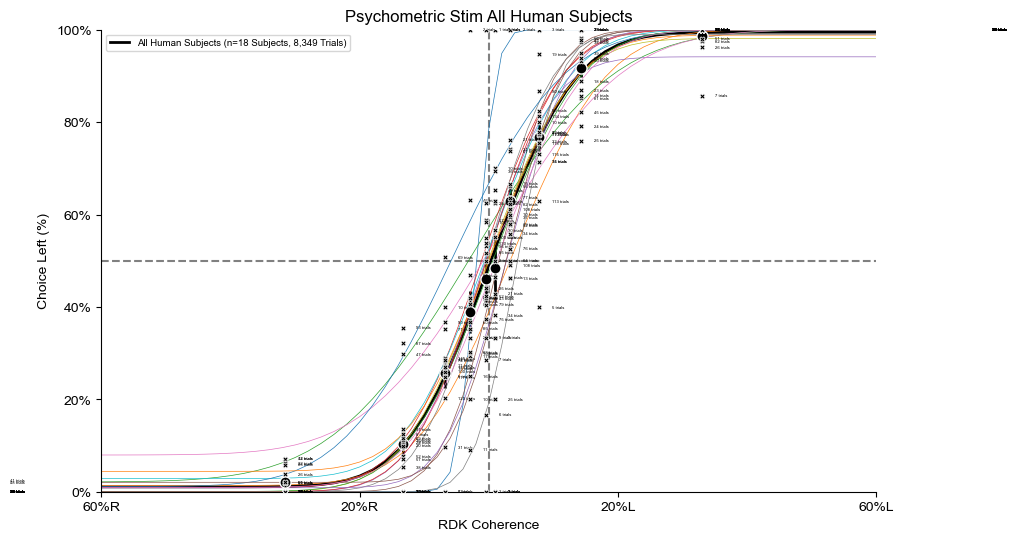

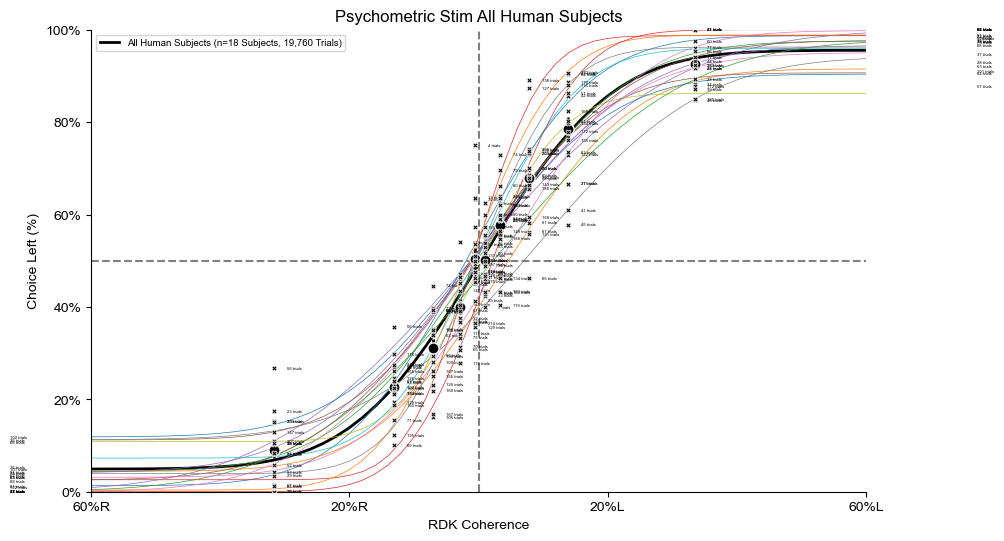

c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 33.714285714285715 - SEM: nan - len(perf_col): 1


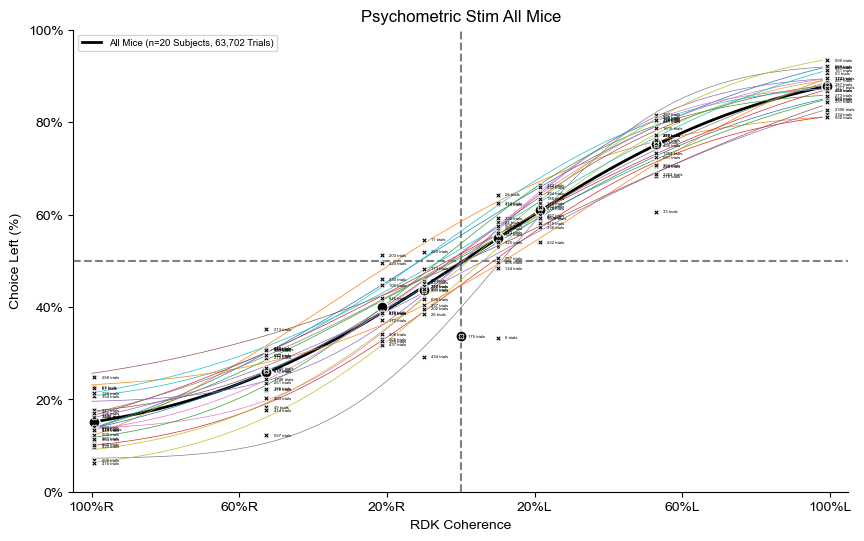

In [25]:
from .figcode.psychometric import loopPsych

def localSPsych(humans_accuracy_df, humans_max_outcome_df, df_animals, save_fp="", save_figs=global_save_figs,):
    for sess_type, cur_df, is_human in [("Accuracy Competition", humans_accuracy_df, True),
                                        ("Maximizing Correct-Outcome Competition", humans_max_outcome_df, True),
                                        ("Mice", df_animals, False),
                                    ]:
        loopPsych(cur_df, title=sess_type, is_human_subject=is_human,
                  combine_sides=False, save_fp=f"{save_fp}/psych/",
                  plot_single_subjects=False,
                  save_figs=save_figs)


localSPsych(humans_accuracy_df, humans_max_outcome_df, df_animals=df_mice,
            save_fp=save_prefix, save_figs=global_save_figs)

# RT vs Difficulty (overall) - Humans & Mice

In [26]:
from .figcode.stbydifficulty import loopstVsDiffOnly


## Ext. Fig 2e

TODO: Rename this function and the function below to: fastSlowStVsDIffOnly
GP4-85


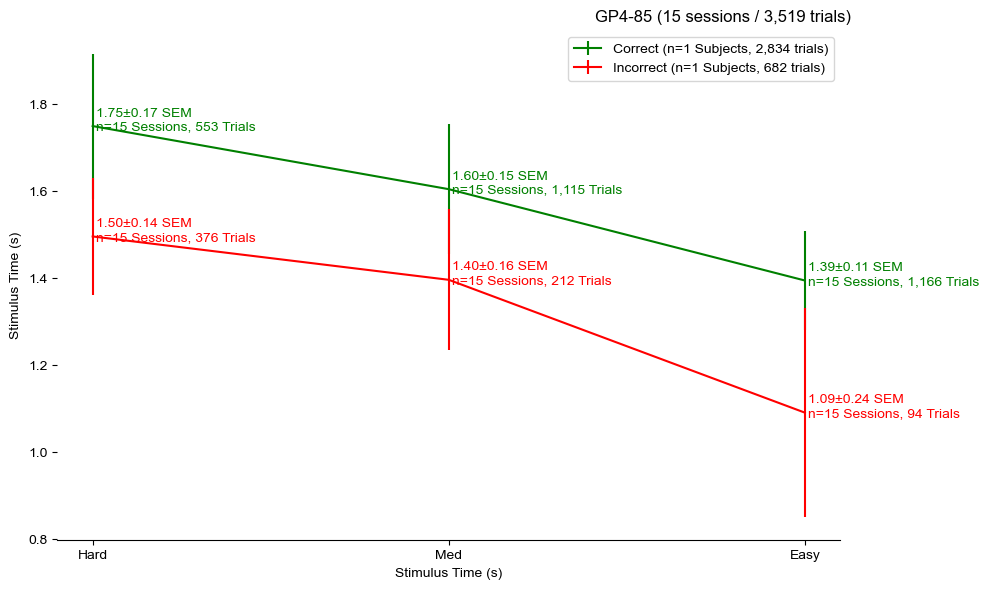

In [27]:
loopstVsDiffOnly(df_mice[df_mice.Name == "GP4-85"],
                 title="Mice",
                 plot_combined_subjects=False,
                 plot_single_subjects=True,
                 save_prefix=f"{save_prefix}/",  save_figs=global_save_figs)

## Ext. Fig 2h

TODO: Rename this function and the function below to: fastSlowStVsDIffOnly


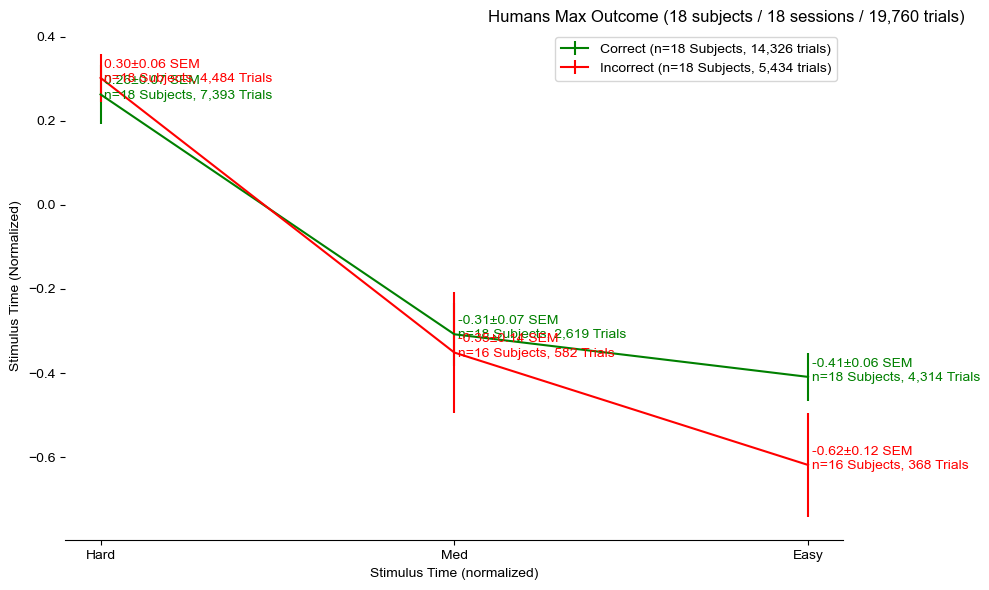

In [28]:

loopstVsDiffOnly(humans_max_outcome_df, title="Humans Max Outcome", plot_single_subjects=False,
                 save_prefix=f"{save_prefix}/",  save_figs=global_save_figs)

## Ext. Fig 2k

TODO: Rename this function and the function below to: fastSlowStVsDIffOnly


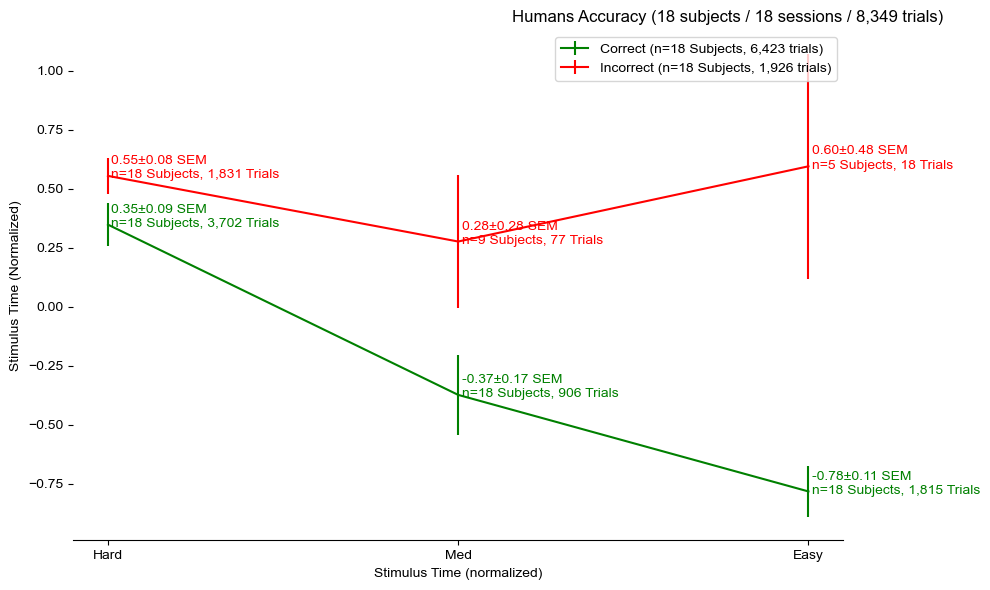

In [29]:
from .figcode.stbydifficulty import loopstVsDiffOnly

loopstVsDiffOnly(humans_accuracy_df, title="Humans Accuracy", plot_single_subjects=False,
                 save_prefix=f"{save_prefix}/",  save_figs=global_save_figs)

## Per subject figures

TODO: Rename this function and the function below to: fastSlowStVsDIffOnly
Avgat1


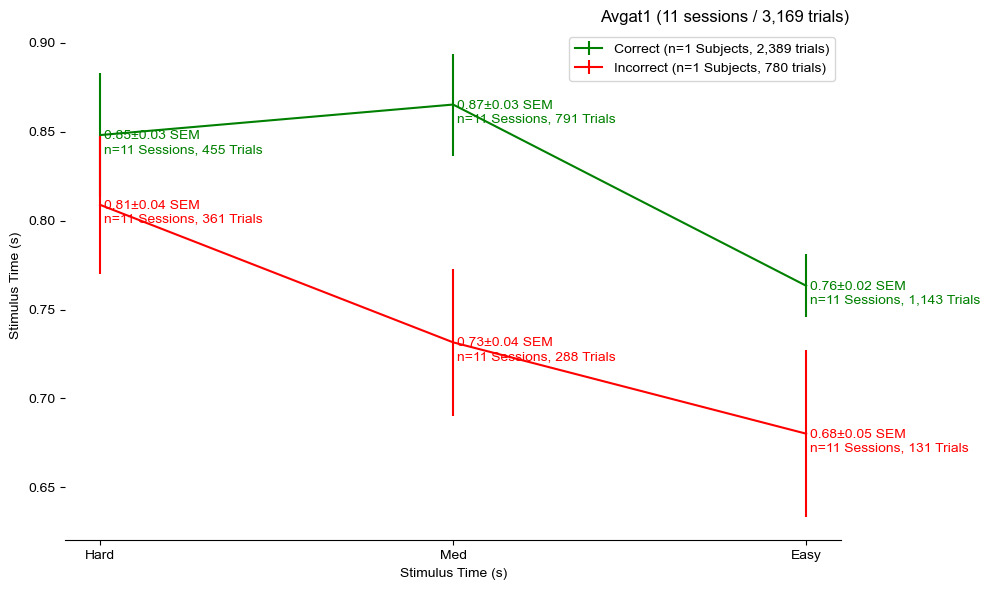

Avgat2


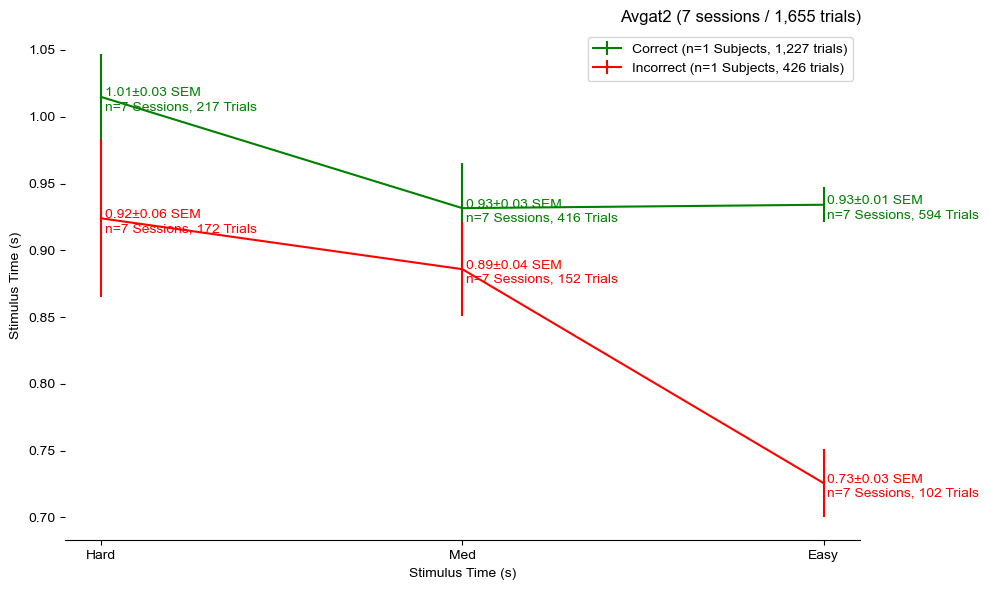

Avgat3


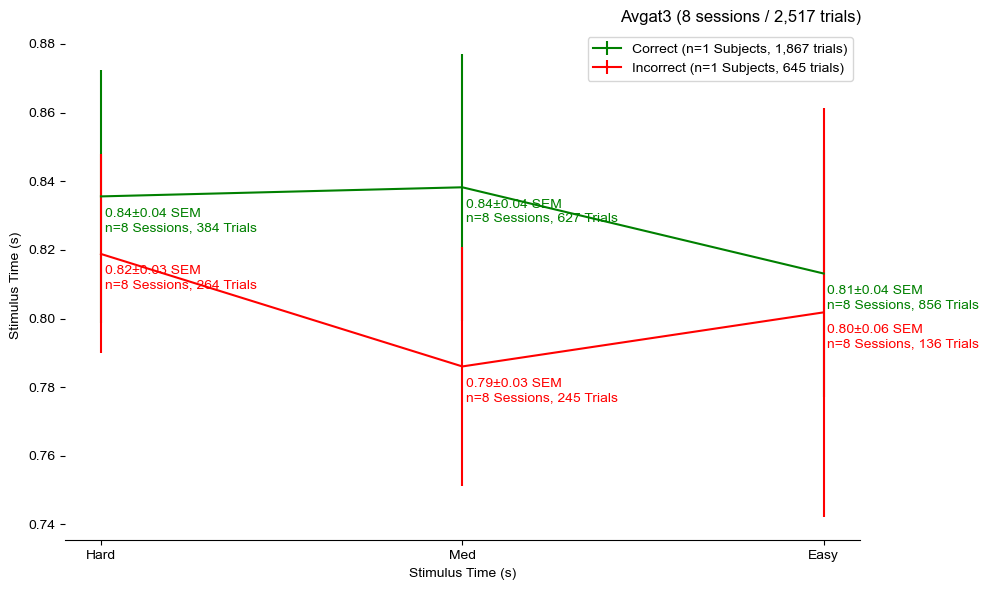

BVGAT1


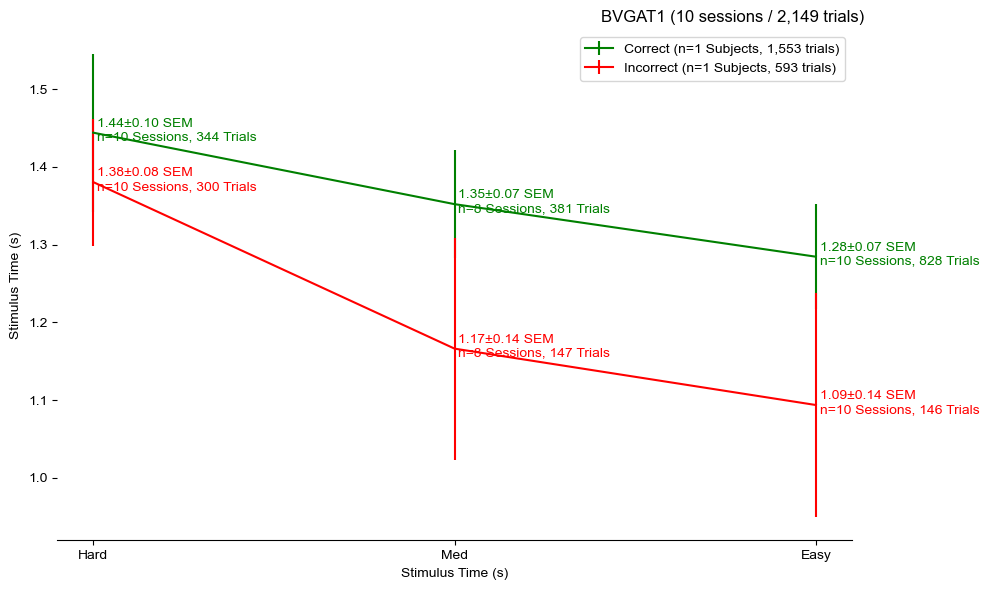

GP4-24


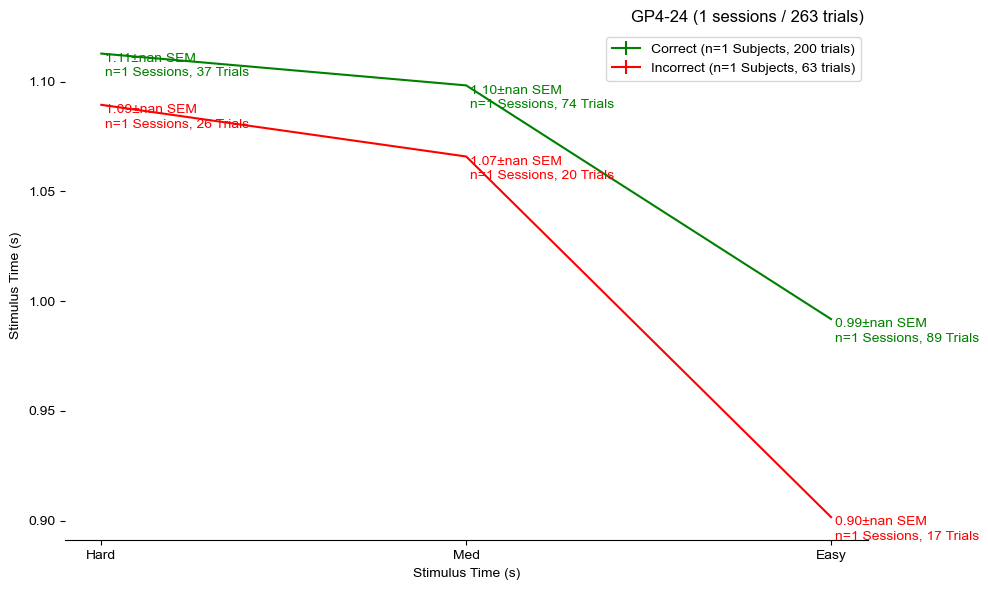

GP4-80


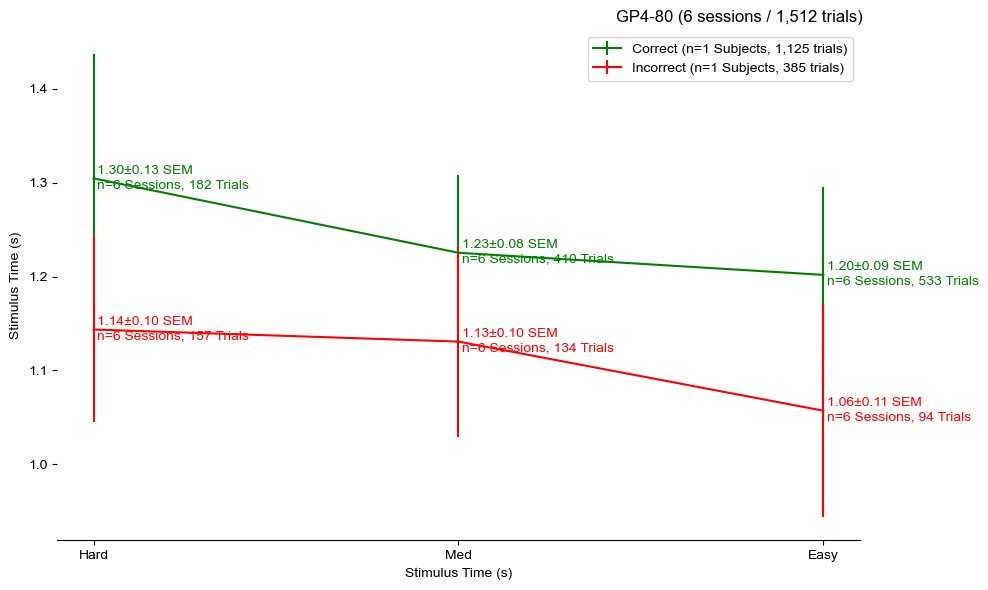

GP4-81


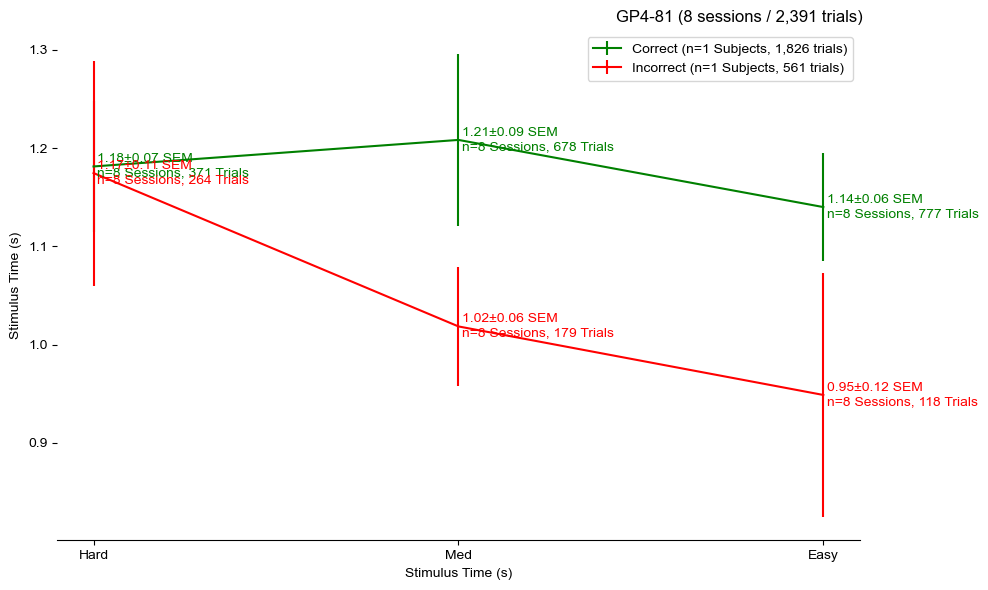

GP4-85


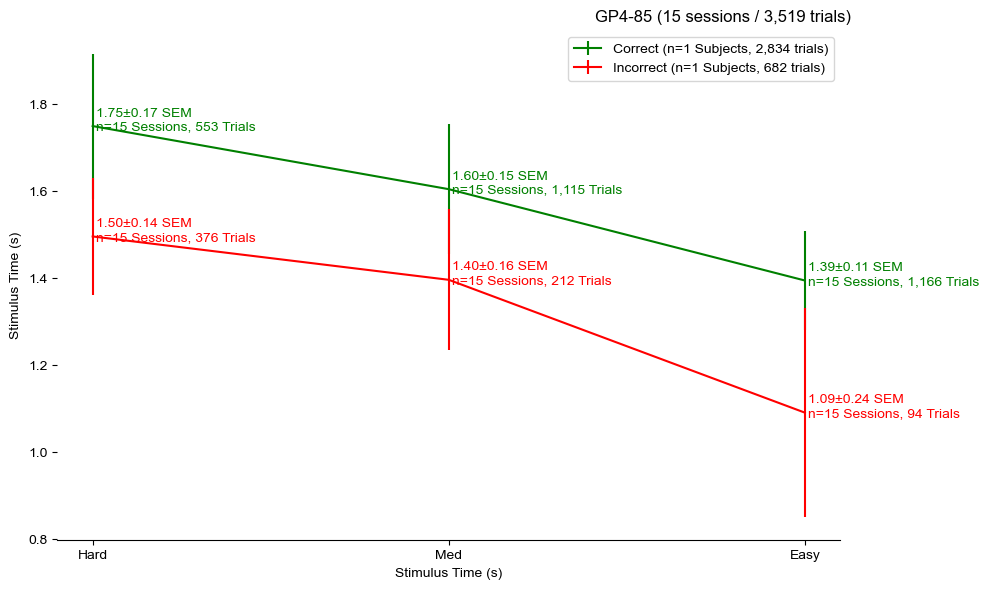

RDK_WT1


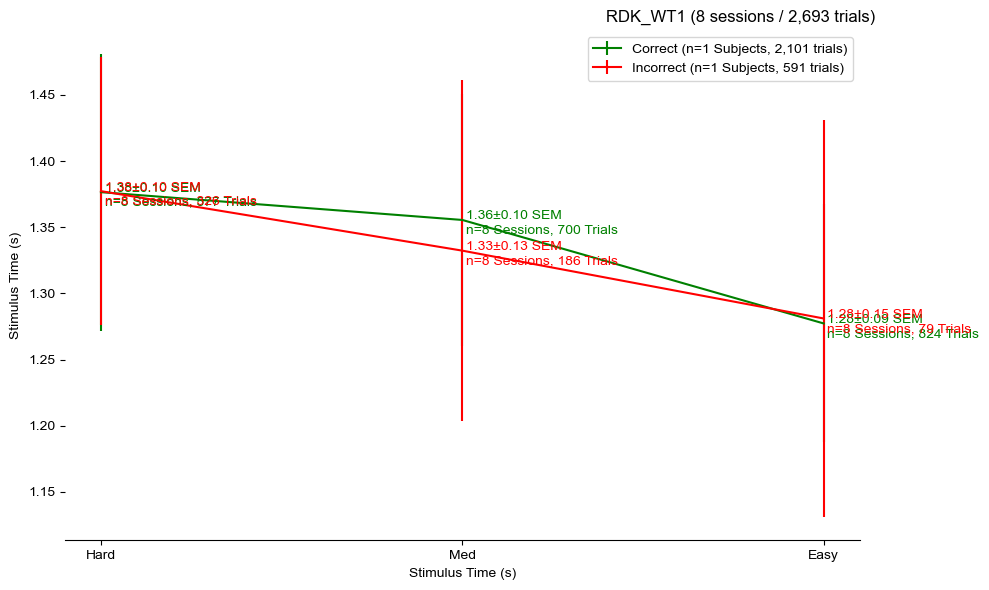

RDK_WT6


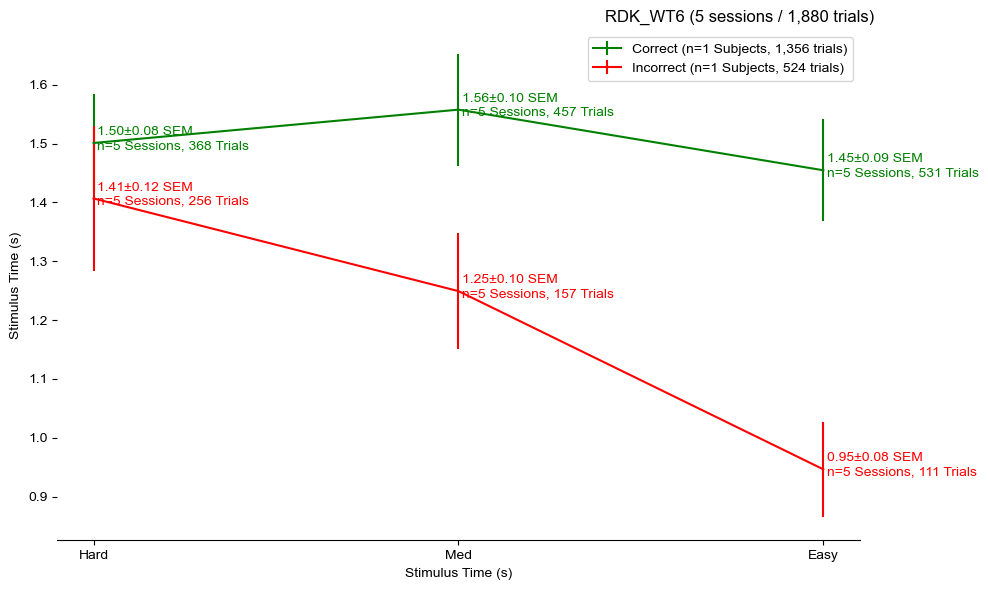

Rbp4_M2_1


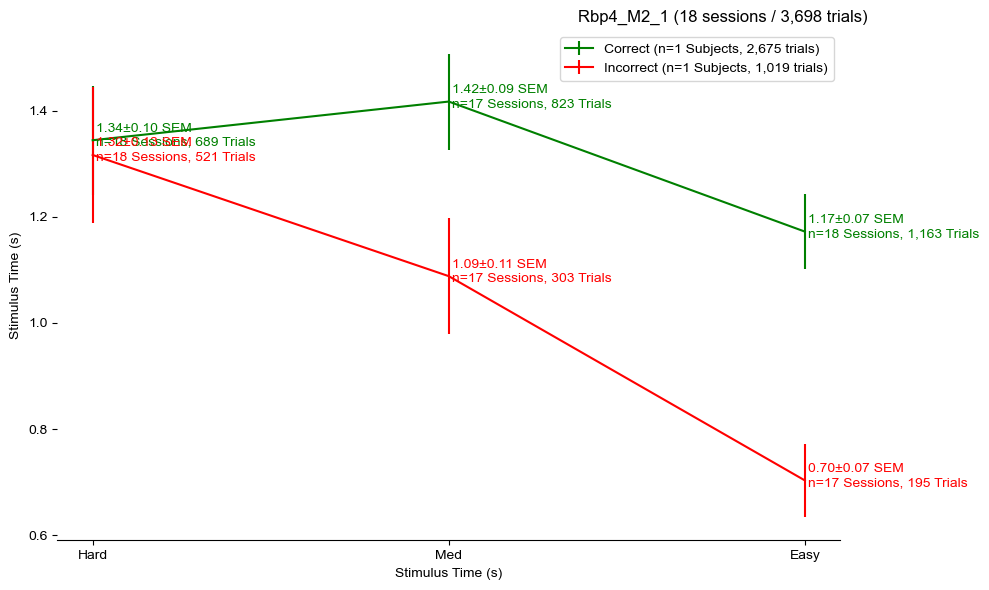

WF10


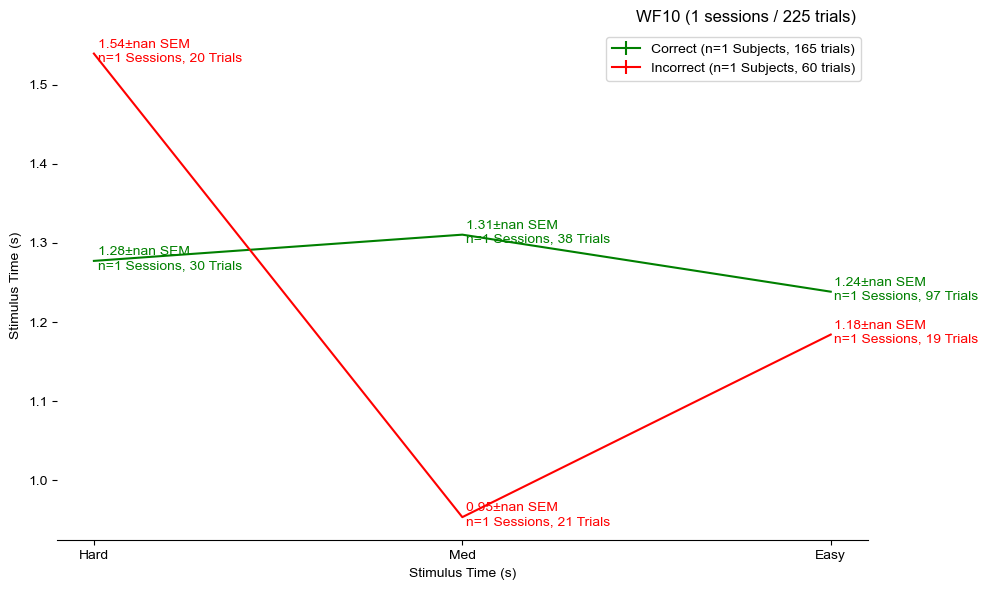

WF11


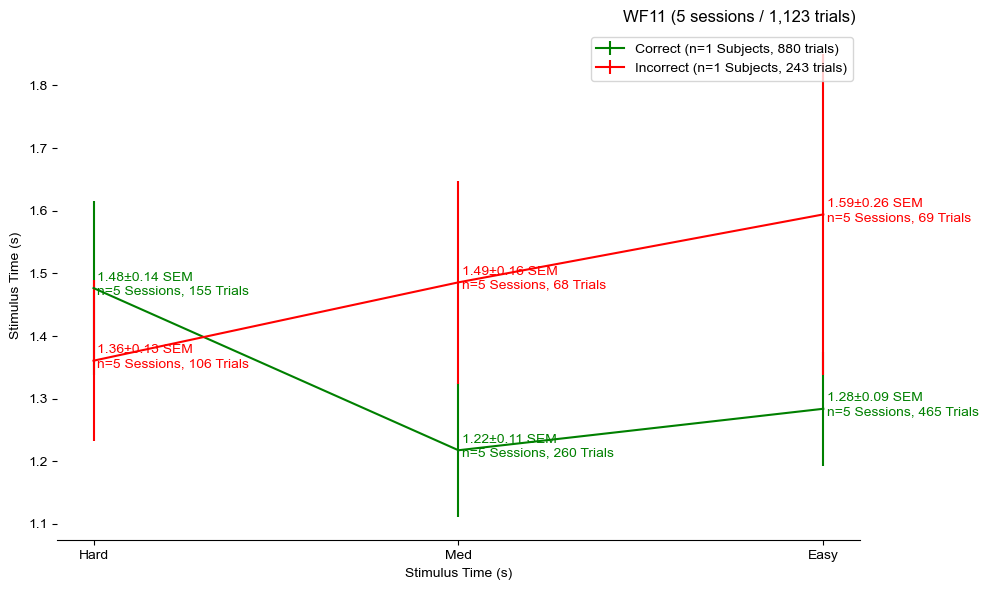

vgat-40


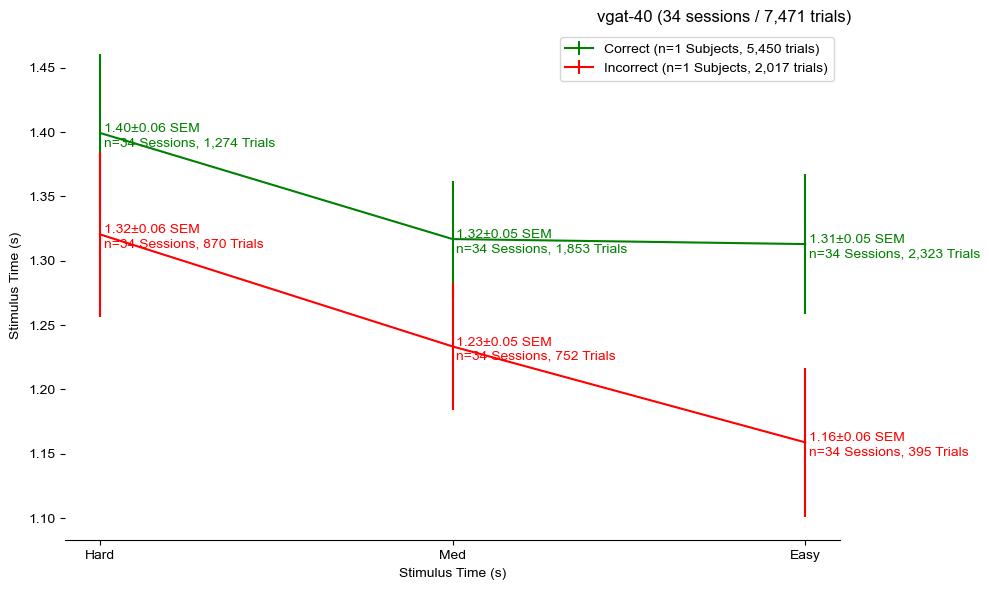

vgat-94


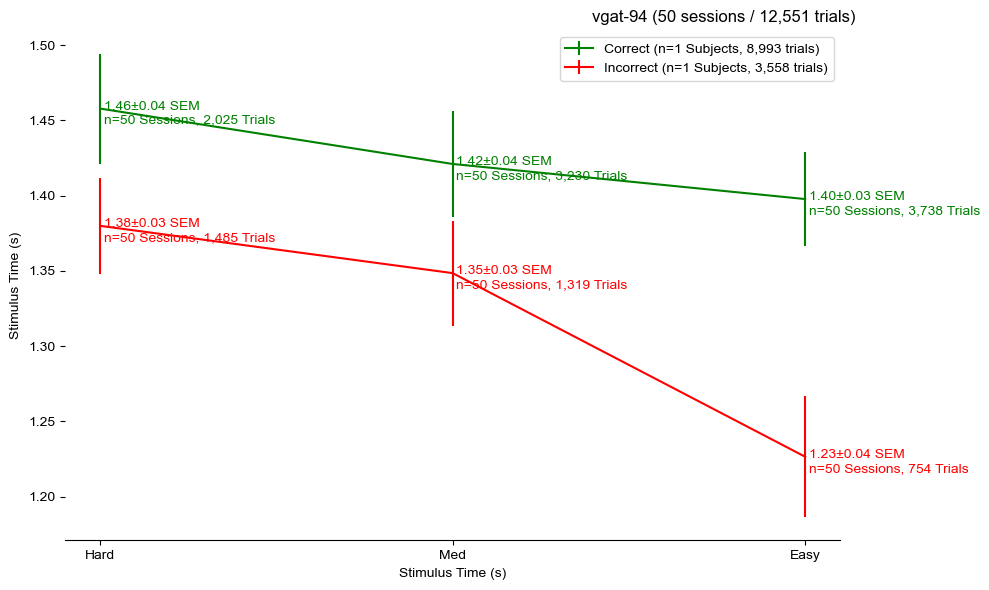

vgat-95


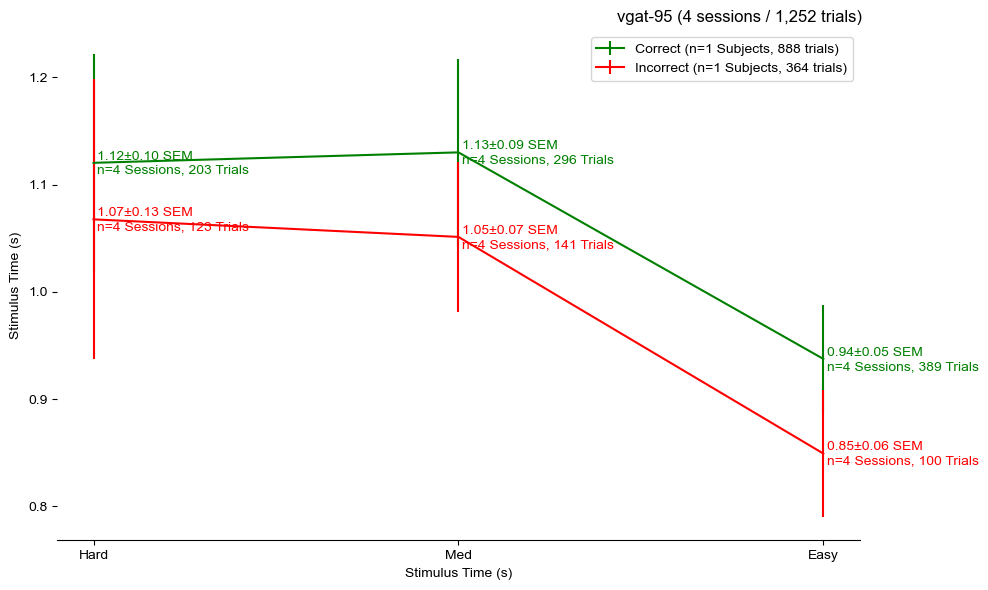

vgat-96


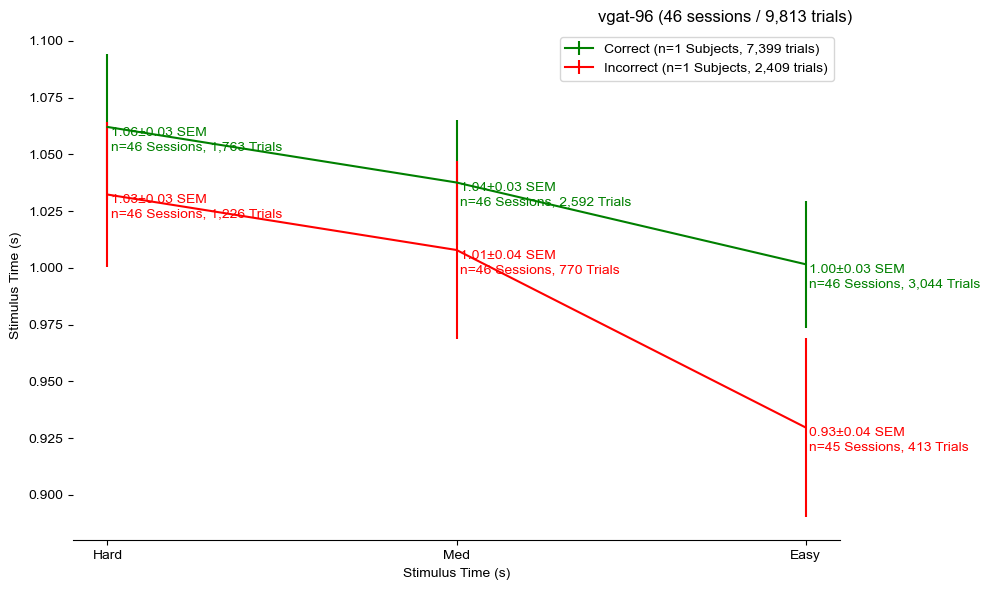

vgat2.5


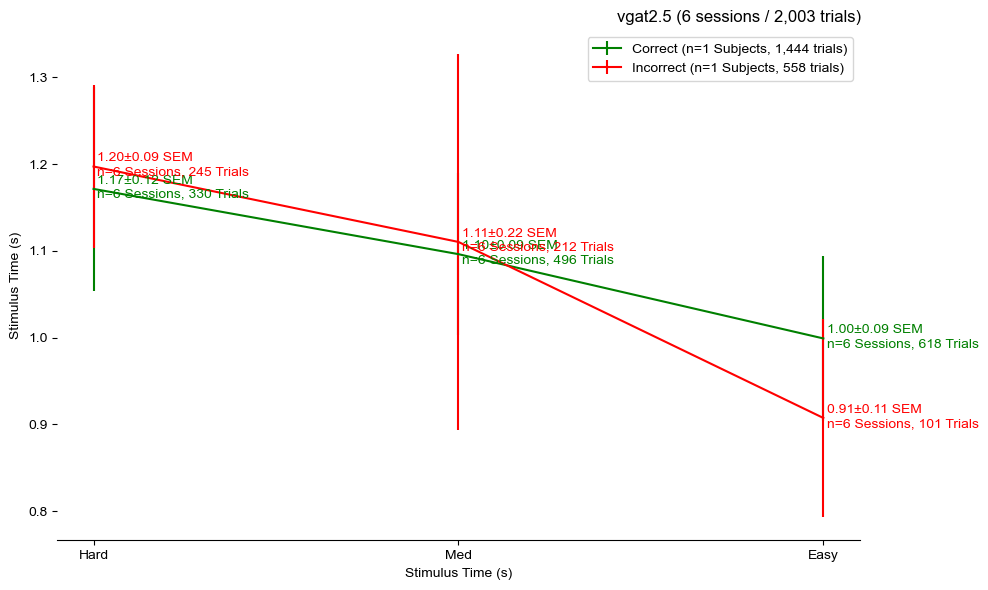

vgatchr2-sk


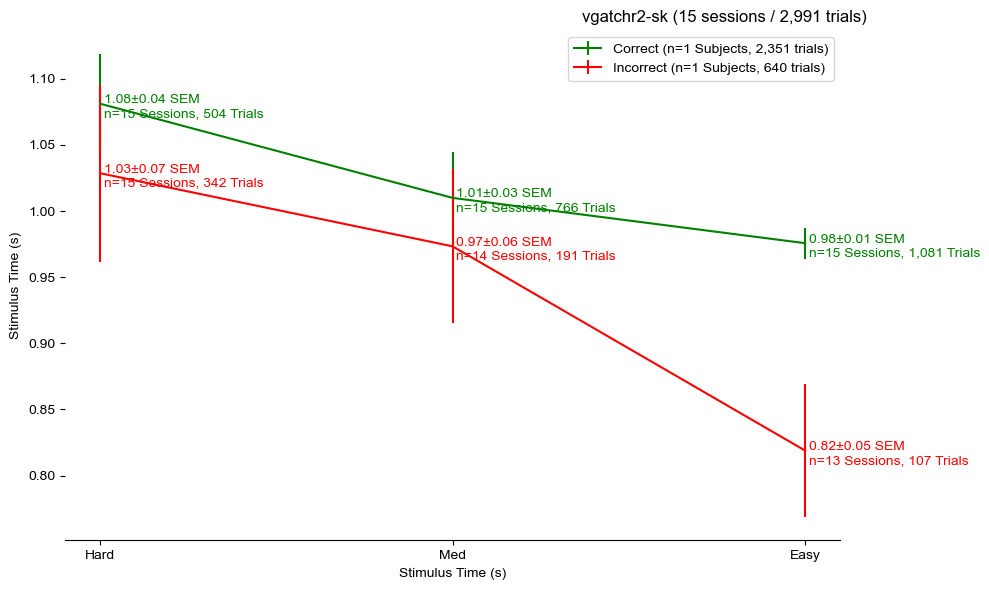

widefield_1


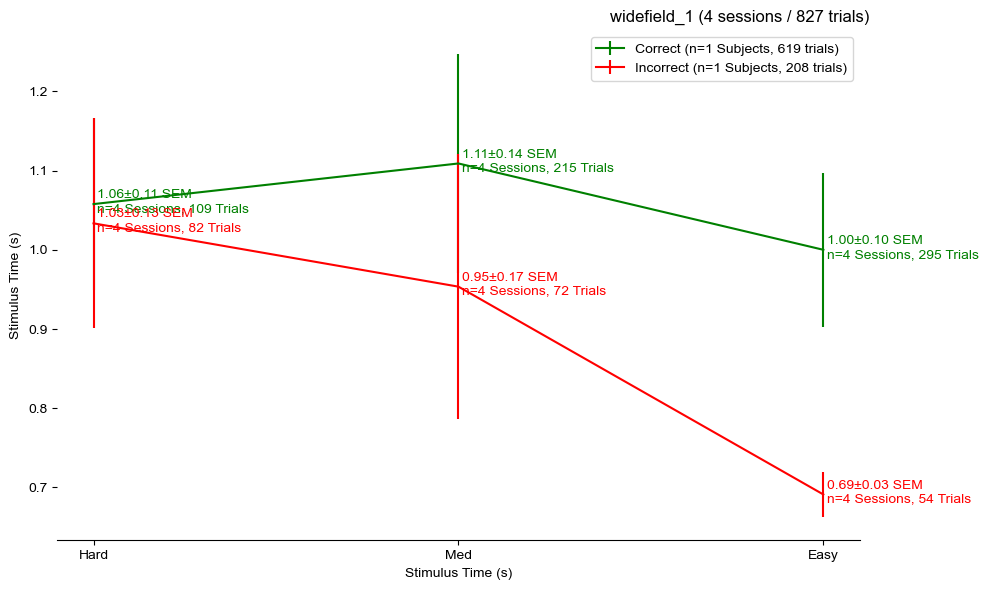

In [30]:
loopstVsDiffOnly(df_mice,
                 title="Mice",
                 plot_combined_subjects=False,
                 plot_single_subjects=True,
                 save_prefix=f"{save_prefix}/",  save_figs=global_save_figs)

# Priors effect on current trial stimulus time

# Reaction-Time Heatmap

## Ext. Fig 2e-right, f

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:146: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for grp_name, grp_st in indx_groups:
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:146: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of len

sub_index: <pandas.core.groupby.generic.DataFrameGroupBy object at 0x000001C6B8C44250> <class 'pandas.core.groupby.generic.DataFrameGroupBy'>
sub_index: <pandas.core.groupby.generic.DataFrameGroupBy object at 0x000001C6B612A150> <class 'pandas.core.groupby.generic.DataFrameGroupBy'>
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): -0.14006728627566162
	Prev. Not-Rewarded, Cur. Hard, Prev.Easy	Prev. Not-Rewarded, Cur. Hard, Prev.Hard	Prev. Not-Rewarded, Cur. Easy, Prev.Easy	Prev. Not-Rewarded, Cur. Easy, Prev.Hard	Prev. Rewarded, Cur. Hard, Prev.Easy	Prev. Rewarded, Cur. Hard, Prev.Hard	Prev. Rewarded, Cur. Easy, Prev.Easy	Prev. Rewarded, Cur. Easy, Prev.Hard	
Prev. Not-Rewarded, Cur. Hard, Prev.Easy	1.00000	0.24316	0.

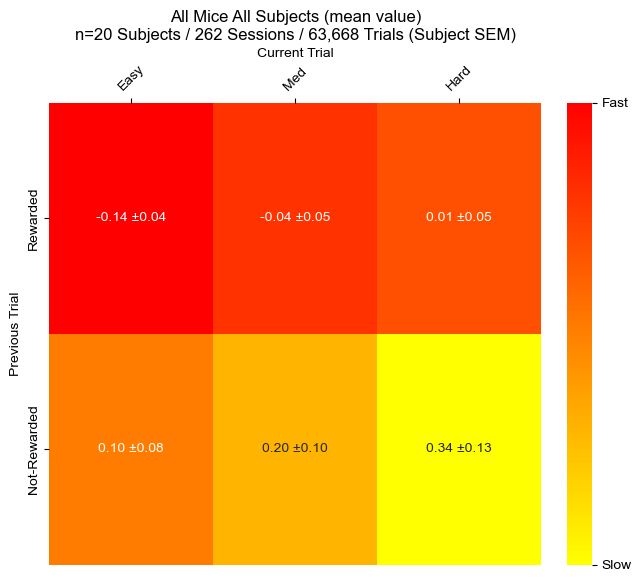

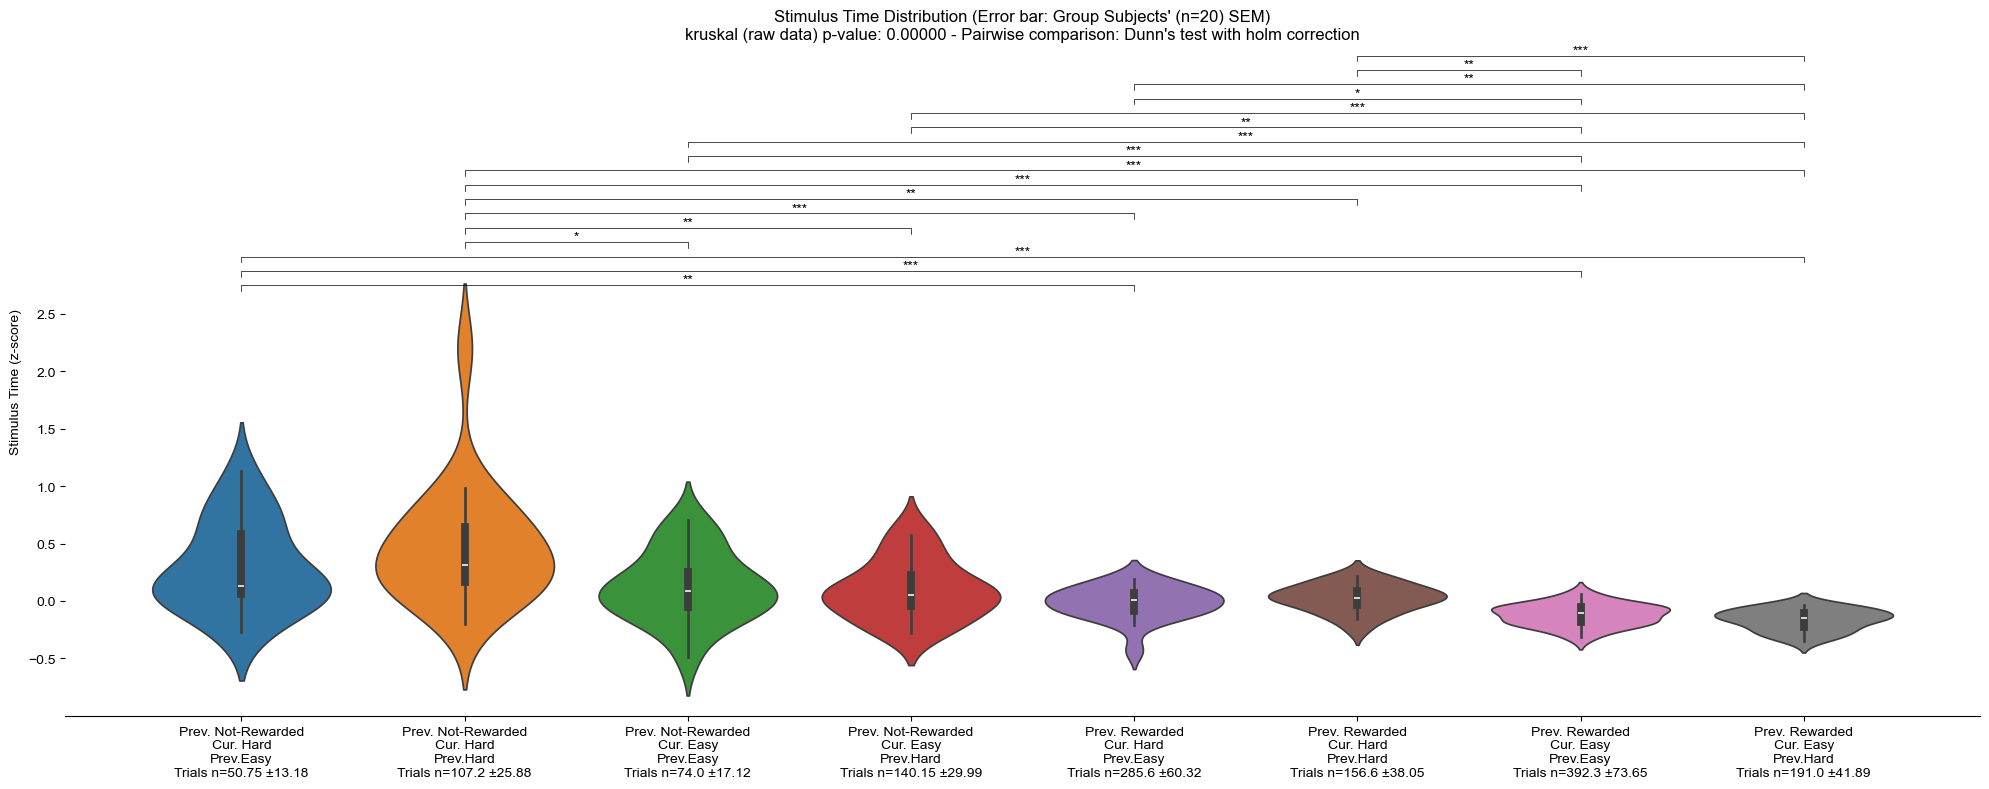

In [31]:
from .figcode.stheatmap import stHeatmap

stHeatmap(df_mice.copy(), dscrp="All Mice",
          mean_or_median="mean",
          plot_single_subjects=False,
          save_prefix=f"{save_prefix}/rt_prev_cur/",
          save_fig=global_save_figs)

## Fig 2e left

vgat2.5
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 0.9217221995926681


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


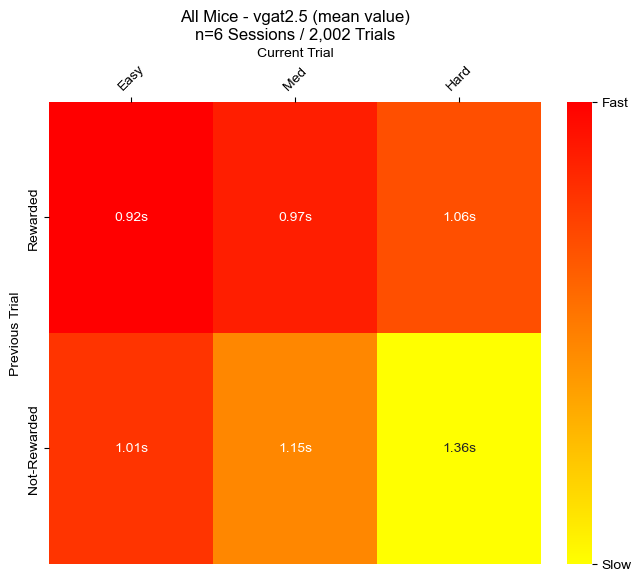

In [32]:
stHeatmap(df_mice[df_mice.Name == "vgat2.5"].copy(), dscrp="All Mice",
          mean_or_median="mean",
          plot_single_subjects=True,
          plot_combined_subjects=False,
          save_prefix=f"{save_prefix}/rt_prev_cur/",
          save_fig=global_save_figs)

## Per subject plots

Avgat1
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 0.7182625906735751


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


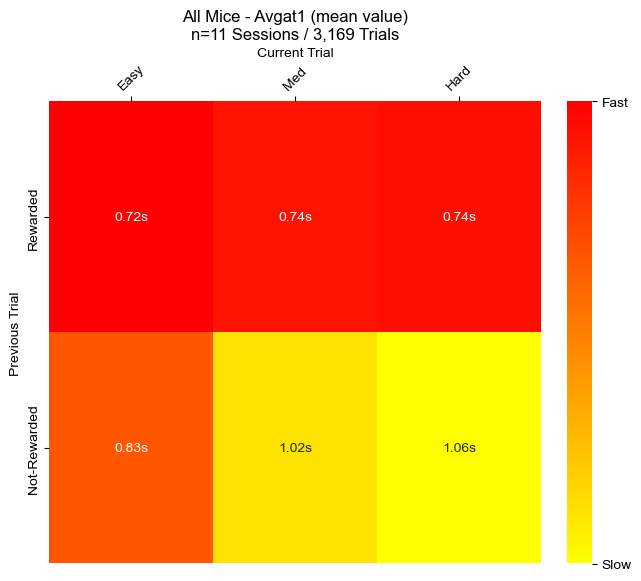

Avgat2
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 0.849068154158215


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


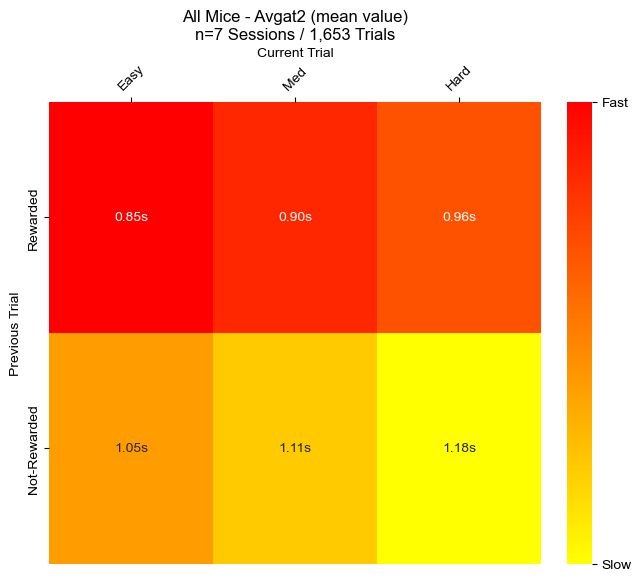

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


Avgat3
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 0.7487653259361996


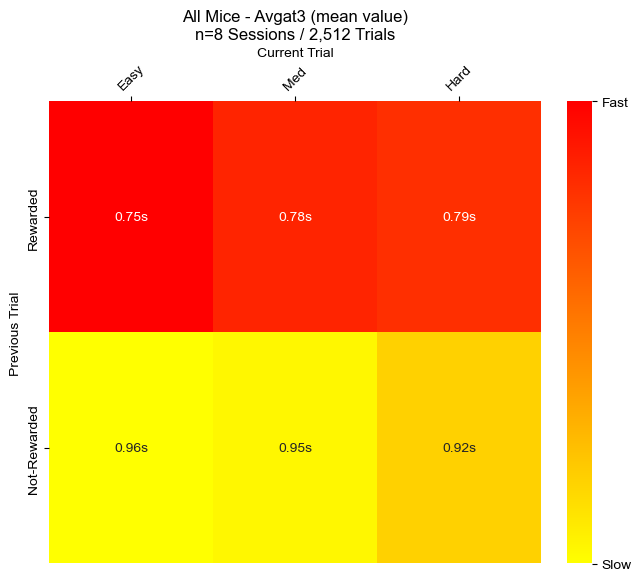

BVGAT1
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 1.0618671641791044


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


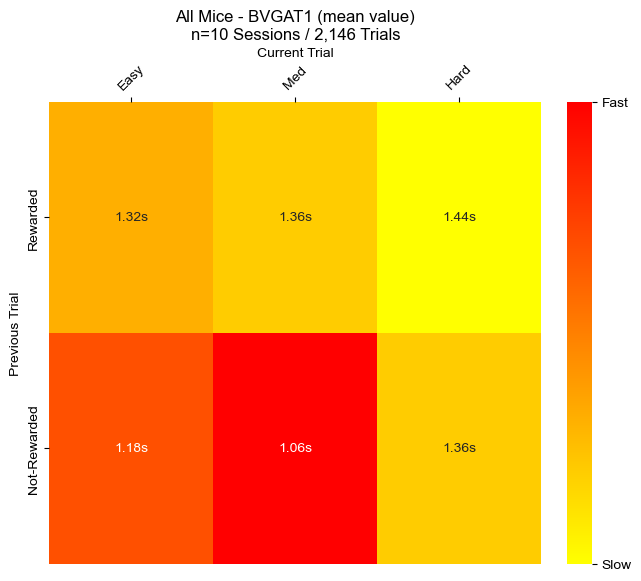

GP4-24
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 0.9389766666666667


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


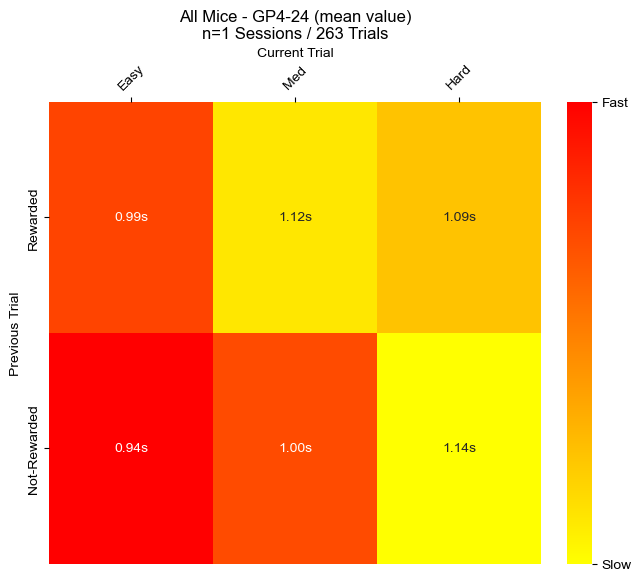

GP4-80
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 1.169485536159601


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


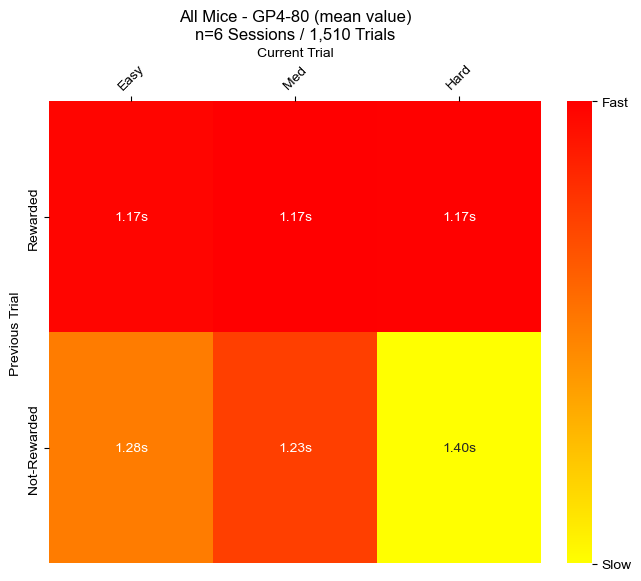

GP4-81
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 1.0657293154761907


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


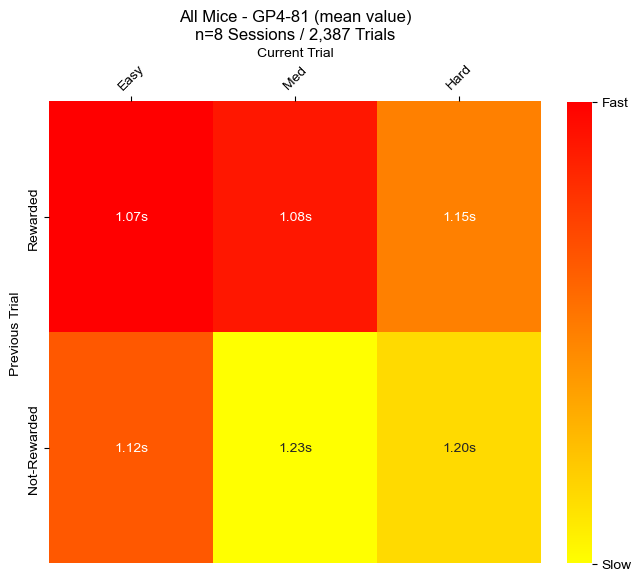

GP4-85
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 1.1531636363636364


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


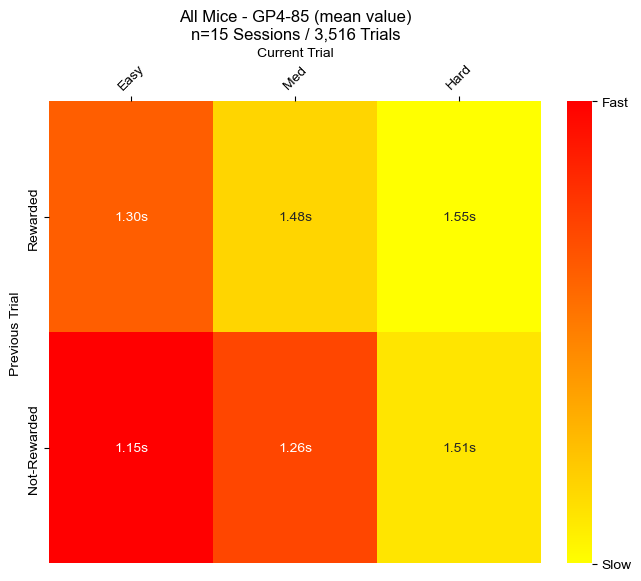

RDK_WT1
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 1.1769864598025388


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


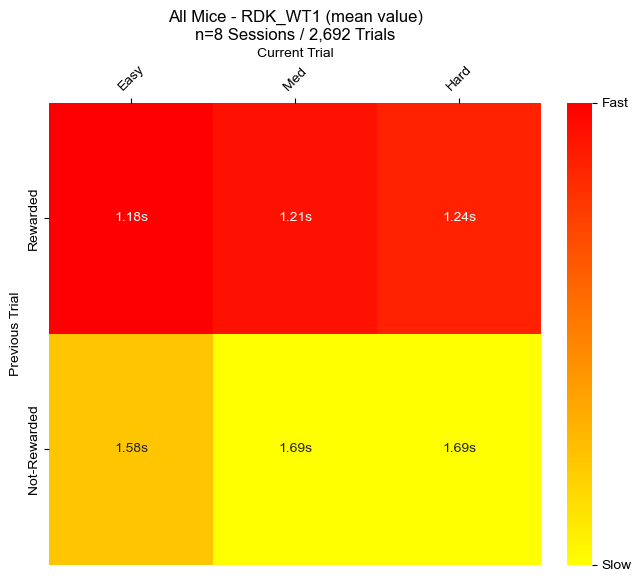

RDK_WT6
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 1.252470989010989


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


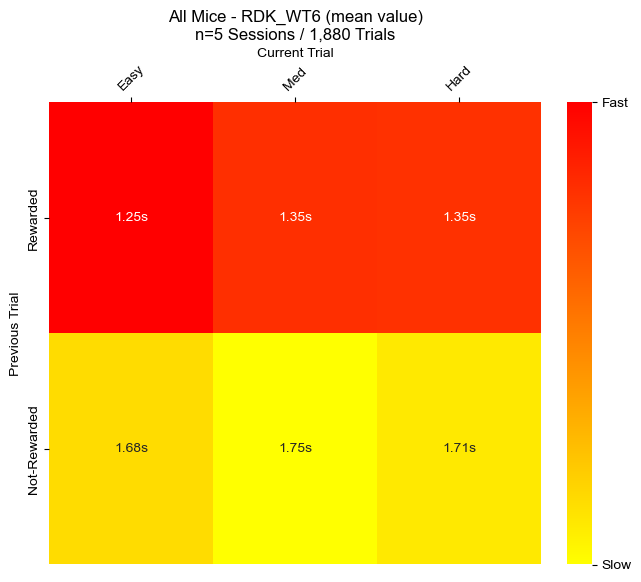

Rbp4_M2_1
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 1.0193680412371133


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


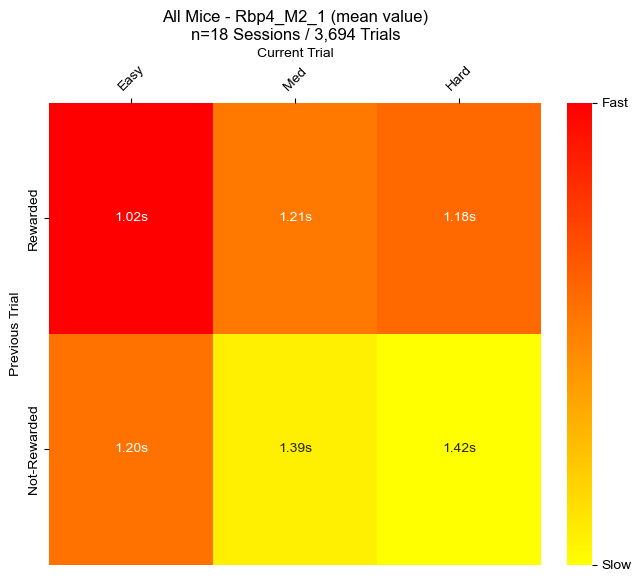

WF10
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 1.143435294117647


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


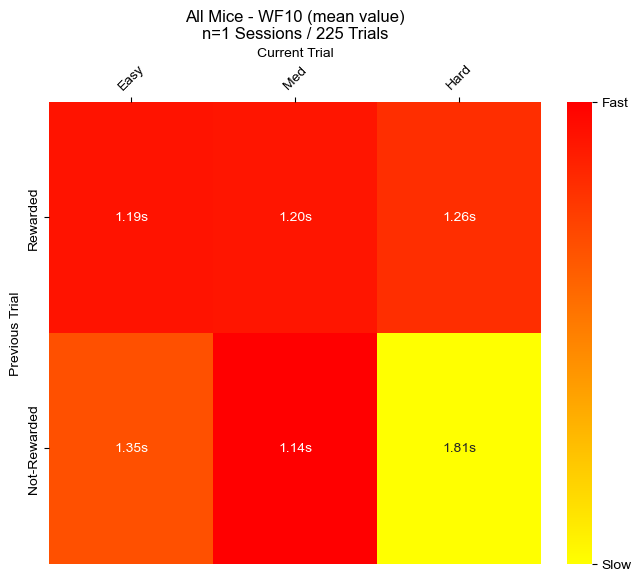

WF11
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 1.2018419902912623


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


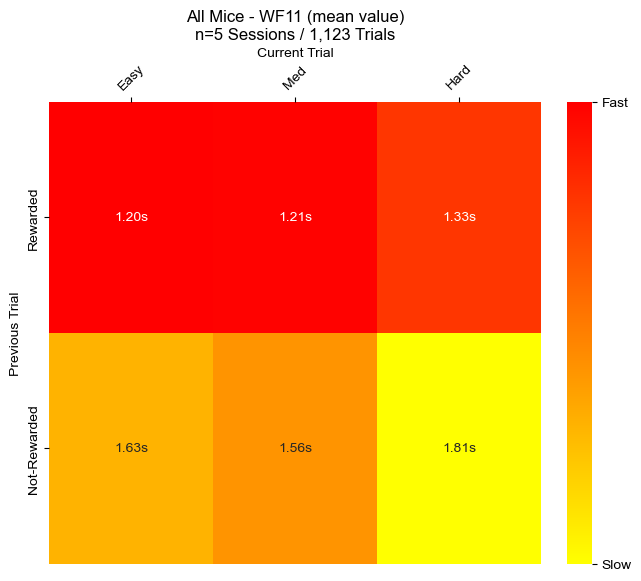

vgat-40
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 1.2174770432066633


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


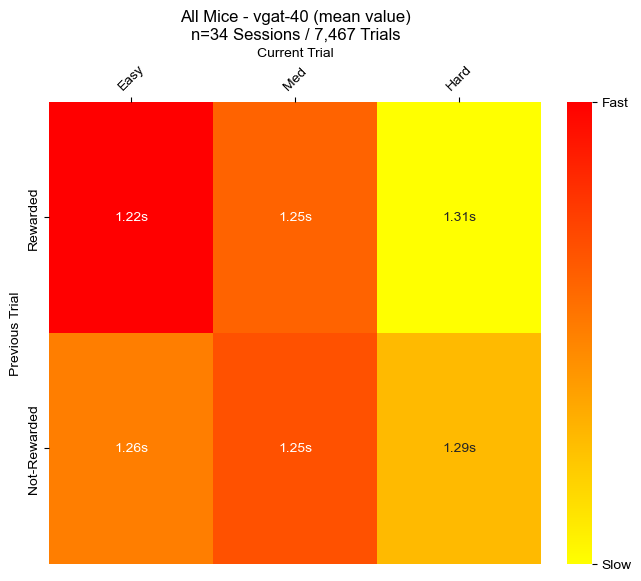

vgat-94
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 1.3420462409562754


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


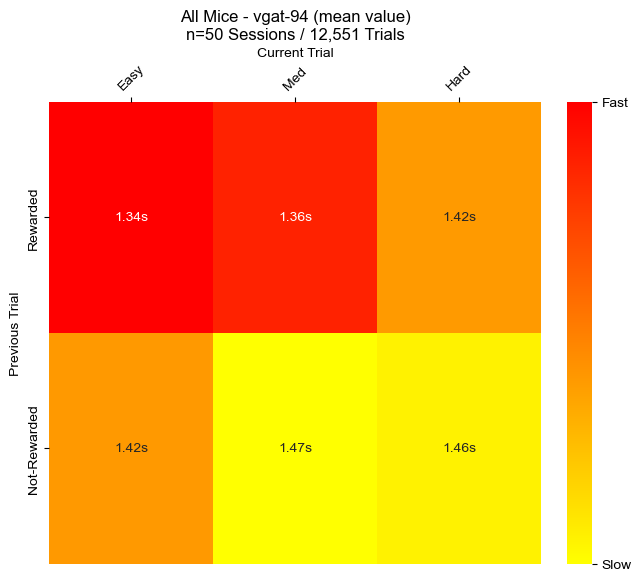

vgat-95
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 0.8361349650349651


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


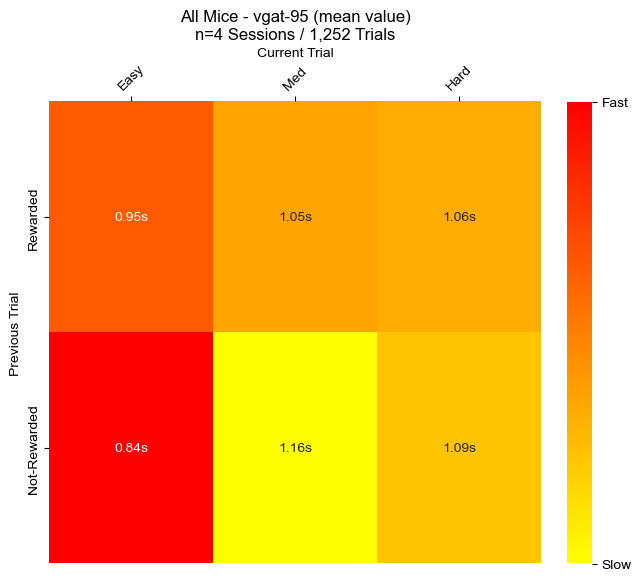

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


vgat-96
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 0.9495280429594272


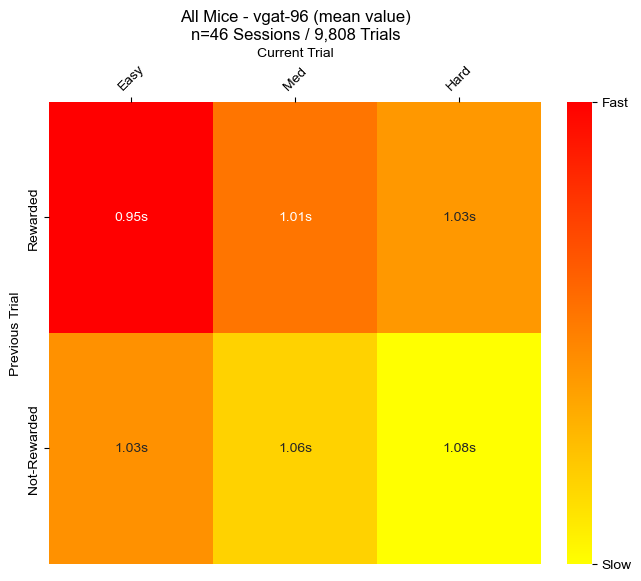

vgat2.5
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 0.9217221995926681


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


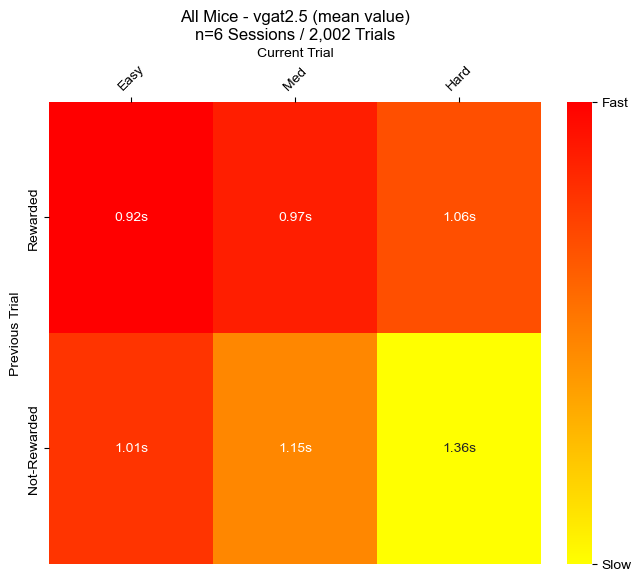

vgatchr2-sk
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 0.9412552575107297


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


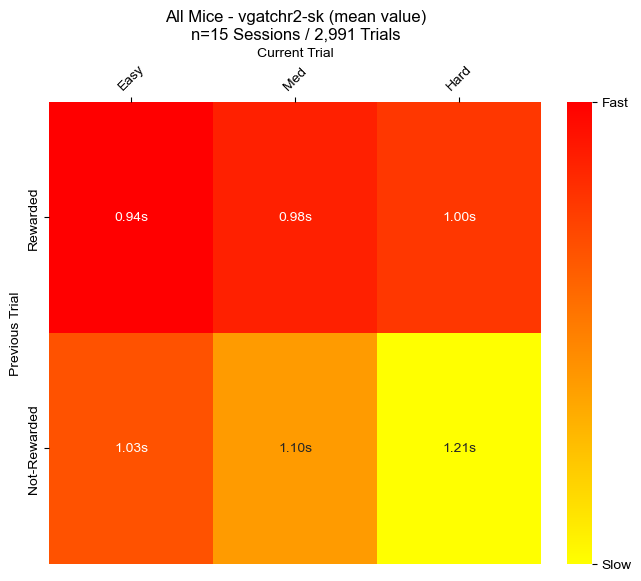

widefield_1
diff: Index(['Not-Rewarded', 'Rewarded'], dtype='object', name='PrevTrial')
cols diff: Index(['Easy', 'Hard', 'Med'], dtype='object', name='CurDifficulty')
df.min(): 0.8729522388059702


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stheatmap.py:137: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for sub_index, sub_df in  df.groupby(list(prev_trial)):


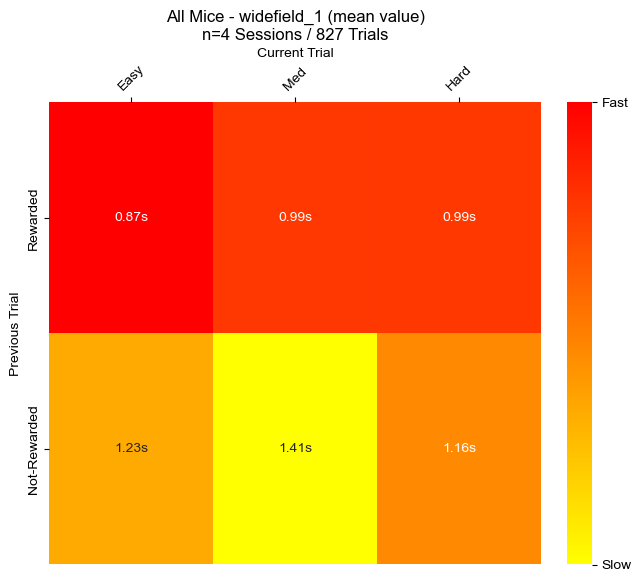

In [33]:
stHeatmap(df_mice.copy(), dscrp="All Mice",
          mean_or_median="mean",
          plot_single_subjects=True,
          plot_combined_subjects=False,
          save_prefix=f"{save_prefix}/rt_prev_cur/",
          save_fig=global_save_figs)

# Prev. Trial Effect on Current Trial

## Fig 1i-left

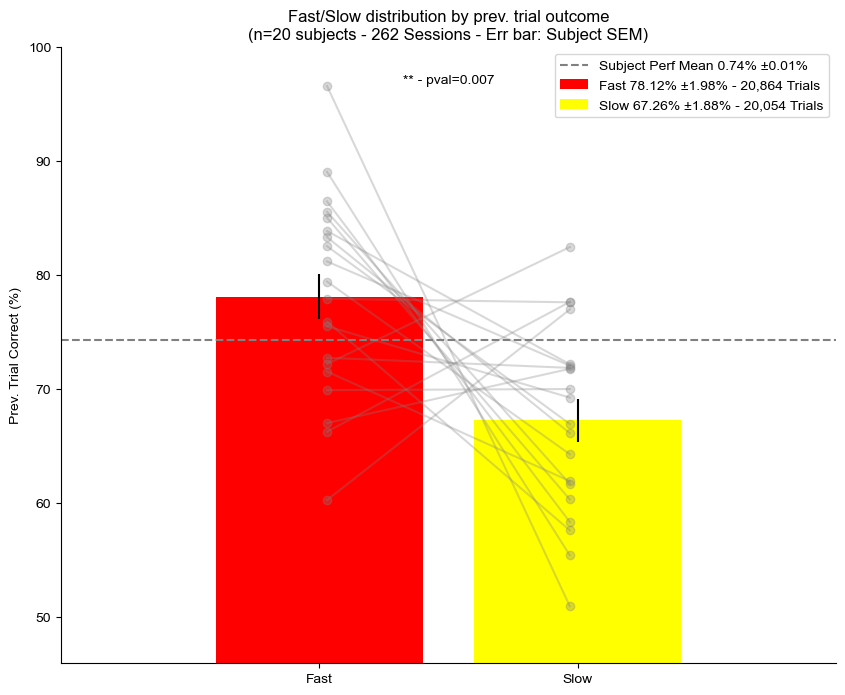

In [34]:
from .figcode.prevoutcomecurquantile import prevOutcomeCurQuantile

prevOutcomeCurQuantile(df_mice,#.groupby("Name").filter(lambda grp: len(grp) > 2_500),
                       save_prefix=save_prefix, save_fig=global_save_figs)

# Stay/Switch probability

In [35]:
from .figcode.stayswitch import staySwitchUpdate

def runStaySwitchUpdate(df, plot_single_subjects=False,
                        plot_combined_subjects=True,
                        save_fig=False, save_prefix=None):
    df = df.copy()
    df = df[df.Stay.notnull()]
    df = df.groupby("Name").filter(lambda grp: len(grp) > 2_500)
    staySwitchUpdate(df, dscrp="Mice", plot_single_subjects=plot_single_subjects,
                     plot_combined_subjects=plot_combined_subjects,
                     save_prefix=save_prefix, save_fig=save_fig)

## Ext. Fig. 3h

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])


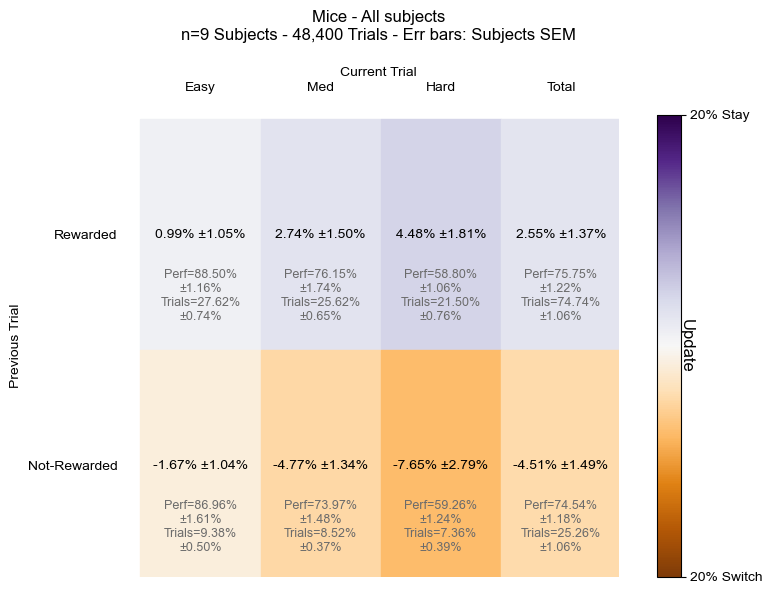

In [36]:
runStaySwitchUpdate(df_mice, plot_single_subjects=False, save_prefix=save_prefix,
                    save_fig=global_save_figs)

## Per subject plots

Subject: Avgat1 - len: 3169


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])


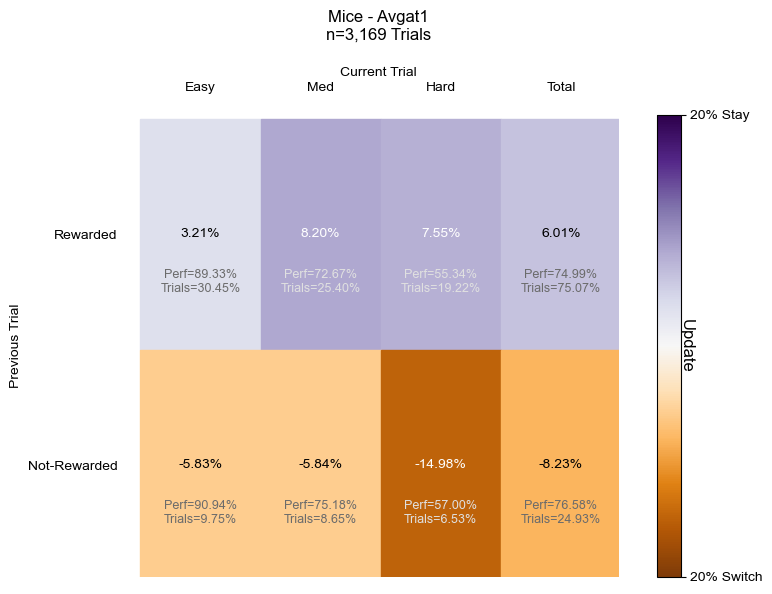

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])


Subject: Avgat3 - len: 2512


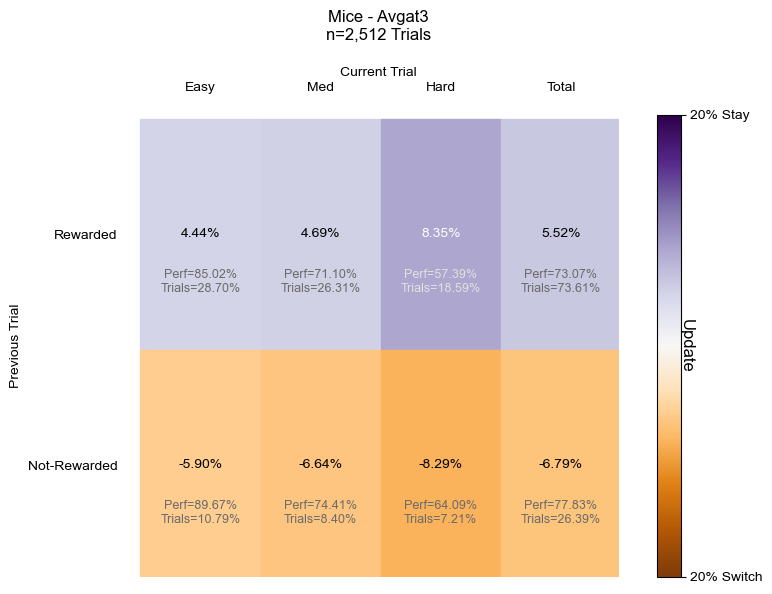

Subject: GP4-85 - len: 3516


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])


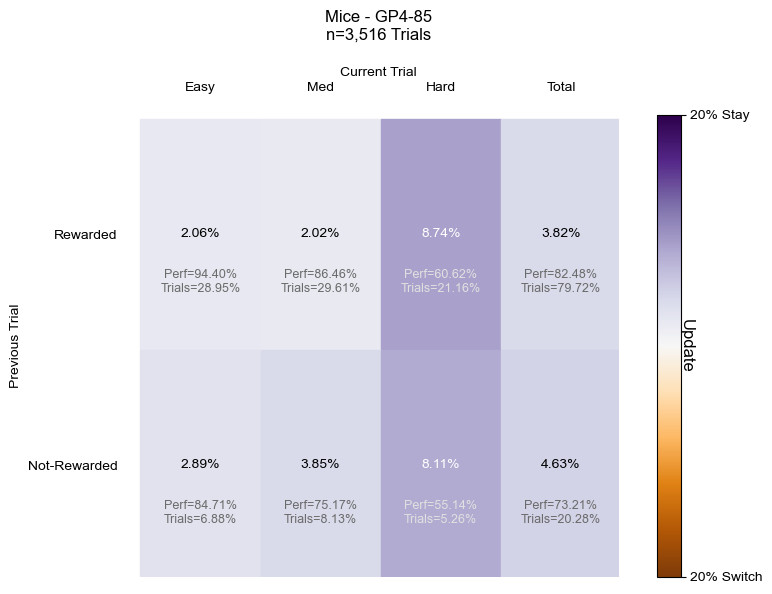

Subject: RDK_WT1 - len: 2692


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])


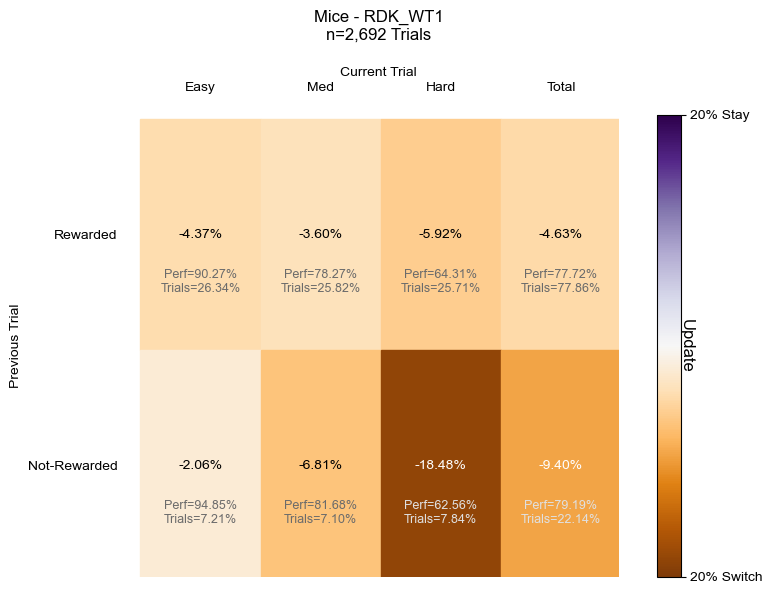

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])


Subject: Rbp4_M2_1 - len: 3694


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])


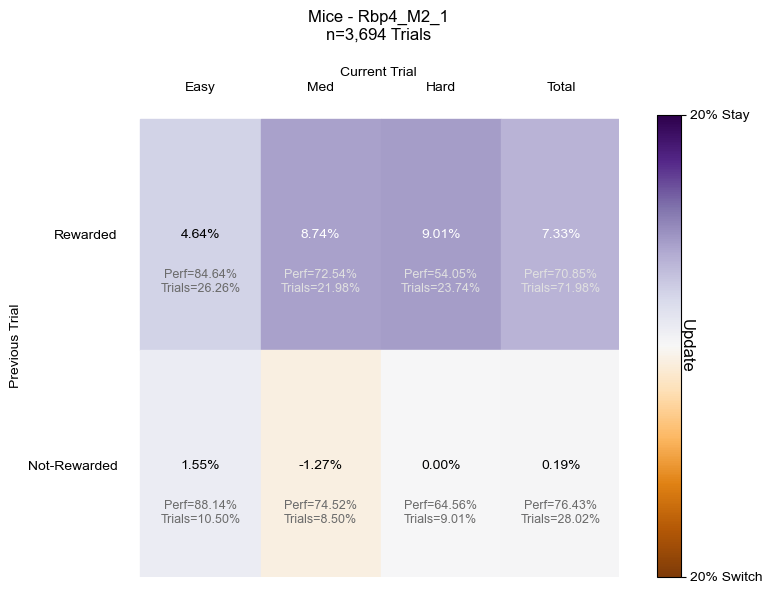

Subject: vgat-40 - len: 7467


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])


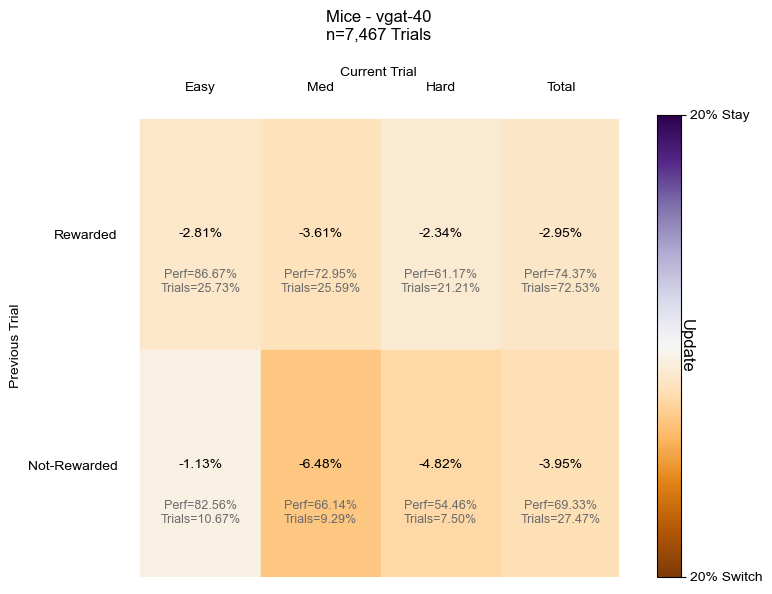

Subject: vgat-94 - len: 12551


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])


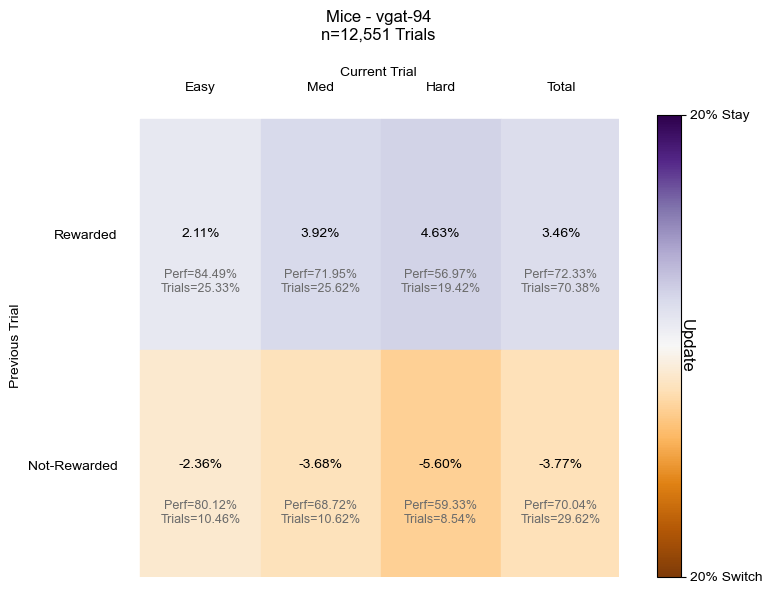

Subject: vgat-96 - len: 9808


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])


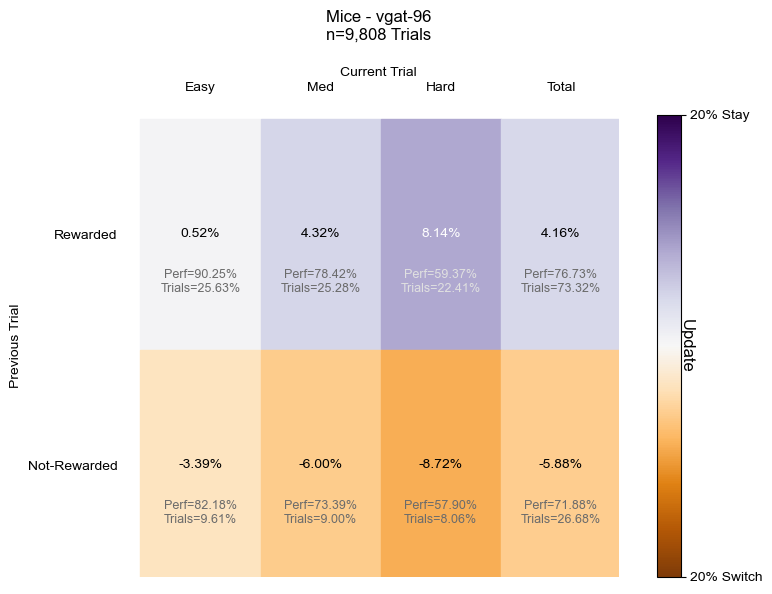

Subject: vgatchr2-sk - len: 2991


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:113: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  res_grp = pd.concat([res_grp, total_row.to_frame().T])


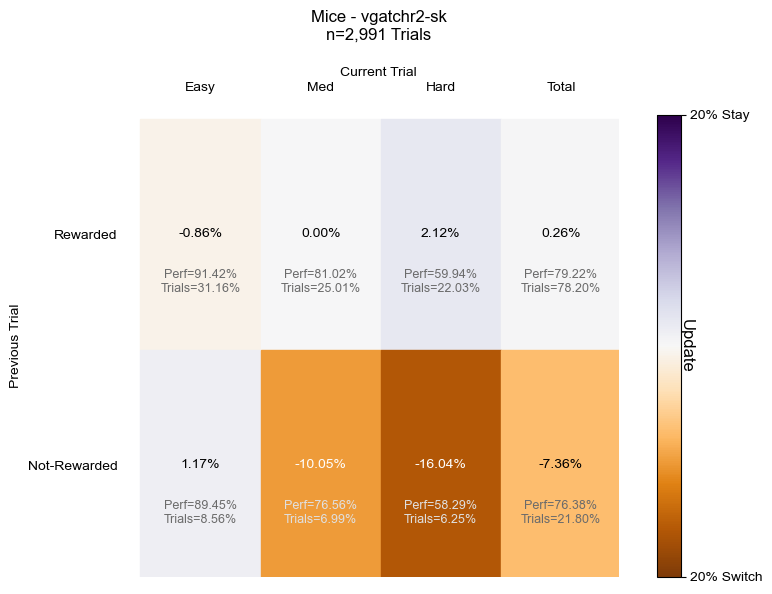

In [37]:
runStaySwitchUpdate(df_mice, plot_single_subjects=True,
                    plot_combined_subjects=False,
                    save_prefix=save_prefix,
                    save_fig=global_save_figs)

# Stay/Switch reaction time

## Fig. 1i-right

In [ ]:
from .behavior.stayswitchupdate import plotQuantileUpdate

_fig, update_result = plotQuantileUpdate(df_mice, save_prefix=save_prefix,
                                         save_figs=global_save_figs)
print(f"Paired t-test: {update_result.statistic:.2f} - "
      f"p={update_result.pvalue:.2e}")

# Stay/Switch over time

## Ext. Fig. 3g

In [ ]:
from .behavior.stayswitchupdate import (outlierSubjects,
                                        plotUpdateOverSamplingTime)

# The animals dropped here are derived from the Methods rule -- an unusually
# large fraction of trials below a sampling-time z-score of -1, above the 90th
# percentile of the group -- rather than named.
print("Excluded:", outlierSubjects(df_mice))
_ = plotUpdateOverSamplingTime(df_mice, save_prefix=save_prefix,
                               save_figs=global_save_figs)

In [ ]:
from .behavior.stayswitchupdate import plotOutlierFraction

# The justification for the exclusion above: outlier fraction per animal,
# against the 90th-percentile cut-off.
_ = plotOutlierFraction(df_mice, save_prefix=save_prefix,
                        save_figs=global_save_figs)

# Bias Calculation

# Ext. Fig. 3i

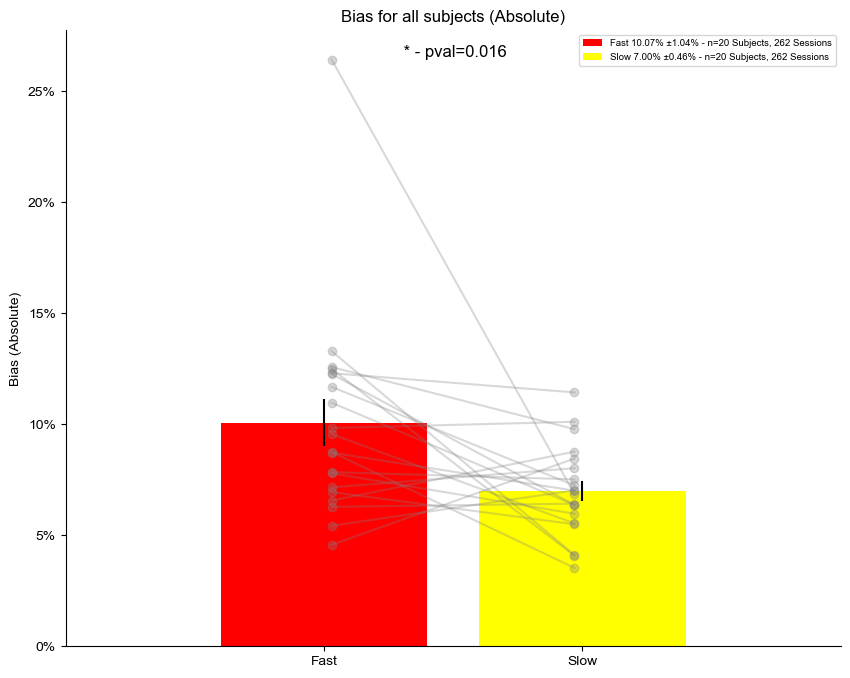

In [41]:
from .behavior.bias import plotBias

plotBias(df_mice,
         as_abs=True, plot_single_subjects=False,
         save_prefix=save_prefix, save_figs=global_save_figs)


# Reward-Rate

## Fig. 1h, Ext. Fig. 3c, d

Number of subjects with RewardRate5 == 1: 20
Group: [0.2, 0.4)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9642304182052612 Pval: 0.684852123260498 Is Normal: True
Group: [0.4, 0.6)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.8307794332504272 Pval: 0.002582033397629857 Is Normal: False
Group: [0.6, 0.8)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.89937424659729 Pval: 0.04014017805457115 Is Normal: False
Group: [0.8, 1.0)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9466878771781921 Pval: 0.31959331035614014 Is Normal: True
Group: [1.0, 1.2)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9580888748168945 Pval: 0.5064126253128052 Is Normal: True
Not all groups normal - Proceeding with Kruskal-Wallis Test
Kruskal-Wallis Test - Subject/Group: All Subjects Timeout: All Stat: 23.668095925238845 Pval: 0.0

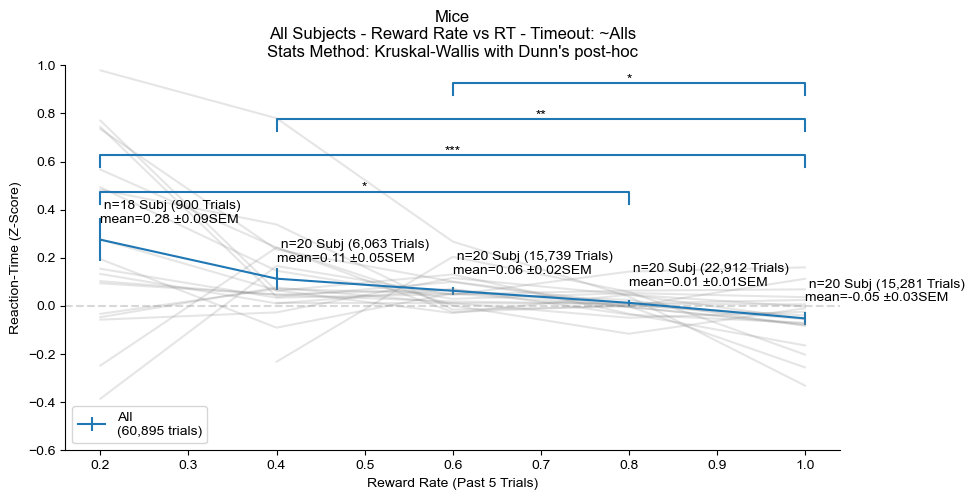

Number of subjects with RewardRate5 == 1: 18
Group: [0.2, 0.4)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9462699890136719 Pval: 0.43299269676208496 Is Normal: True
Group: [0.4, 0.6)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9132859110832214 Pval: 0.09832654148340225 Is Normal: True
Group: [0.6, 0.8)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9653952717781067 Pval: 0.7080103754997253 Is Normal: True
Group: [0.8, 1.0)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9540767669677734 Pval: 0.4924865961074829 Is Normal: True
Group: [1.0, 1.2)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9792489409446716 Pval: 0.94193035364151 Is Normal: True
All groups normal - Proceeding with ANOVA
One-Way ANOVA - Subject/Group: All Subjects Timeout: All Fstat: 5.432311869739853 Pval: 0.0006189596296279321
Signific

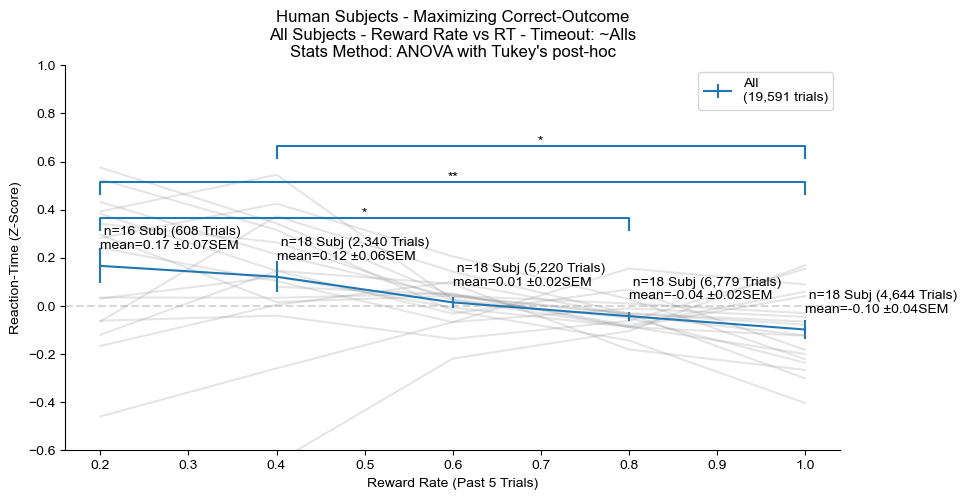

Number of subjects with RewardRate5 == 1: 18
Group: [0.4, 0.6)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.902866542339325 Pval: 0.17271806299686432 Is Normal: True
Group: [0.6, 0.8)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.971317708492279 Pval: 0.8770689964294434 Is Normal: True
Group: [0.8, 1.0)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.7936592102050781 Pval: 0.0012375732185319066 Is Normal: False
Group: [1.0, 1.2)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9181830286979675 Pval: 0.12003934383392334 Is Normal: True
Not all groups normal - Proceeding with Kruskal-Wallis Test
Kruskal-Wallis Test - Subject/Group: All Subjects Timeout: All Stat: 15.157027116402077 Pval: 0.0017
Significant differences found - Proceeding with post-hoc tests
Post-hoc Dunn's test results:
 			[0.4, 0.6)  [0.6, 0.8)  [0.8, 1.0)  [1.0, 1.2)
[0.4, 0.6)

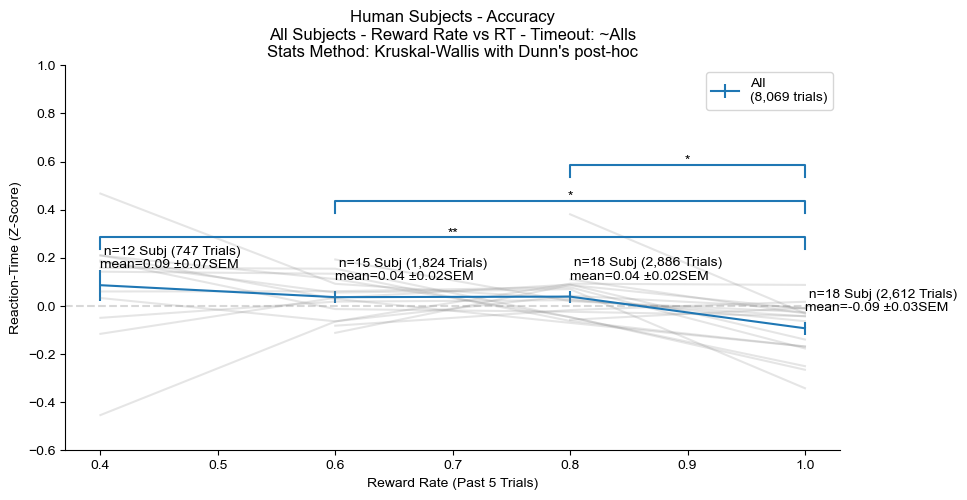

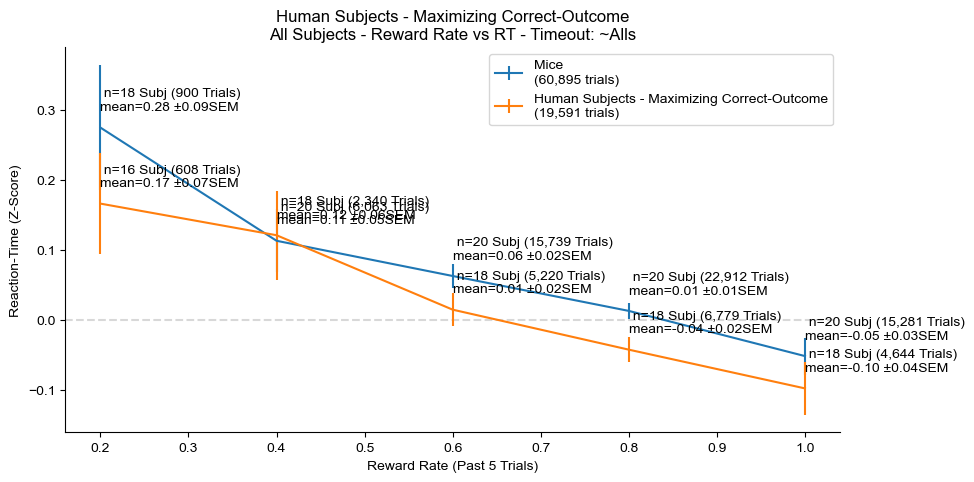

In [42]:
from .behavior.rewardrate import calcAvgRewardRate, loopRewardRateAnalysis

def plotRewardRate(df, min_num_trials, plot_subjects, title, save_figs,
                   save_prefix, plot_singles_on_all=True, ax=None,
                   ax_all_used_timeout_time=None):
    df = df.copy()
    df["SessId"] = df.Name + "_" + df.Date.astype(str) + "_" + df.SessionNum.astype(str)
    if ax is None:
        ax_was_none = True
        fig, ax = plt.subplots(1, 1, figsize=(10, 5))
        ax.axhline(0, color="gray", linestyle="--", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
        ax.set_ylim(bottom=-0.6, top=1.)
        ax_all_used_timeout_time = "All"
    else:
        ax_was_none = False
    loopRewardRateAnalysis(df, min_num_trials=min_num_trials,
                           plot_subjects=plot_subjects, descrp=title,
                           plot_singles_on_all=plot_singles_on_all,
                           save_figs=save_figs, save_prefix=save_prefix,
                           ax_all=ax,
                        #    min_trials_per_sess_rr=10,
                           ax_all_used_timeout_time=ax_all_used_timeout_time)
    if ax_was_none:
        ax.legend()
        plt.show()

def loopRewardRate(df_mice, humans_accuracy_df, humans_max_outcome_df,
                   plot_subjects, save_figs, save_prefix):
    df_mice = df_mice.copy()
    df_mice = df_mice.sort_values(by=["Name", "Date", "SessionNum", "TrialNumber"])
    df_mice = calcAvgRewardRate(df_mice)
    df_mice = df_mice.groupby(["Name", "Date", "SessionNum"]).filter(lambda sess_df: sess_df.DV.isnull().sum() == 0)

    humans_accuracy_df = humans_accuracy_df.copy()

    humans_accuracy_df = humans_accuracy_df.sort_values(by=["Name", "Date", "SessionNum", "TrialNumber"])
    humans_accuracy_df = calcAvgRewardRate(humans_accuracy_df)
    # Users timeout field is missing. Users had no timeout so assign 0.
    humans_accuracy_df["GUI_TimeOutIncorrectChoice"] = 0
    # Repeat for max outcome humans
    humans_max_outcome_df = humans_max_outcome_df.copy()
    humans_max_outcome_df = humans_max_outcome_df.sort_values(by=["Name", "Date", "SessionNum", "TrialNumber"])
    humans_max_outcome_df = calcAvgRewardRate(humans_max_outcome_df)
    humans_max_outcome_df["GUI_TimeOutIncorrectChoice"] = 0


    COL = "RewardRate5"
    DEFAULT_MIN_NUM_TRIALS = 0
    DEFAULT_ACCURACY_MIN_NUM_TRIALS = 0 # They have less trials compared to speed task and mice

    for df, title in [(df_mice, "Mice"),
                      (humans_max_outcome_df, "Human Subjects - Maximizing Correct-Outcome"),
                      (humans_accuracy_df, "Human Subjects - Accuracy"),
                     ]:
        # df = df[df[COL] != 0] # We have very few points
        num_subjects_in_1st = df[df[COL] == 1].Name.nunique()
        print(f"Number of subjects with {COL} == 1: {num_subjects_in_1st}")
        df = df.groupby(COL).filter(lambda rr_df: rr_df.Name.nunique() >= .75 * num_subjects_in_1st)
        num_rr_bins = len(df[COL].unique())
        # Filter out subjects that do not have all reward-rates bins
        # df = df.groupby("Name").filter(lambda subj_df: subj_df[COL].nunique() == num_rr_bins)
        min_num_trials = DEFAULT_MIN_NUM_TRIALS if "Accuracy" not in title else DEFAULT_ACCURACY_MIN_NUM_TRIALS
        plotRewardRate(df, min_num_trials=min_num_trials,
                       plot_subjects=plot_subjects, title=title,
                       save_figs=save_figs, save_prefix=save_prefix)


    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.axhline(0, color="gray", linestyle="--", alpha=0.3)
    for df, title in [(df_mice, "Mice"),
                           (humans_max_outcome_df, "Human Subjects - Maximizing Correct-Outcome"),
                          #   (humans_accuracy_df, "Human Subjects - Accuracy"),
                      ]:
        # df = df[df[COL] != 0] # We have very few points
        num_subjects_in_1st = df[df[COL] == 1].Name.nunique()
        # print(f"Number of subjects with {COL} == 1: {num_subjects_in_1st}")
        df = df.groupby(COL).filter(lambda rr_df: rr_df.Name.nunique() >= .75 * num_subjects_in_1st)
        # display(df.groupby(COL).Name.nunique())
        # print(f"Remaining reward-rates: ", df[COL].unique())
        # return
        min_num_trials = DEFAULT_MIN_NUM_TRIALS if "Accuracy" not in title else DEFAULT_ACCURACY_MIN_NUM_TRIALS
        plotRewardRate(df, min_num_trials=min_num_trials,
                       plot_subjects=False, title=title,
                       ax=ax, ax_all_used_timeout_time="All",
                       plot_singles_on_all=False,
                       save_figs=global_save_figs, save_prefix=None)
    ax.legend()
    if save_figs:
        plt.savefig(f"{save_prefix}/reward_rate5.svg", bbox_inches="tight")
    plt.show()

loopRewardRate(df_mice=df_mice, humans_accuracy_df=humans_accuracy_df,
               humans_max_outcome_df=humans_max_outcome_df, plot_subjects=False,
               save_prefix=save_prefix, save_figs=global_save_figs)

# Behavior Parameters Variance Explained

In [ ]:
from .behavior.varexplained import (loopSubjects, plotVarianceExplained,
                                    totalVarianceExplained)

var_exp_df = loopSubjects(df_mice)
print(f"Total variance explained: {totalVarianceExplained(var_exp_df):.1f}%")
print(f"Condition numbers: {var_exp_df.cond_no.min():.1f}"
      f"-{var_exp_df.cond_no.max():.1f}")
var_exp_df

## Fig. 2A

In [ ]:
_ = plotVarianceExplained(var_exp_df, save_prefix=save_prefix,
                          save_figs=global_save_figs)

# Fast/Slow Psychometric

## Fig. 1e


Fast vs Slow per-dv paired tests (Holm-FWER corrected):
  dv=0.10000000000000009: t=-1.6224, p=0.1287, p_holm=0.1287, reject=False
  dv=0.21367895514681806: t=-5.2070, p=0.0002194, p_holm=0.0006581, reject=True
  dv=0.5278008899038497: t=-3.7590, p=0.001328, p_holm=0.002657, reject=True
  dv=0.9942647173059079: t=-4.7473, p=0.0001402, p_holm=0.0005606, reject=True


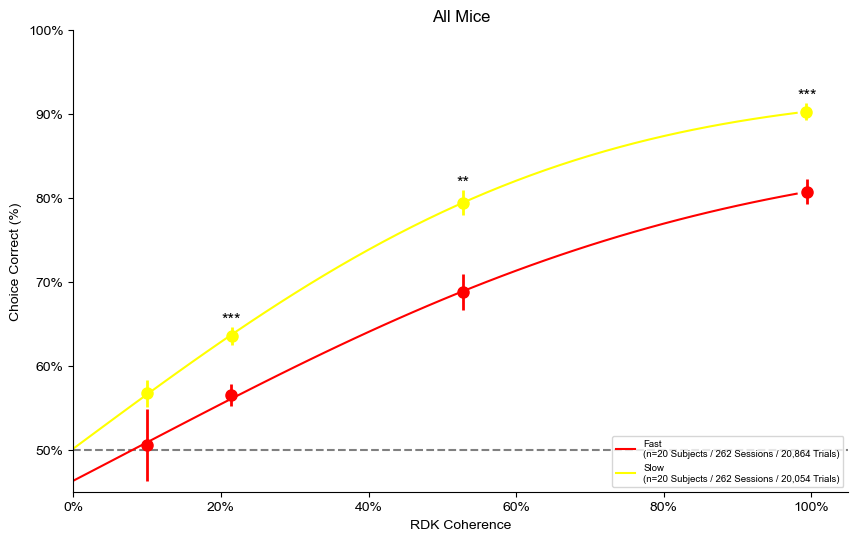

In [45]:
from .figcode.psychometric import slowFastPsych

slowFastPsych(df=df_mice, is_human_subject=False,
              combine_sides=True, plot_typical=False, save_fp=f"{save_prefix}/psych_mice/",
              plot_single_subjects=False, subject_plot_points=False,
              save_figs=global_save_figs)


## Ext. Fig f

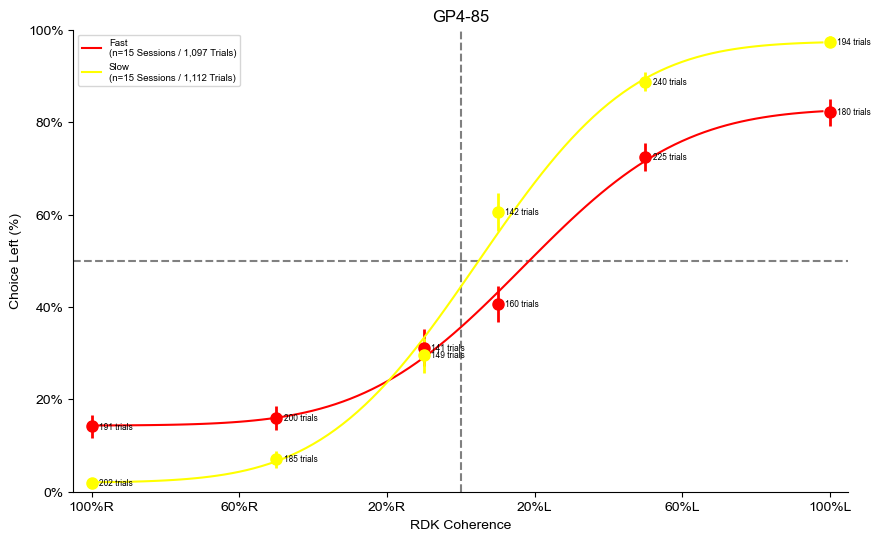

In [46]:
from .figcode.psychometric import slowFastPsych

slowFastPsych(df=df_mice[df_mice.Name == "GP4-85"], is_human_subject=False,
              combine_sides=False, plot_typical=False, save_fp=f"{save_prefix}/psych_mice/",
              plot_single_subjects=True, plot_combined_subjects=False,
              subject_plot_points=True, save_figs=global_save_figs)


## For humans

## Fig. 1f


Fast vs Slow per-dv paired tests (Holm-FWER corrected):
  dv=0.01: t=-0.3049, p=0.7642, p_holm=1, reject=False
  dv=0.032678697893234396: t=0.9574, p=0.3518, p_holm=1, reject=False
  dv=0.0785595492916538: t=0.8276, p=0.4194, p_holm=1, reject=False
  dv=0.1389577439762197: t=0.1518, p=0.8811, p_holm=1, reject=False
  dv=0.3297246590087789: t=-3.6997, p=0.001779, p_holm=0.01067, reject=True
  dv=0.7518866040245903: t=-3.6090, p=0.002166, p_holm=0.01083, reject=True


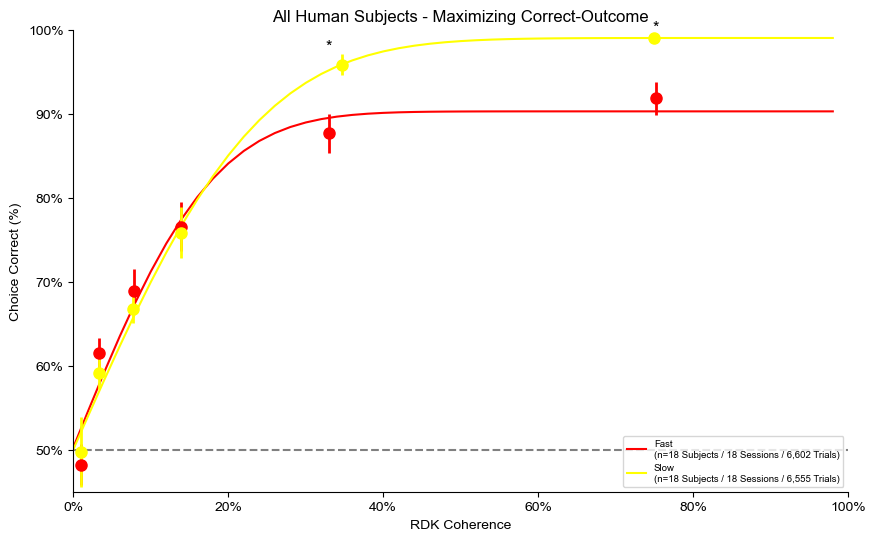

In [47]:
slowFastPsych(humans_max_outcome_df, is_human_subject=True, title_suffix="Maximizing Correct-Outcome",
              combine_sides=True, plot_typical=False,
              plot_single_subjects=False, subject_plot_points=False,
              save_fp=f"{save_prefix}/psych_human/Maximizing Correct-Outcome_",
              save_figs=global_save_figs)

## Ext. Fig. 3i

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2



Fast vs Slow per-dv paired tests (Holm-FWER corrected):
  dv=0.010000000000000002: t=1.5408, p=0.1619, p_holm=0.4858, reject=False
  dv=0.03238064537336668: t=2.9879, p=0.01525, p_holm=0.06101, reject=False
  dv=0.0779480056664964: t=3.6170, p=0.002802, p_holm=0.01681, reject=True
  dv=0.13942884245111212: t=3.1696, p=0.006347, p_holm=0.03174, reject=True
  dv=0.3200809658396029: t=0.0984, p=0.9228, p_holm=0.9228, reject=False
  dv=0.7679856479627012: t=1.3597, p=0.1928, p_holm=0.4858, reject=False


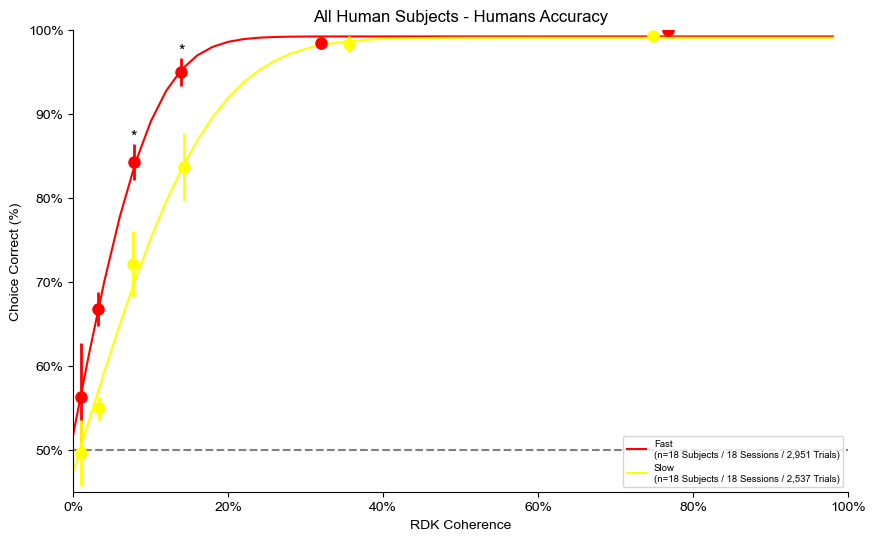

In [48]:
slowFastPsych(humans_accuracy_df, is_human_subject=True, title_suffix="Humans Accuracy",
              combine_sides=True, plot_typical=False,
              plot_single_subjects=False, subject_plot_points=False,
              save_fp=f"{save_prefix}/psych_human/Humans Accuracy",
              save_figs=global_save_figs)

# Chronometry

## Ext. Fig. 1c-right

Subject: All Animals
Min sampling points: [0.3, 0.6, 0.8999999999999999, 1.0, 1.2, 1.5]


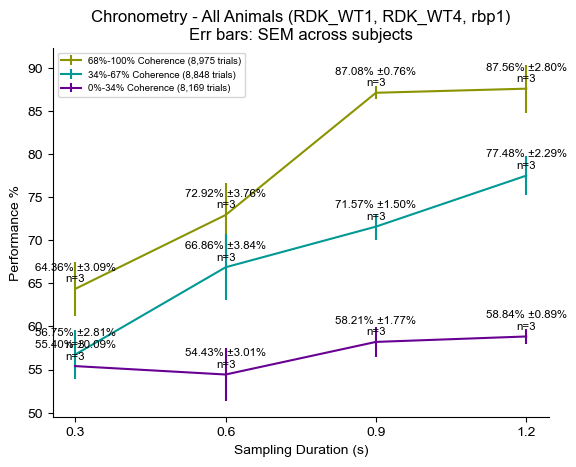

In [49]:
from .behavior.chronometry import chronometry, Plots, GroupBy
from .common.definitions import ExpType

def runChrono(df, save_prefix, save_figs):
    df = df[df.ChoiceCorrect.notnull()]
    df = df.groupby("Name").filter(lambda grp: len(grp) > 2_500)
    chronometry(df,#.query("Name == 'RDK_WT4'"),
                plots=Plots.Chronometry,# | Plots.ChronoPsych,
                plot_all_animals=True, plot_single_animals=False,
                min_easiest_perf=75, min_num_sampling_pts=3,
                # Try without fixed points and you'll get the same
                # results but with extra points in the middle
                min_sampling_pts=[0.3, 0.6, 0.9, 1.2],
                save_figs=save_figs,
                exp_type=ExpType.RDK, grpby=GroupBy.Difficulty,
                save_prefix=save_prefix)

runChrono(df_chrono, save_prefix, save_figs=global_save_figs)

# DV_str distribution

100.0    95.030038
90.0      2.978616
70.0      1.554426
80.0      0.436920
Name: DV, dtype: float64

50.0    63.450775
60.0    31.814845
40.0     4.124232
Name: DV, dtype: float64

20.0    46.925584
10.0    43.318049
30.0     8.789570
0.0      0.966797
Name: DV, dtype: float64

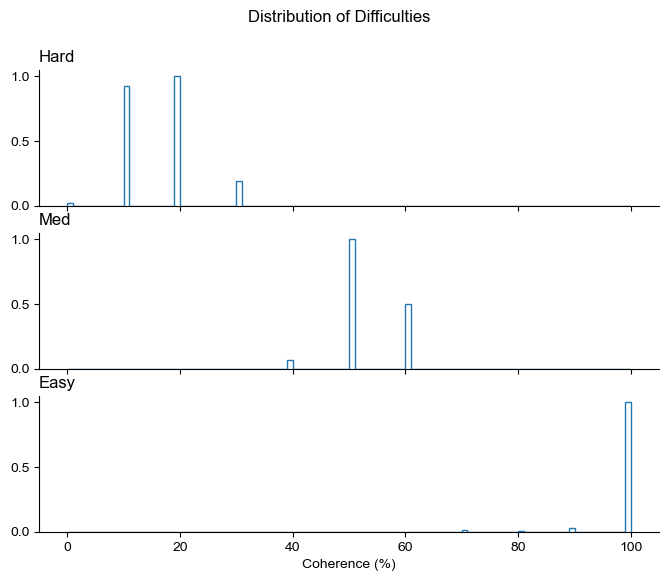

In [50]:
def plotDVstrDist(df, save_figs=global_save_figs):
    fig, axs = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
    fig.suptitle("Distribution of Difficulties")
    axs = axs[::-1]
    for y_idx, dv_str in enumerate(["Easy", "Med", "Hard"]):
        dv_str_cohr = df[df.DVstr == dv_str].DV.abs()*100
        # display(dv_str_dv.describe())
        ax = axs[y_idx]
        # Make a violin plot
        rng = np.arange(0, 101, 1)
        vals, edges = np.histogram(dv_str_cohr, bins=rng)
        vals = vals.astype(float)/vals.max()
        ax.stairs(vals, edges, label=f"n={len(dv_str_cohr):,}")
        ax.set_title(dv_str, loc="left")
        if y_idx == 0:
            ax.set_xlabel("Coherence (%)")
        # print(f"{dv_str} Coherence Distribution (%):")
        display(dv_str_cohr.value_counts()*100/len(dv_str_cohr))
    for ax in axs:
        # ax.set_yticks([0, 1, 2])
        # ax.set_yticklabels(["Easy", "Med", "Hard"])
        ax.spines[["top", "right"]].set_visible(False)
    if save_figs:
        fig.savefig(f"{save_prefix}/dvstr_distribution.svg",
                    bbox_inches="tight")
    plt.show()

plotDVstrDist(df_mice, save_figs=global_save_figs)

In [51]:
_grps = df_mice.groupby(["Name", "Date"]) # we never collect more than one session per day, it mainly if MATLAB crashes
print("Mean group size:", _grps.size().mean(), "- Std:", _grps.size().sem())
print("Mean group min:", _grps.size().min(), "- Max:", _grps.size().max())
print("group .1 quantile:", _grps.size().quantile(0.1), "- .9 quantile:", _grps.size().quantile(0.9))

Mean group size: 247.86770428015564 - Std: 4.593192864295767
Mean group min: 33 - Max: 485
group .1 quantile: 167.2 - .9 quantile: 344.4


In [52]:
100*df_mice.GUI_TimeOutIncorrectChoice.value_counts()/len(df_mice)

4.0    54.252614
0.0    22.644501
5.0    15.550532
2.0     6.583781
3.0     0.759788
1.0     0.199366
6.0     0.009419
Name: GUI_TimeOutIncorrectChoice, dtype: float64

# Freely moving mice behavior

In [15]:
# from ...behavior.definitions import MouseState, ExperimentType

import numpy as np
from enum import Enum, IntEnum
class _EnumShortStrMixin:
  def __str__(self):
    return self.name

  def __format__(self, fmt):
    return self.__str__()

class FloatEnumShortStr(_EnumShortStrMixin, float, Enum):
  pass

class IntEnumShortStr(_EnumShortStrMixin, IntEnum):
  pass

class ExperimentType(IntEnumShortStr):
  Auditory = 1
  LightIntensity = 2
  GratingOrientation = 3
  RDK = 4
  SoundIntensity = 5
  NoStimulus = 6

class MouseState(FloatEnumShortStr):
  Unknown = np.nan
  FreelyMoving = 1
  HeadFixed = 2
class StimAfterPokeOut(IntEnumShortStr):
  NotUsed = 0
  UntilFeedbackStart = 1
  UntilFeedbackEnd = 2
  UntilEndOfTrial = 3
  NotUsedMatlab = 4

class MinSamplingType(FloatEnumShortStr):
  Unknown = np.nan
  FixMin = 1
  AutoIncr = 2
  RandBetMinMax_DefIsMax = 3
  RandNumIntervalsMinMax_DefIsMax = 4



## Ext. Fig. 1d-right

LightIntensityFreelyMoving
LightIntensityHeadFixed
RDKHeadFixed


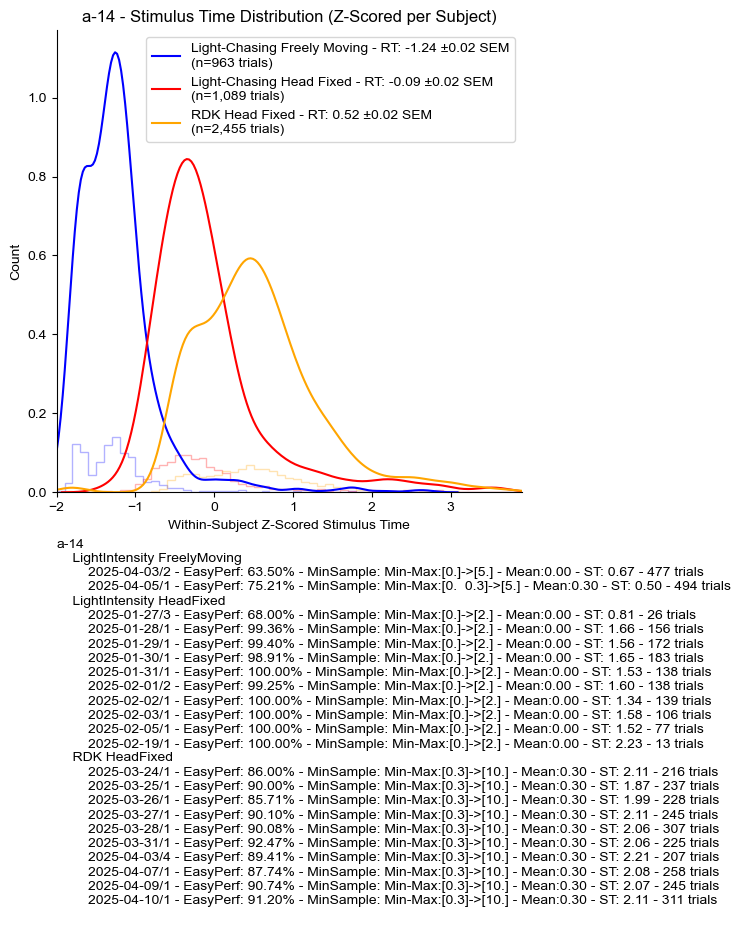

In [ ]:
from .behavior.stkde import plotFMHFSubjects

# One stimulus-time figure per accepted freely-moving / head-fixed mouse: a
# faint normalized histogram plus a KDE per experiment-type x mouse-state
# group. The session-collection pass (RDK easy-performance filter, 4.9s cap,
# last 10 sessions, subject acceptance) lives in behavior/stkde.py.
# ZSCORE_FMHF False -> raw seconds. True -> all of that mouse's plotted groups
# are pooled and z-scored together, saved as *_zscored.svg.
ZSCORE_FMHF = True

_ = plotFMHFSubjects(lc_hf_combined_df[lc_hf_combined_df.Name == "a-14"],
                     min_sess_per_state=1, zscore=ZSCORE_FMHF,
                     save_prefix=save_prefix, save_figs=global_save_figs)

## Per human-subject sampling time (seconds)

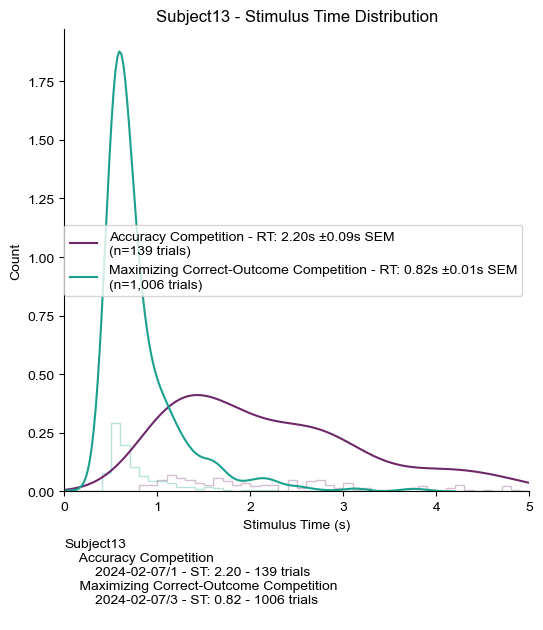

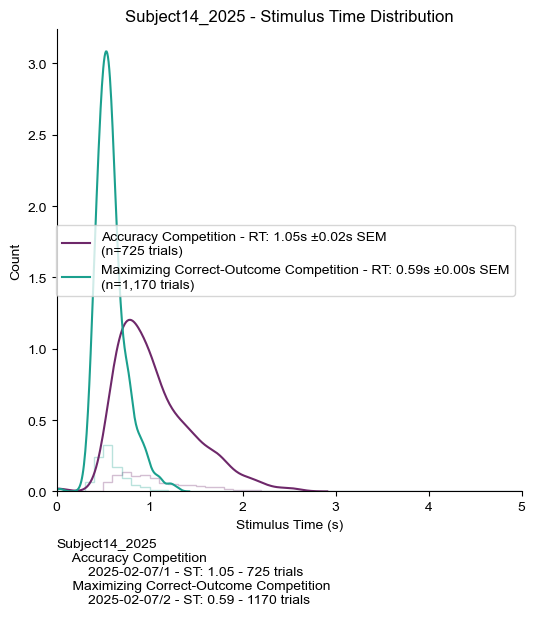

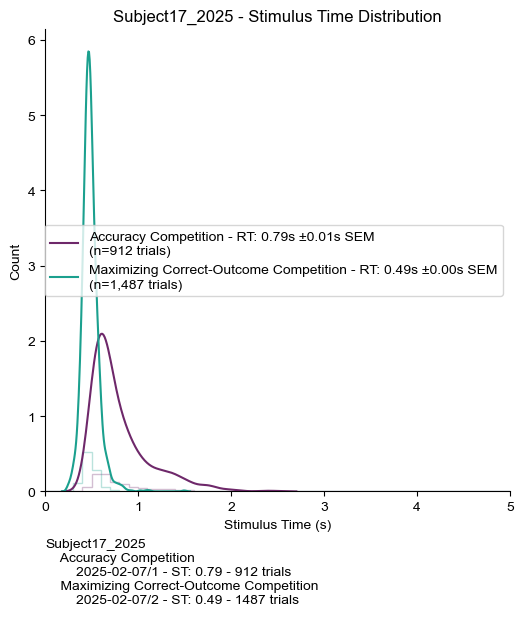

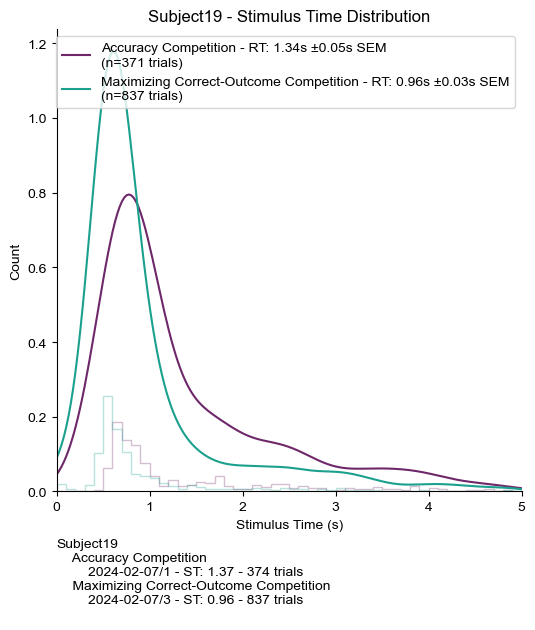

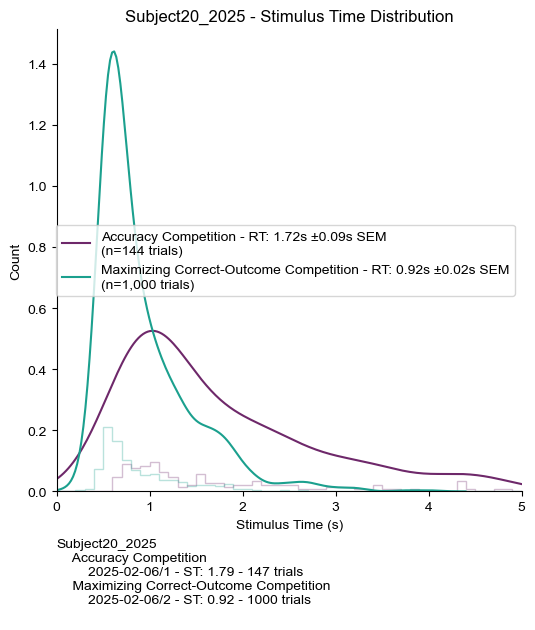

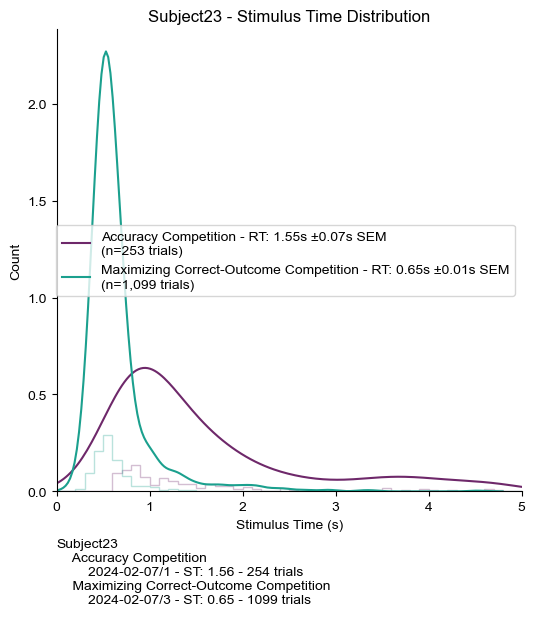

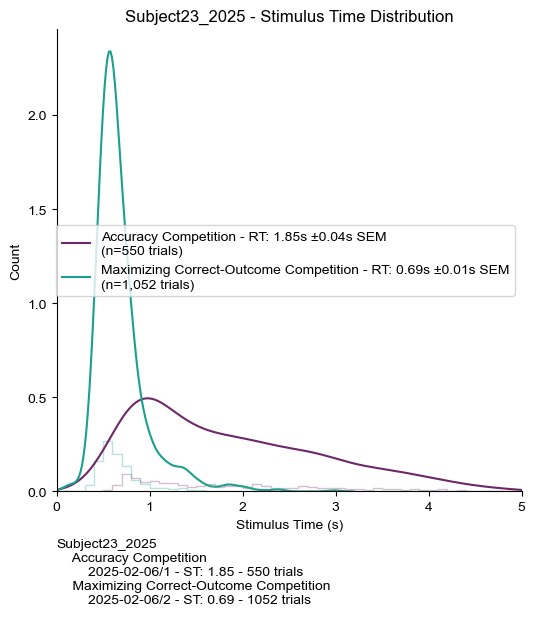

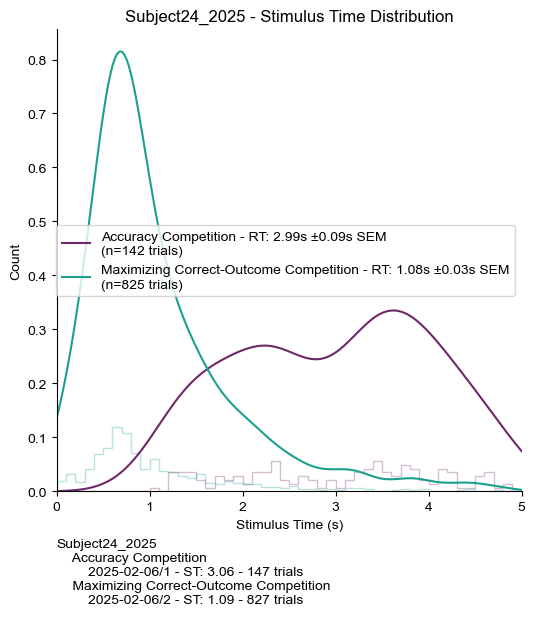

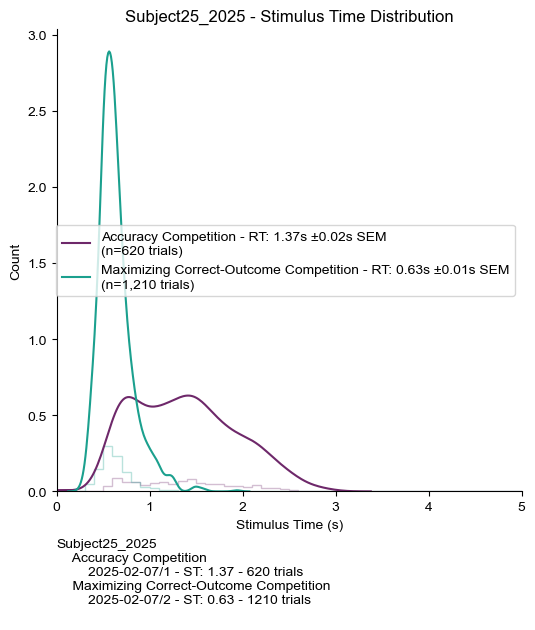

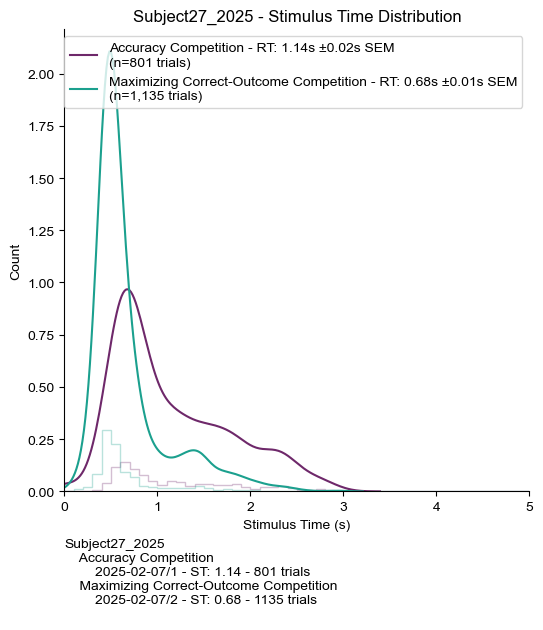

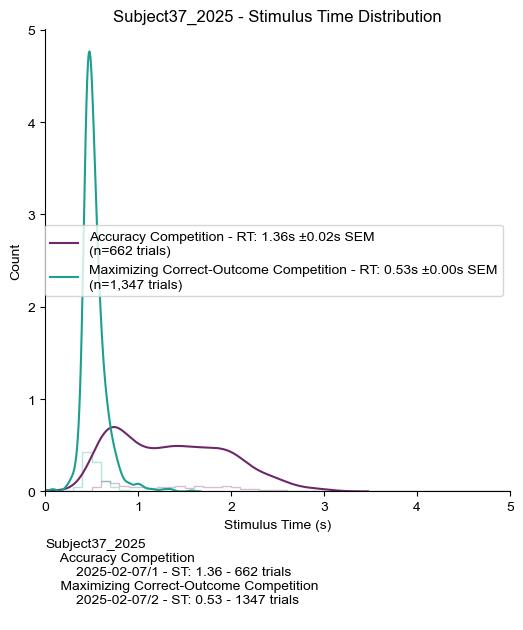

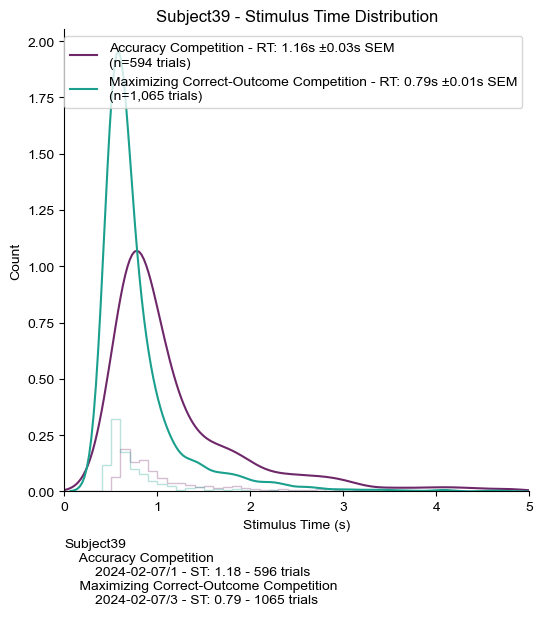

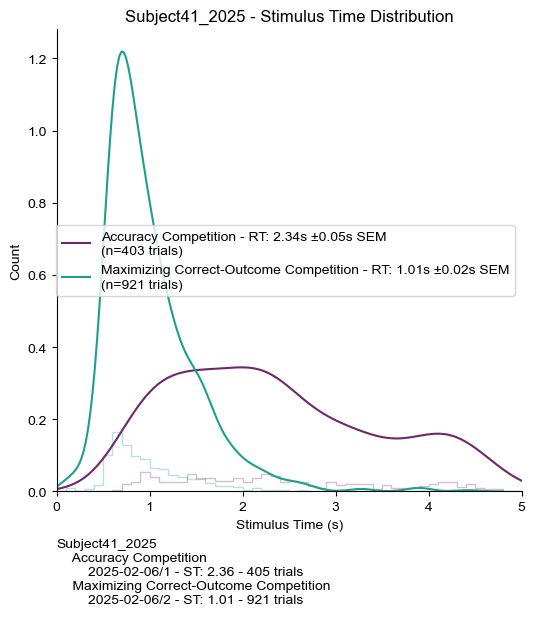

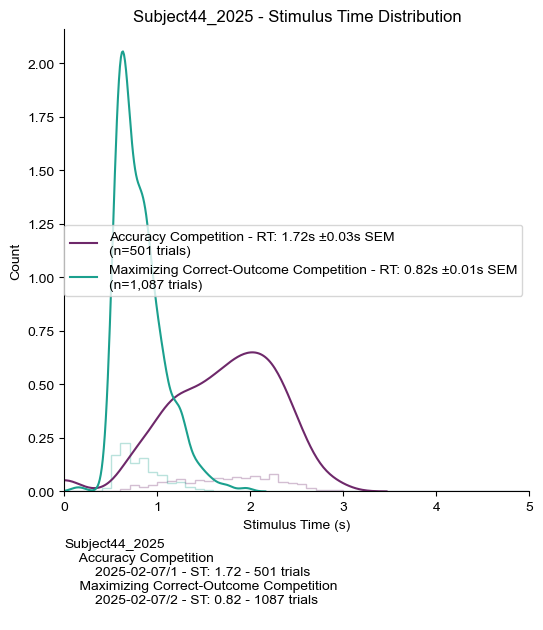

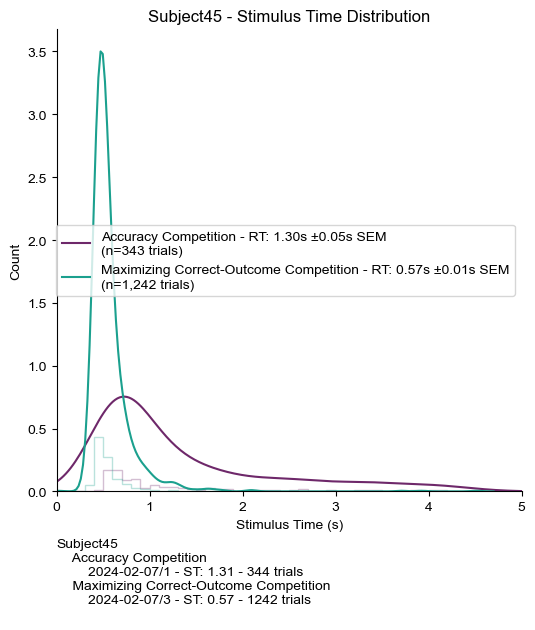

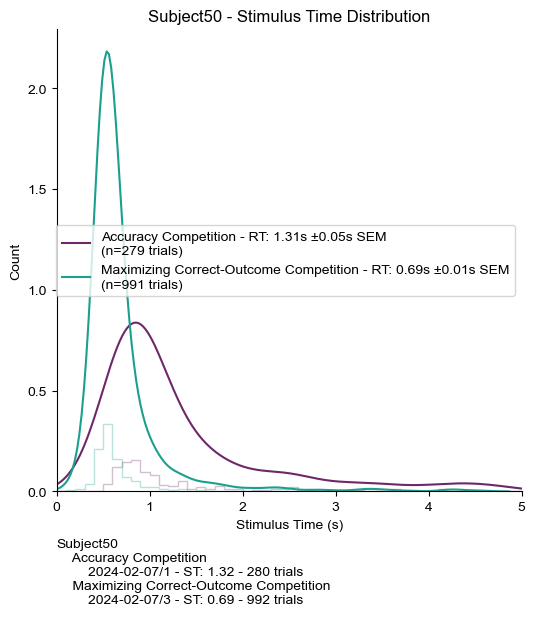

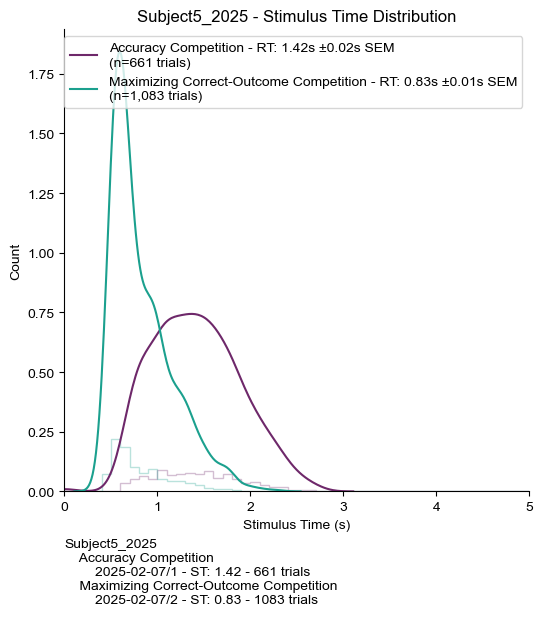

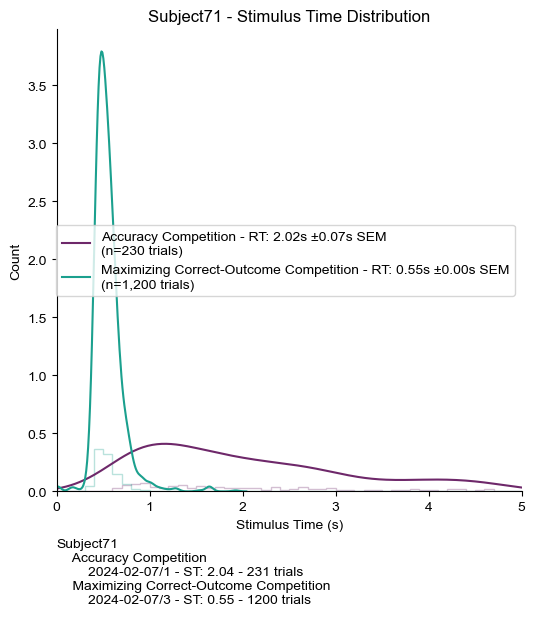

In [19]:
from .behavior.stkde import plotHumanSubjects

# The human counterpart of the figure above: one figure per subject with the
# raw (seconds, not z-scored) sampling time of both experiment types, saved
# under <save_prefix>/humans_st/stimulus_time_<subject>.svg. Pass subjects=[...]
# to restrict it to a few subjects.
HUMAN_ST_COLORS = {"Accuracy Competition": COLOR_ACCURACY,
                   "Maximizing Correct-Outcome Competition": COLOR_MAX_OUTCOME}

_ = plotHumanSubjects(df_users, colors=HUMAN_ST_COLORS,
                      save_prefix=save_prefix, save_figs=global_save_figs)

## Mouse & human sampling time together

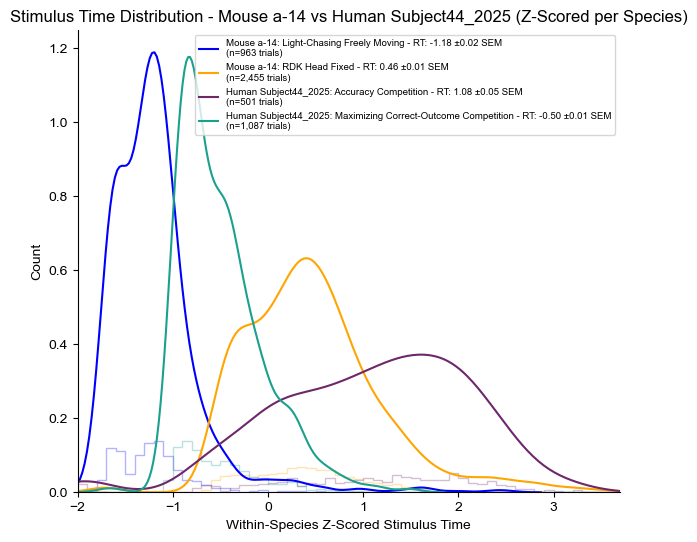

In [37]:
from .behavior.stkde import COMBINED_MOUSE_GROUPS, plotMouseHumanSTKde

# One mouse and one human subject on the same axes. Only the
# COMBINED_MOUSE_GROUPS subset of the mouse's curves is drawn, against the
# human's two experiment types.
# ZSCORE False -> raw seconds. True -> each species is z-scored against its own
# pool (the mouse's plotted groups pooled together, the human's experiment types
# pooled together) and the figure saves under a separate *_zscored.svg name.
MOUSE_SUBJECT = "a-14"
# HUMAN_SUBJECT = "Subject50"
HUMAN_SUBJECT = "Subject44_2025"
ZSCORE = True

_ = plotMouseHumanSTKde(lc_hf_combined_df, df_users,
                        mouse_subject=MOUSE_SUBJECT,
                        human_subject=HUMAN_SUBJECT,
                        mouse_groups=COMBINED_MOUSE_GROUPS,
                        human_colors=HUMAN_ST_COLORS, zscore=ZSCORE,
                        save_prefix=save_prefix, save_figs=global_save_figs)

## All RDK mice vs all human speed-context trials

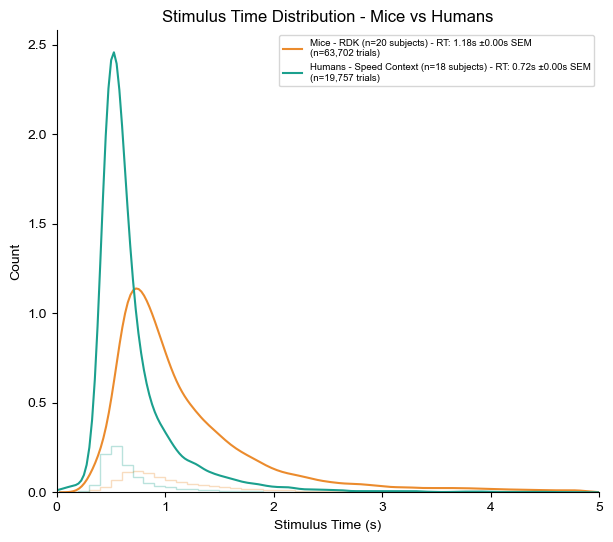

In [ ]:
from .behavior.stkde import (HUMAN_SPEED_LABEL, MICE_POOL_LABEL,
                             plotMiceVsHumansST)

# Two KDEs of the real (seconds, never z-scored) sampling time: every RDK mouse
# of df_mice pooled into one curve, and every human speed-context trial (the
# "Competition" / maximizing-correct-outcome sessions) pooled into the other.
POOLED_COLORS = {MICE_POOL_LABEL: COLOR_MICE,
                 HUMAN_SPEED_LABEL: COLOR_MAX_OUTCOME}

_ = plotMiceVsHumansST(df_mice, df_users, colors=POOLED_COLORS,
                       save_prefix=save_prefix, save_figs=global_save_figs)

# Reward-optimal sampling time

## Fig. 2B

In [ ]:
from .behavior.optimalsampling import (POPULATION_SMOOTH_WINDOW,
                                       SUBJECT_SMOOTH_WINDOW, collectMetrics,
                                       plotAlignedPopulation,
                                       plotSubjectRewardCurve)

# Right panel: every animal aligned on its own reward-rate optimum.
overall_metrics, subj_metrics = collectMetrics(
    df_mice, smooth_window=POPULATION_SMOOTH_WINDOW)
_ = plotAlignedPopulation(subj_metrics, save_prefix=save_prefix,
                          save_figs=global_save_figs)

# Left panel, one per animal. The per-animal curves are smoothed more heavily
# than the population panel, so the metrics are recomputed rather than reused.
for name in subj_metrics:
    subj_overall, one_subj = collectMetrics(
        df_mice[df_mice.Name == name], smooth_window=SUBJECT_SMOOTH_WINDOW)
    _ = plotSubjectRewardCurve(subj_overall, name, one_subj,
                               save_prefix=save_prefix,
                               save_figs=global_save_figs)